
# Data Understanding & Feature Descriptions :
#### Total Records: 2030 rows
#### Total Columns: 22 columns

Age: Numeric – Age of the participant.

Gender: Categorical – Gender of the participant (Male, Female, Other).

Occupation: Categorical – Job category of the participant (Teacher, Student, Lawyer, Nurse, Musician, Engineer, Artist, Chef, Scientist, Athlete, Freelancer, Doctor, Other).

Sleep Hours: Numeric – Average hours of sleep per day.

Physical Activity (hrs/week): Numeric – Weekly duration of physical activity.

Caffeine Intake (mg/day): Numeric – Daily caffeine consumption in milligrams.

Alcohol Consumption (drinks/week): Numeric – Weekly alcohol intake.

Smoking: Categorical (Binary) – Smoking status (Yes/No).

Family History of Anxiety: Categorical (Binary) – Presence of family history of anxiety (Yes/No).

Stress Level (1–10): Categorical – Self-reported stress intensity (1–10).

Heart Rate (bpm): Numeric – Resting heart rate in beats per minute.

Breathing Rate (breaths/min): Numeric – Number of breaths per minute.

Sweating Level (1–5): Categorical – Severity of sweating symptoms (1–5).

Dizziness: Categorical (Binary) – Presence of dizziness (Yes/No).

Medication: Categorical (Binary) – Use of anxiety-related medication (Yes/No).

Therapy Sessions (per month): Numeric – Number of therapy sessions attended per month.

Recent Major Life Event: Categorical (Binary) – Experience of recent major life events (Yes/No).

Diet Quality (1–10): Categorical – Self-reported diet quality (1–10).

Anxiety Level (1–10): Categorical – Self-reported anxiety severity (1–10).

Target: Categorical (Binary) – Target label for model training (0/1).

is Anxious: Categorical (Binary) – Indicates anxiety condition (0/1).

Therapy History: Categorical – Type of previous therapy (Group Therapy, Psychodynamic Therapy, Cognitive Behavioral Therapy (CBT), No previous history).



#### import packages and reading data

In [342]:
import numpy as np  
import pandas as pd  
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy import stats

In [343]:
df = pd.read_csv('social_anxiety_dataset.csv')

In [344]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2030 entries, 0 to 2029
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1968 non-null   float64
 1   Gender                             1911 non-null   object 
 2   Occupation                         2030 non-null   object 
 3   Sleep Hours                        1994 non-null   float64
 4   Physical Activity (hrs/week)       2030 non-null   float64
 5   Caffeine Intake (mg/day)           1936 non-null   float64
 6   Alcohol Consumption (drinks/week)  2030 non-null   int64  
 7   Smoking                            1924 non-null   object 
 8   Family History of Anxiety          2030 non-null   object 
 9   Stress Level (1-10)                2030 non-null   int64  
 10  Heart Rate (bpm)                   2030 non-null   int64  
 11  Breathing Rate (breaths/min)       2030 non-null   int64

Therapy History has the highest number of missing values.

Gender, Age, Smoking, Medication, and Caffeine Intake also contain missing values, which may affect statistical analysis.

In [345]:
df.head(20)

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),...,Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10),Target,is_Anxious,Therapy History
0,59.0,Other,Teacher,7.0,2.4,40.0,5,Yes,No,4,...,5,No,No,0,Yes,1.0,2.0,0,0,Group Therapy
1,46.0,Female,Student,5.1,5.4,156.0,11,NaN,No,3,...,4,Yes,No,2,No,1.0,4.0,0,0,NaN
2,40.0,Other,Lawyer,5.1,1.9,570.0,14,Yes,Yes,9,...,3,No,No,6,Yes,4.0,9.0,1,1,NaN
3,40.0,Male,Nurse,7.6,0.9,129.0,0,No,No,9,...,2,No,NaN,2,No,2.0,6.0,0,0,NaN
4,26.0,Male,Other,6.7,3.0,64.0,13,No,No,15,...,4,No,Yes,0,Yes,4.0,3.0,0,0,NaN
5,53.0,Male,Student,8.7,4.8,324.0,0,Yes,Yes,1,...,5,Yes,NaN,1,Yes,8.0,1.0,0,0,NaN
6,32.0,Male,Nurse,5.9,2.0,318.0,12,No,Yes,7,...,4,No,Yes,4,No,10.0,5.0,0,0,NaN
7,36.0,Male,Musician,6.4,4.0,230.0,4,NaN,Yes,1,...,2,Yes,No,3,Yes,7.0,1.0,0,0,NaN
8,56.0,Other,Engineer,3.2,4.5,436.0,1,No,Yes,2,...,3,No,Yes,2,No,3.0,3.0,0,0,NaN
9,27.0,Other,Artist,-10.0,2.4,NaN,6,Yes,No,7,...,1,Yes,Yes,1,No,7.0,3.0,0,0,NaN


In [346]:
df.isnull().sum()

Age                                    62
Gender                                119
Occupation                              0
Sleep Hours                            36
Physical Activity (hrs/week)            0
Caffeine Intake (mg/day)               94
Alcohol Consumption (drinks/week)       0
Smoking                               106
Family History of Anxiety               0
Stress Level (1-10)                     0
Heart Rate (bpm)                        0
Breathing Rate (breaths/min)            0
Sweating Level (1-5)                    0
Dizziness                               0
Medication                            109
Therapy Sessions (per month)            0
Recent Major Life Event                 0
Diet Quality (1-10)                    78
Anxiety Level (1-10)                    0
Target                                  0
is_Anxious                              0
Therapy History                      1827
dtype: int64

In [347]:
df.isnull().sum()/df.shape[0]*100

Age                                   3.054187
Gender                                5.862069
Occupation                            0.000000
Sleep Hours                           1.773399
Physical Activity (hrs/week)          0.000000
Caffeine Intake (mg/day)              4.630542
Alcohol Consumption (drinks/week)     0.000000
Smoking                               5.221675
Family History of Anxiety             0.000000
Stress Level (1-10)                   0.000000
Heart Rate (bpm)                      0.000000
Breathing Rate (breaths/min)          0.000000
Sweating Level (1-5)                  0.000000
Dizziness                             0.000000
Medication                            5.369458
Therapy Sessions (per month)          0.000000
Recent Major Life Event               0.000000
Diet Quality (1-10)                   3.842365
Anxiety Level (1-10)                  0.000000
Target                                0.000000
is_Anxious                            0.000000
Therapy Histo

In [348]:
print('The dataframe contains',df.duplicated().sum(), 'duplicate rows')

The dataframe contains 0 duplicate rows


In [349]:
for i in df.select_dtypes(include='object').columns:
    print(df[i].value_counts())
    print('***'*10)

Gender
Female    657
Other     627
Male      627
Name: count, dtype: int64
******************************
Occupation
Student       182
Artist        172
Lawyer        167
Musician      163
Nurse         162
Doctor        161
Scientist     155
Teacher       151
Other         149
Athlete       147
Chef          146
Engineer      141
Freelancer    134
Name: count, dtype: int64
******************************
Smoking
Yes    1020
No      904
Name: count, dtype: int64
******************************
Family History of Anxiety
Yes    1058
No      972
Name: count, dtype: int64
******************************
Dizziness
Yes    1049
No      981
Name: count, dtype: int64
******************************
Medication
Yes    964
No     957
Name: count, dtype: int64
******************************
Recent Major Life Event
Yes    1040
No      990
Name: count, dtype: int64
******************************
Therapy History
No previous history                   60
Group Therapy                         54
Cognitive Be

In [350]:
df['Target'].equals(df['is_Anxious'])

True

In [351]:
df_copy=df.copy()

df_copy=df_copy.drop(['Target','Therapy History'],axis=1)
df_copy

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10),is_Anxious
0,59.0,Other,Teacher,7.0,2.4,40.0,5,Yes,No,4,79,21,5,No,No,0,Yes,1.0,2.0,0
1,46.0,Female,Student,5.1,5.4,156.0,11,NaN,No,3,70,19,4,Yes,No,2,No,1.0,4.0,0
2,40.0,Other,Lawyer,5.1,1.9,570.0,14,Yes,Yes,9,101,23,3,No,No,6,Yes,4.0,9.0,1
3,40.0,Male,Nurse,7.6,0.9,129.0,0,No,No,9,116,16,2,No,NaN,2,No,2.0,6.0,0
4,26.0,Male,Other,6.7,3.0,64.0,13,No,No,15,119,19,4,No,Yes,0,Yes,4.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025,42.0,Male,Teacher,3.7,2.9,113.0,18,Yes,Yes,4,89,19,4,No,Yes,1,Yes,2.0,3.0,0
2026,34.0,Other,Freelancer,8.4,2.0,239.0,14,No,No,7,83,15,2,No,Yes,0,No,5.0,4.0,0
2027,62.0,Female,Musician,6.1,1.6,149.0,18,Yes,No,2,77,26,5,No,No,4,Yes,8.0,1.0,0
2028,47.0,Other,Nurse,6.3,1.1,298.0,-1,No,Yes,7,63,27,2,Yes,Yes,1,Yes,3.0,4.0,0


# Exploratory Data Analysis(EDA)

In [352]:
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1968.0,39.921748,13.243754,18.0,29.00,40.0,51.0,64.0
Sleep Hours,1994.0,6.424624,2.161544,-10.0,5.80,6.7,7.5,11.0
Physical Activity (hrs/week),2030.0,2.800246,2.233899,-10.0,1.40,2.8,4.2,9.2
Caffeine Intake (mg/day),1936.0,306.275826,208.012717,0.0,177.75,277.5,391.0,1500.0
Alcohol Consumption (drinks/week),2030.0,9.490148,6.028653,-10.0,5.00,10.0,15.0,19.0
Stress Level (1-10),2030.0,6.028571,3.137269,1.0,3.00,6.0,9.0,15.0
Heart Rate (bpm),2030.0,93.066502,23.313430,60.0,76.00,93.0,107.0,220.0
Breathing Rate (breaths/min),2030.0,20.955665,5.182524,12.0,17.00,21.0,26.0,29.0
Sweating Level (1-5),2030.0,3.095567,1.392697,1.0,2.00,3.0,4.0,5.0
Therapy Sessions (per month),2030.0,2.359113,2.148642,0.0,1.00,2.0,3.0,10.0


In [353]:
colneg =['Physical Activity (hrs/week)','Sleep Hours','Alcohol Consumption (drinks/week)']
(df_copy[colneg]<0).sum()

Physical Activity (hrs/week)         40
Sleep Hours                          40
Alcohol Consumption (drinks/week)    40
dtype: int64

In [354]:
df_copy['Stress Level (1-10)'].unique()

array([ 4,  3,  9, 15,  1,  7,  2, 10,  8,  6,  5], dtype=int64)

In [355]:
df_copy.describe(include='object')

,Gender,Occupation,Smoking,Family History of Anxiety,Dizziness,Medication,Recent Major Life Event
count,1911,2030,1924,2030,2030,1921,2030
unique,3,13,2,2,2,2,2
top,Female,Student,Yes,Yes,Yes,Yes,Yes
freq,657,182,1020,1058,1049,964,1040


In [356]:
print("The variable 'is_Anxious' is our target variable, indicating whether an individual has social anxiety or not.")

The variable 'is_Anxious' is our target variable, indicating whether an individual has social anxiety or not.


In [357]:
numeric_cols = ['Age',
                'Sleep Hours',
                'Physical Activity (hrs/week)',
                'Caffeine Intake (mg/day)',
                'Alcohol Consumption (drinks/week)',
                'Heart Rate (bpm)',
                'Breathing Rate (breaths/min)',
                'Therapy Sessions (per month)']

categorical_cols = ['Gender',
                    'Occupation',
                    'Smoking',
                    'Family History of Anxiety',
                    'Stress Level (1-10)',
                    'Dizziness',
                    'Medication',
                    'Recent Major Life Event',
                    'Sweating Level (1-5)',
                    'Diet Quality (1-10)',
                    'Anxiety Level (1-10)',
                    'is_Anxious']



In [358]:
len(numeric_cols)+len(categorical_cols)

20

# Missing Values

In [359]:
colneg =['Physical Activity (hrs/week)','Sleep Hours','Alcohol Consumption (drinks/week)']
for col in colneg:
    df_copy[col] = np.where(df_copy[col]<0,None,df_copy[col])

In [360]:
df_copy.isnull().sum()

Age                                   62
Gender                               119
Occupation                             0
Sleep Hours                           76
Physical Activity (hrs/week)          40
Caffeine Intake (mg/day)              94
Alcohol Consumption (drinks/week)     40
Smoking                              106
Family History of Anxiety              0
Stress Level (1-10)                    0
Heart Rate (bpm)                       0
Breathing Rate (breaths/min)           0
Sweating Level (1-5)                   0
Dizziness                              0
Medication                           109
Therapy Sessions (per month)           0
Recent Major Life Event                0
Diet Quality (1-10)                   78
Anxiety Level (1-10)                   0
is_Anxious                             0
dtype: int64

In [361]:
for i in ['Age','Sleep Hours','Caffeine Intake (mg/day)','Physical Activity (hrs/week)','Alcohol Consumption (drinks/week)']:
    df_copy[i].fillna(df_copy[i].median(),inplace=True)

In [362]:
for j in ['Gender','Smoking','Medication','Diet Quality (1-10)']:
    df_copy[j].fillna(df_copy[j].mode()[0],inplace=True)

In [363]:
df_copy.isnull().sum()

Age                                  0
Gender                               0
Occupation                           0
Sleep Hours                          0
Physical Activity (hrs/week)         0
Caffeine Intake (mg/day)             0
Alcohol Consumption (drinks/week)    0
Smoking                              0
Family History of Anxiety            0
Stress Level (1-10)                  0
Heart Rate (bpm)                     0
Breathing Rate (breaths/min)         0
Sweating Level (1-5)                 0
Dizziness                            0
Medication                           0
Therapy Sessions (per month)         0
Recent Major Life Event              0
Diet Quality (1-10)                  0
Anxiety Level (1-10)                 0
is_Anxious                           0
dtype: int64

#### columns summary

In [364]:
def categorical_data_summary(df,columns):
    summary_df = pd.DataFrame()
    for column in columns:
        summary_df[column] = {
            'Count': df[column].count(),
            'Mode': df[column].mode()[0],
            'Unique' : len(df[column].unique())

        }
    return summary_df

In [365]:
categorical_data_summary(df_copy,categorical_cols)

,Gender,Occupation,Smoking,Family History of Anxiety,Stress Level (1-10),Dizziness,Medication,Recent Major Life Event,Sweating Level (1-5),Diet Quality (1-10),Anxiety Level (1-10),is_Anxious
Count,2030,2030,2030,2030,2030,2030,2030,2030,2030,2030.0,2030.0,2030
Mode,Female,Student,Yes,Yes,10,Yes,Yes,Yes,4,3.0,3.0,0
Unique,3,13,2,2,11,2,2,2,5,10.0,10.0,2


In [366]:
df_copy[['Age','Diet Quality (1-10)','Anxiety Level (1-10)','Caffeine Intake (mg/day)']]= df_copy[['Age','Diet Quality (1-10)','Anxiety Level (1-10)','Caffeine Intake (mg/day)']].astype(int)

In [367]:
df_copy

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10),is_Anxious
0,59,Other,Teacher,7.0,2.4,40,5.0,Yes,No,4,79,21,5,No,No,0,Yes,1,2,0
1,46,Female,Student,5.1,5.4,156,11.0,Yes,No,3,70,19,4,Yes,No,2,No,1,4,0
2,40,Other,Lawyer,5.1,1.9,570,14.0,Yes,Yes,9,101,23,3,No,No,6,Yes,4,9,1
3,40,Male,Nurse,7.6,0.9,129,0.0,No,No,9,116,16,2,No,Yes,2,No,2,6,0
4,26,Male,Other,6.7,3.0,64,13.0,No,No,15,119,19,4,No,Yes,0,Yes,4,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025,42,Male,Teacher,3.7,2.9,113,18.0,Yes,Yes,4,89,19,4,No,Yes,1,Yes,2,3,0
2026,34,Other,Freelancer,8.4,2.0,239,14.0,No,No,7,83,15,2,No,Yes,0,No,5,4,0
2027,62,Female,Musician,6.1,1.6,149,18.0,Yes,No,2,77,26,5,No,No,4,Yes,8,1,0
2028,47,Other,Nurse,6.3,1.1,298,10.0,No,Yes,7,63,27,2,Yes,Yes,1,Yes,3,4,0


# outlier


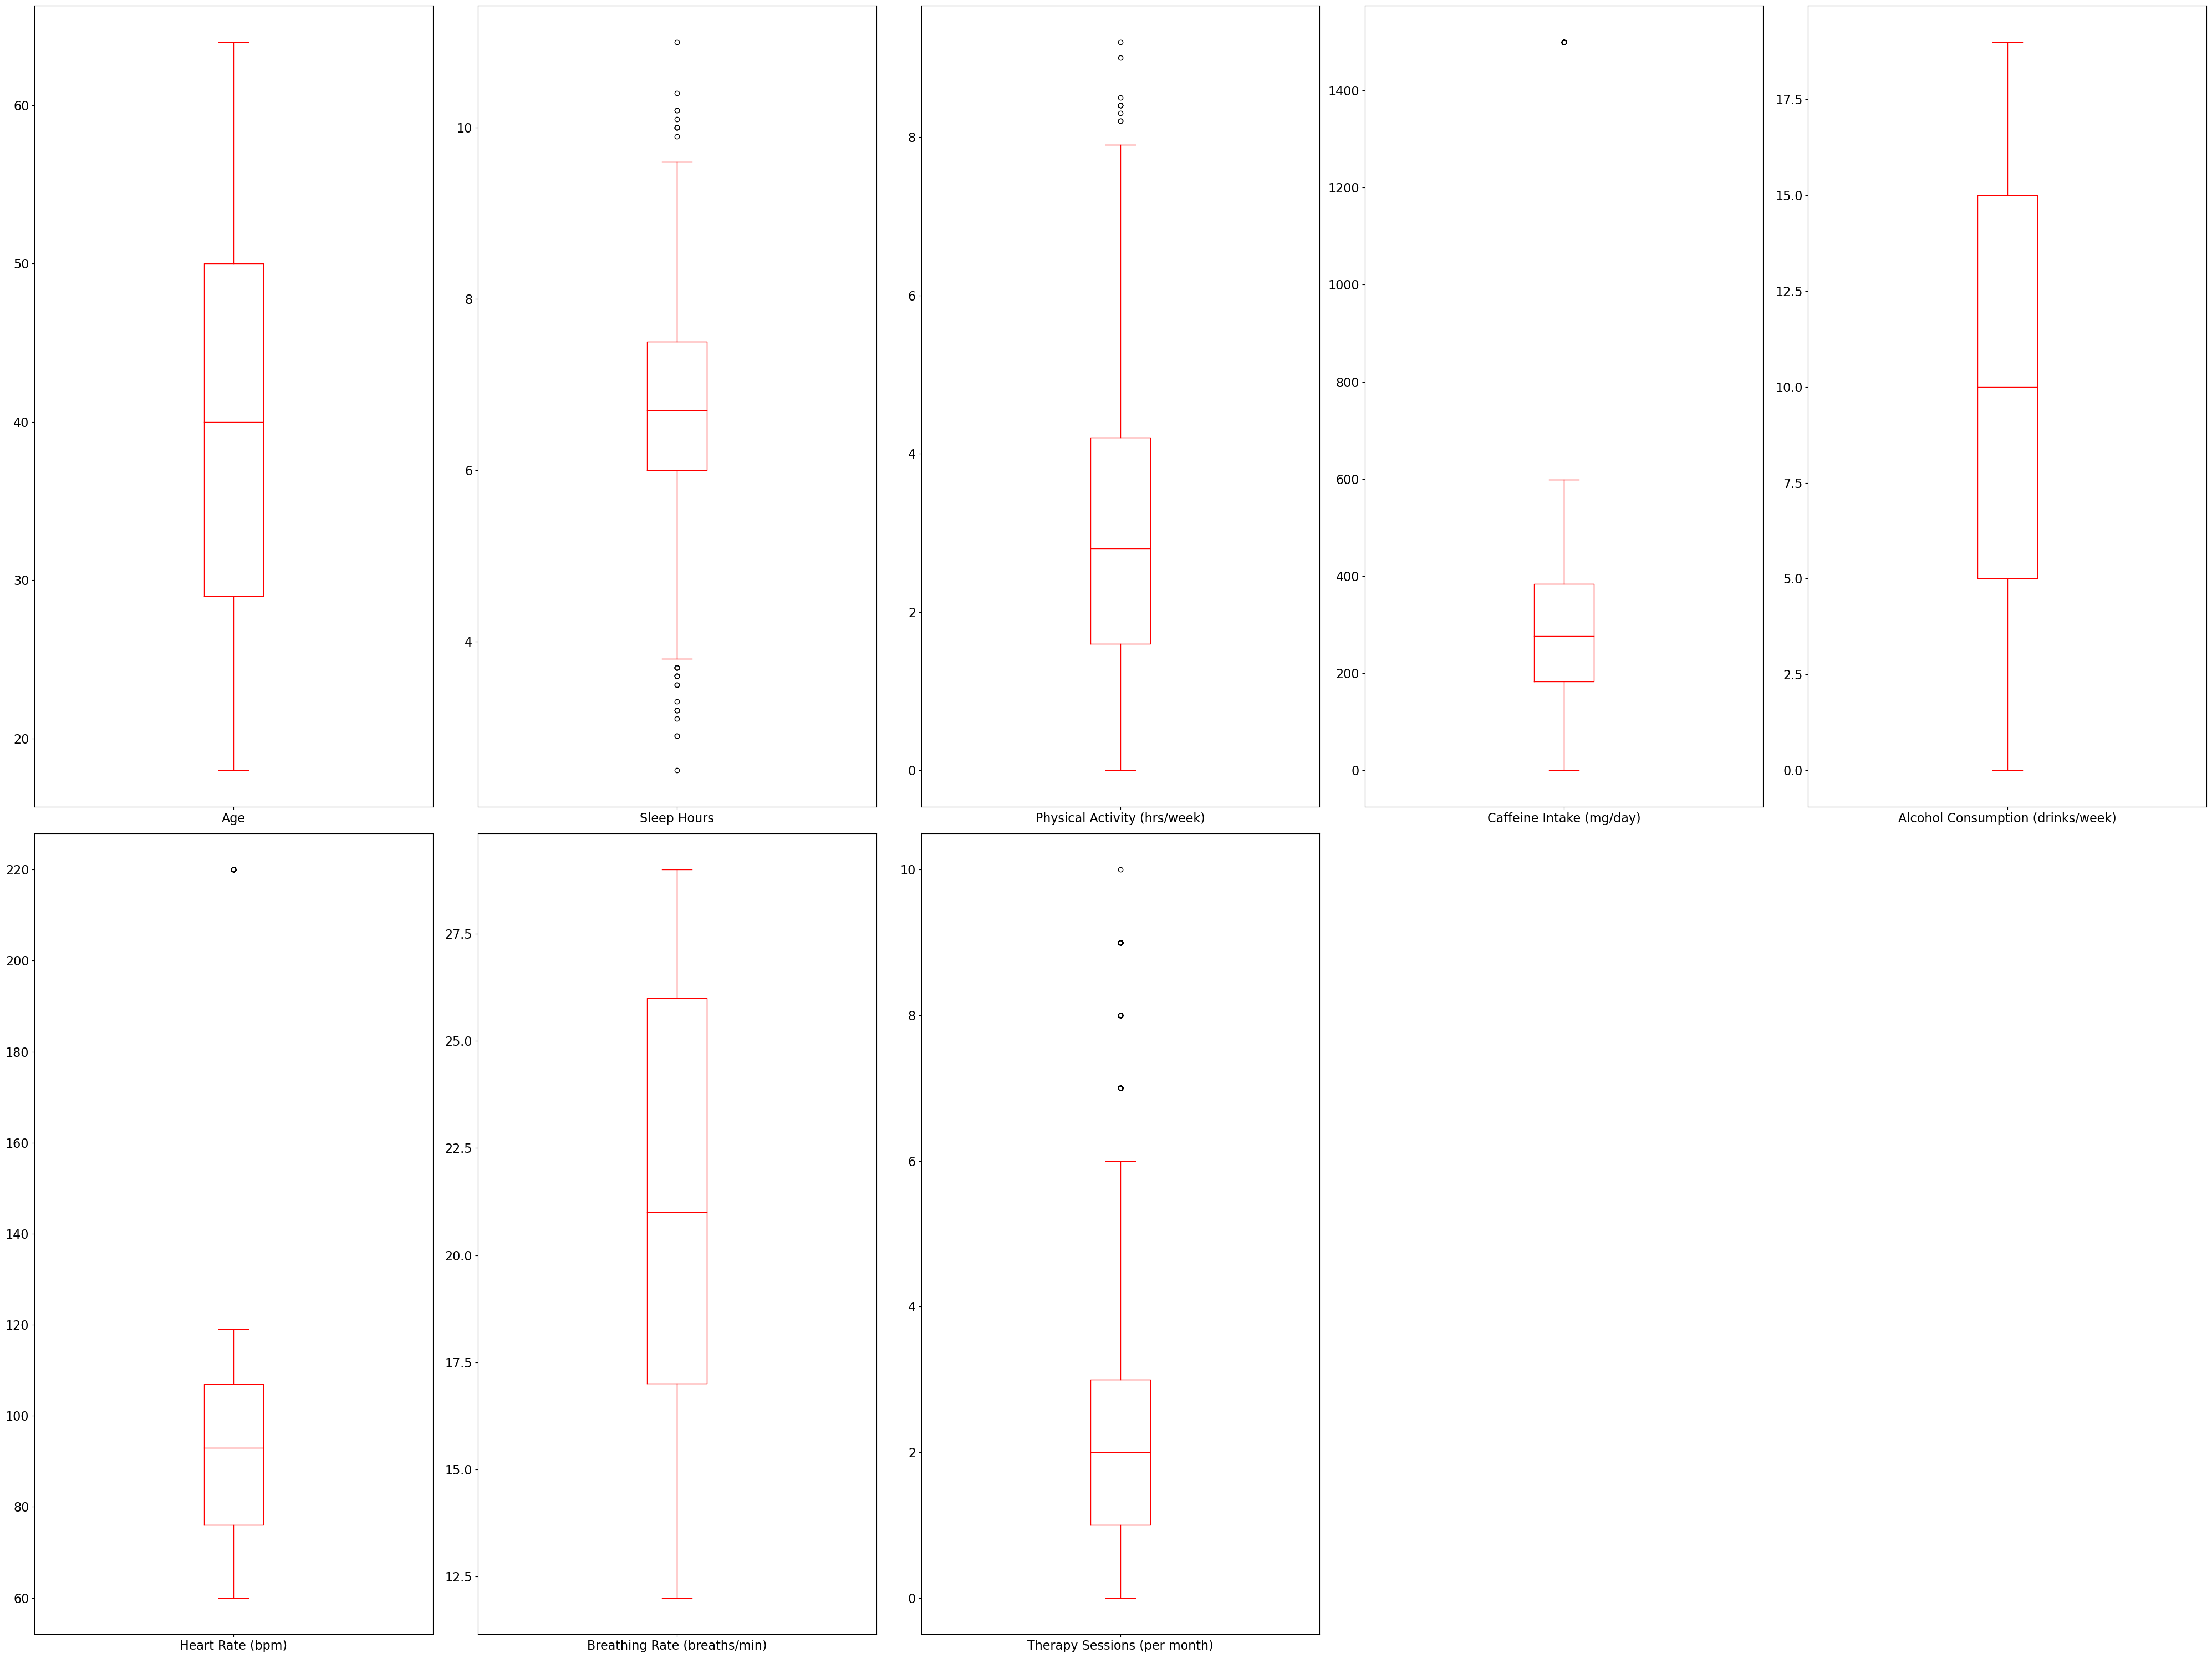

In [368]:
df_copy[numeric_cols].plot(
    kind='box',
    subplots=True,
    sharey=False,
    layout=(2,int(len(numeric_cols)/2)+1),
    figsize=(40,30),
    color = 'r',
    fontsize= 16
)
plt.tight_layout()
plt.show()

   

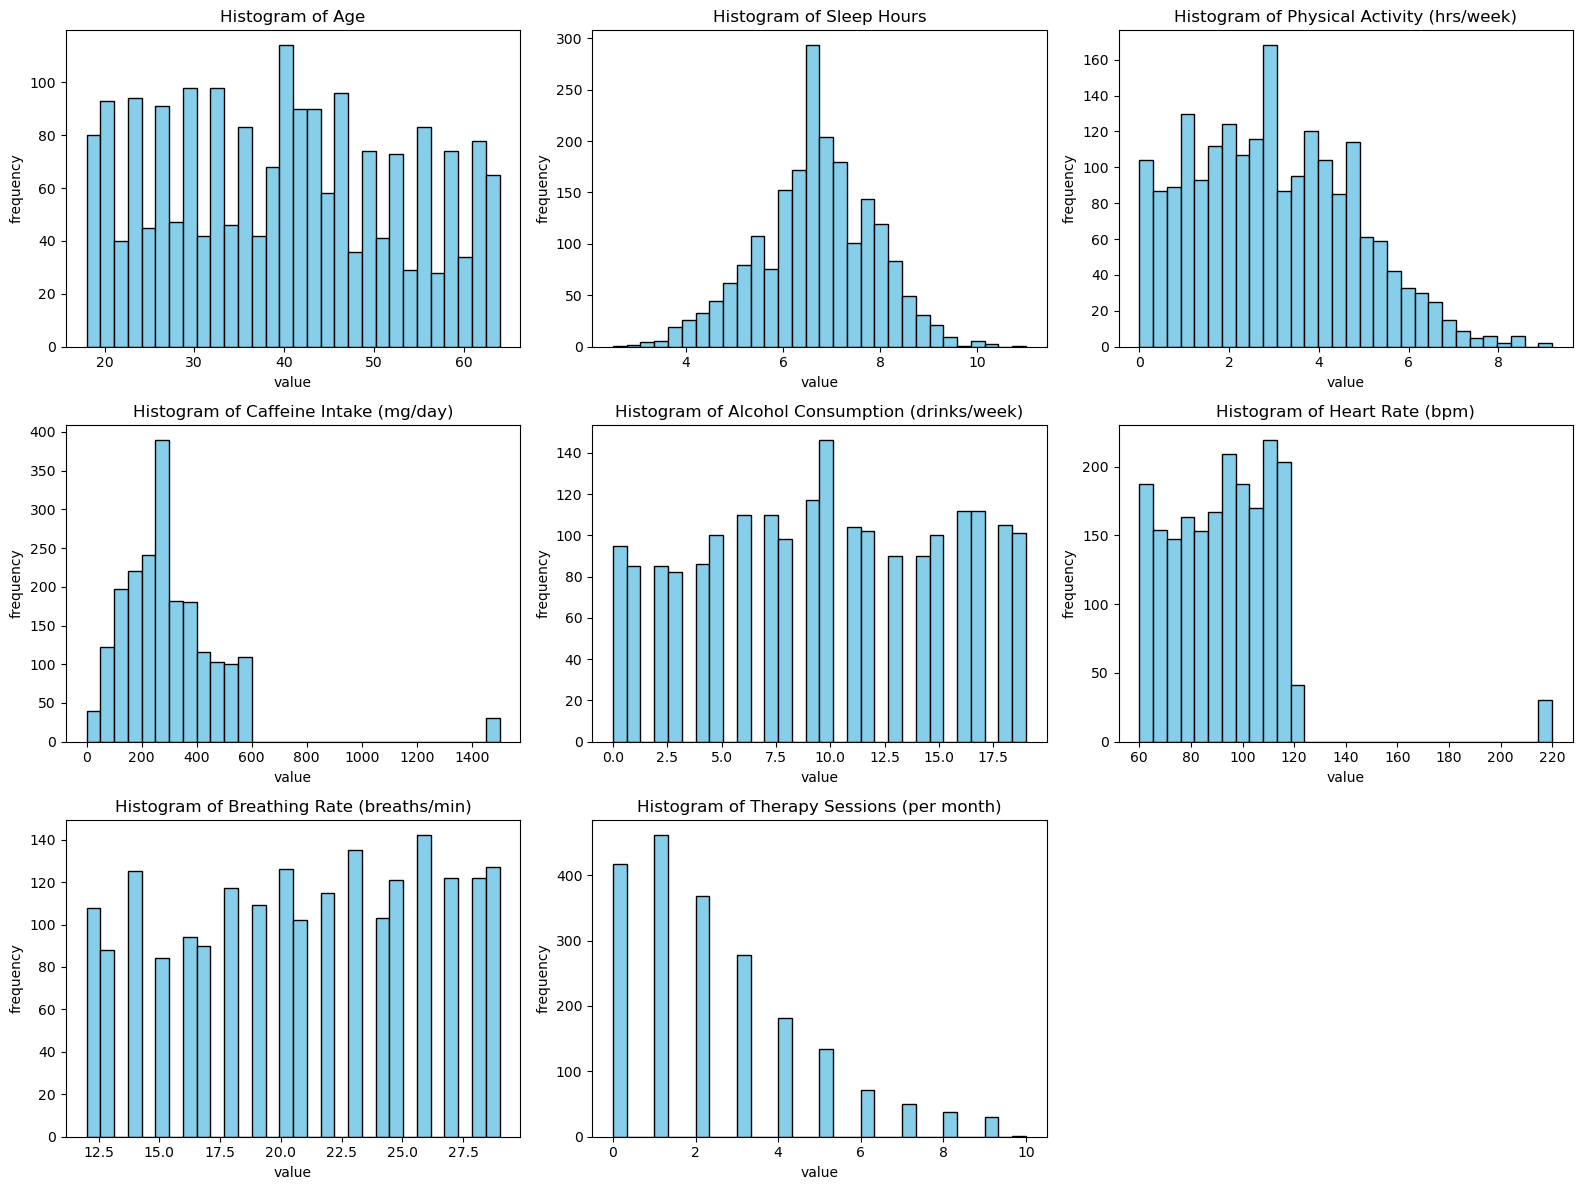

In [369]:
plt.figure(figsize=(16,12))
for i,feature in enumerate(numeric_cols):
    plt.subplot(3,3,i+1)
    plt.hist(df_copy[feature],bins=30,edgecolor="black",color='skyblue')
    plt.title(f'Histogram of {feature}')
    plt.xlabel('value')
    plt.ylabel('frequency') 

plt.tight_layout()
plt.show()

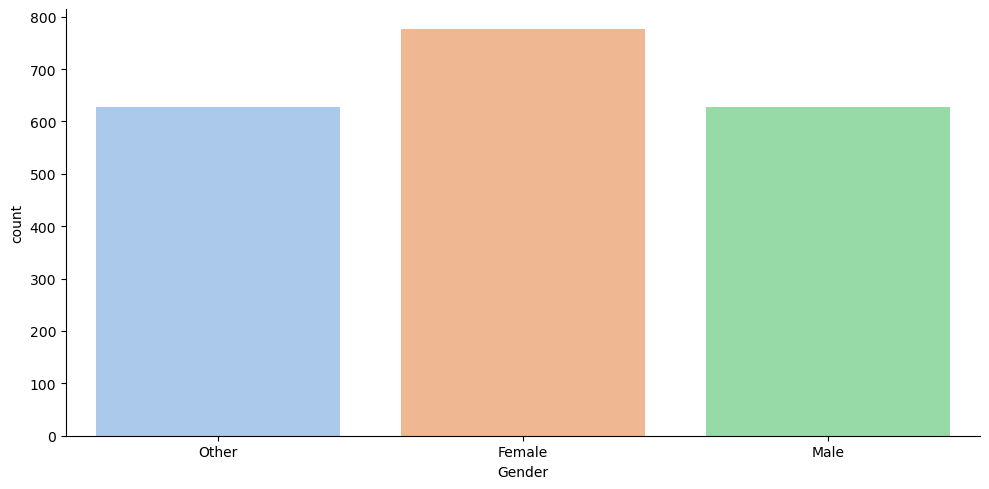

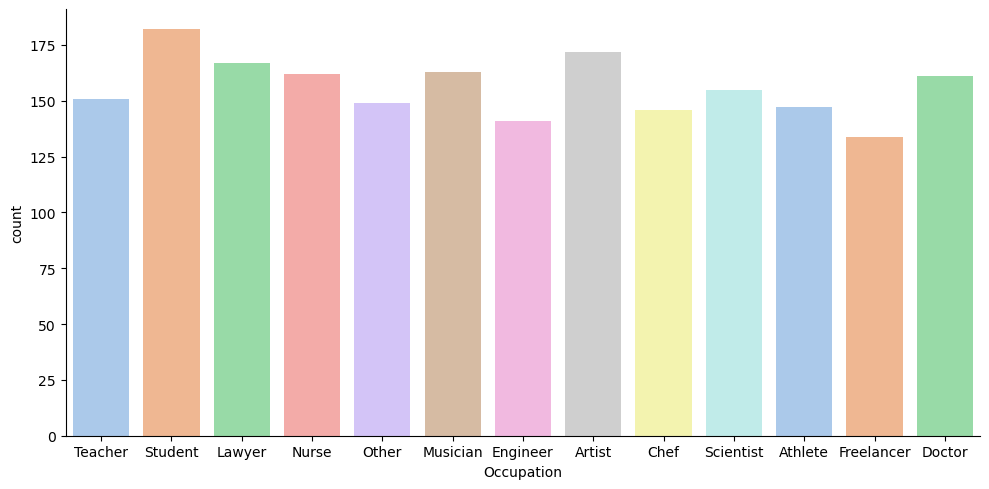

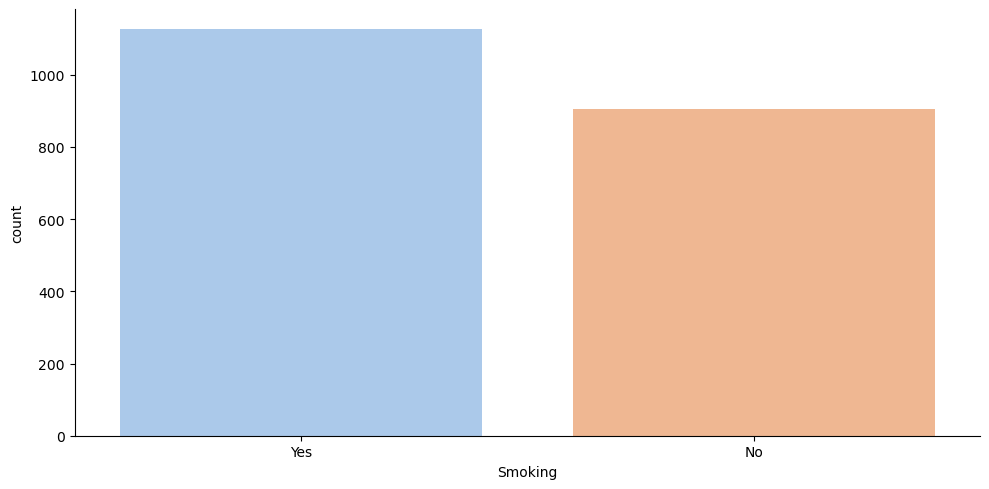

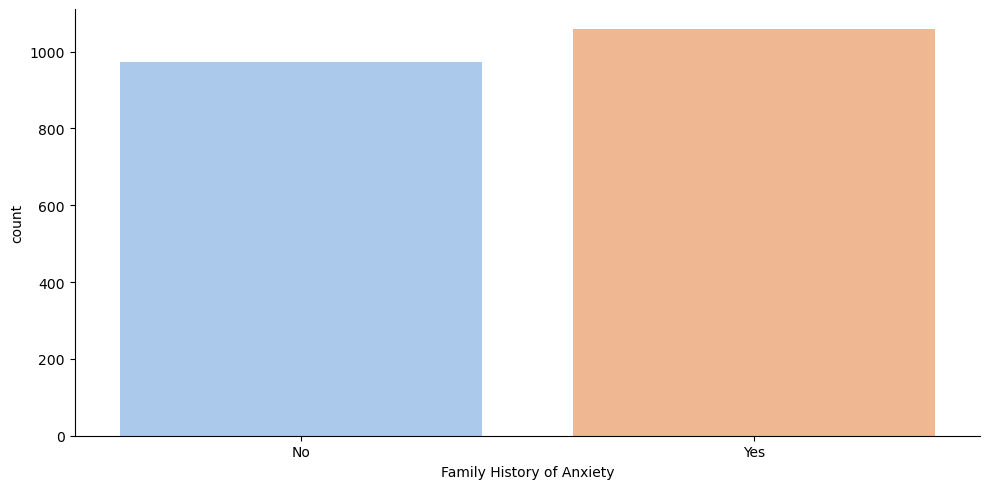

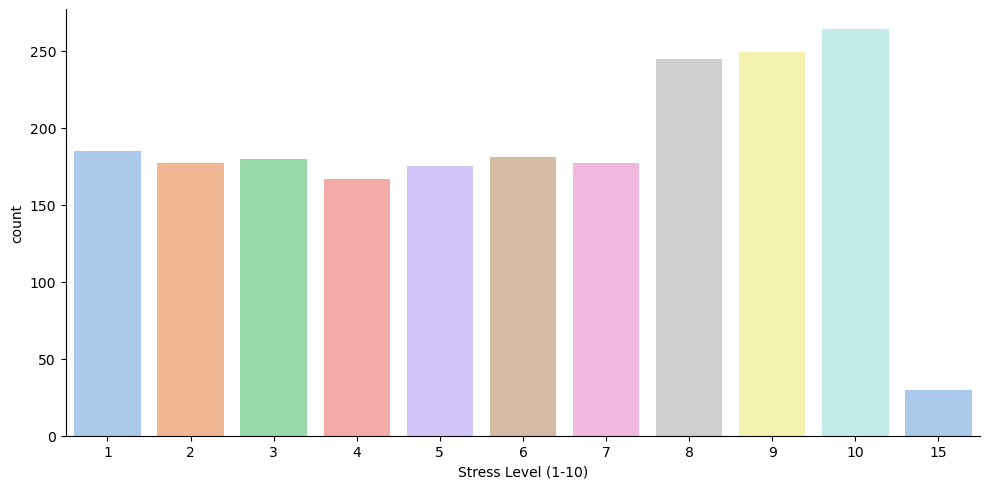

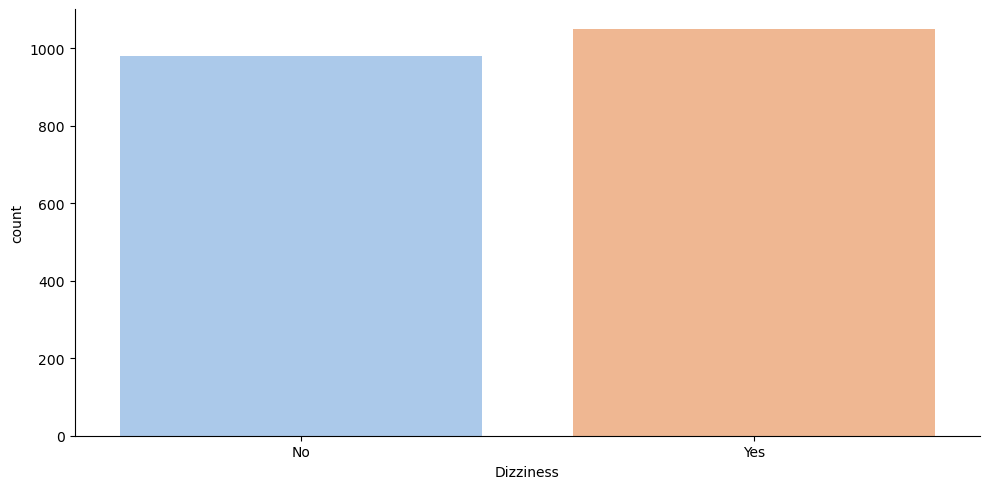

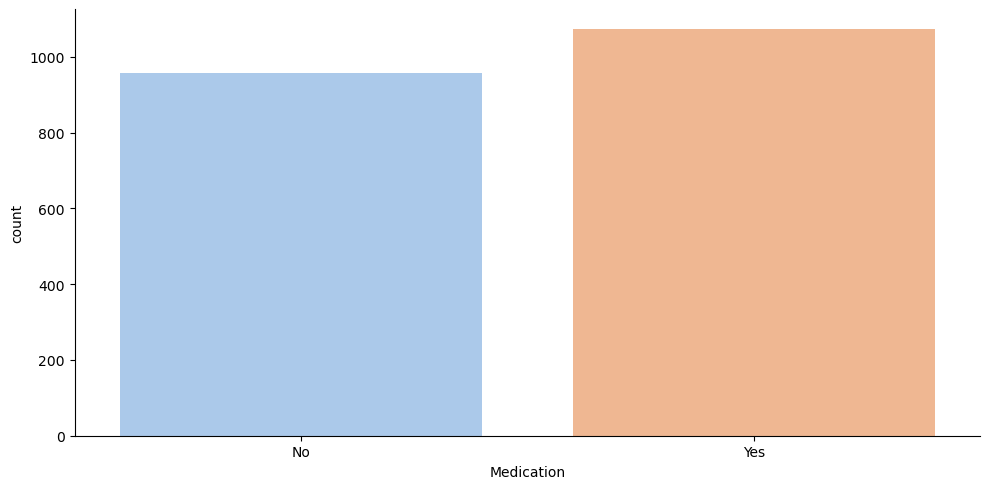

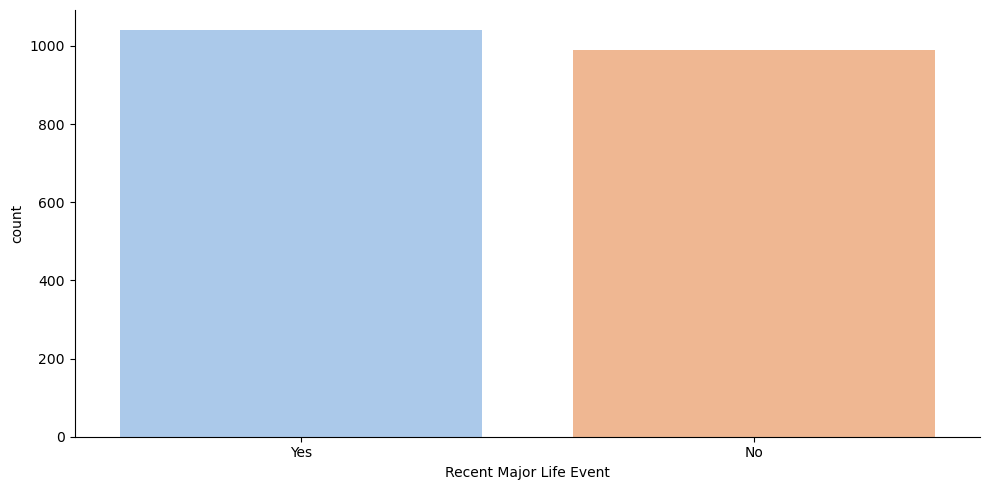

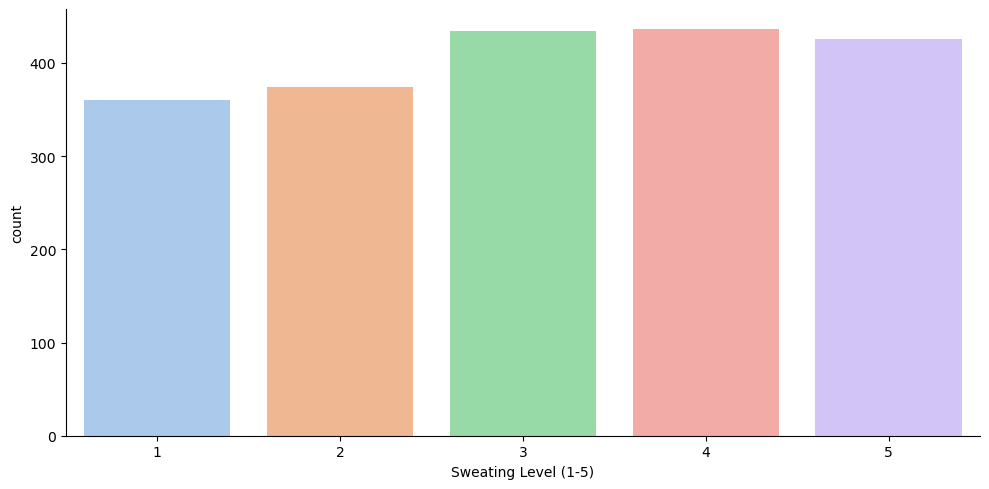

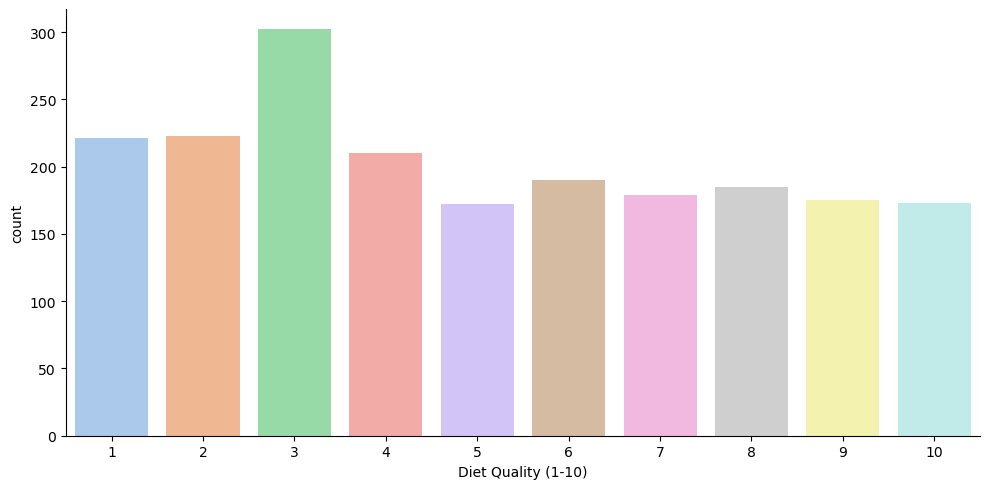

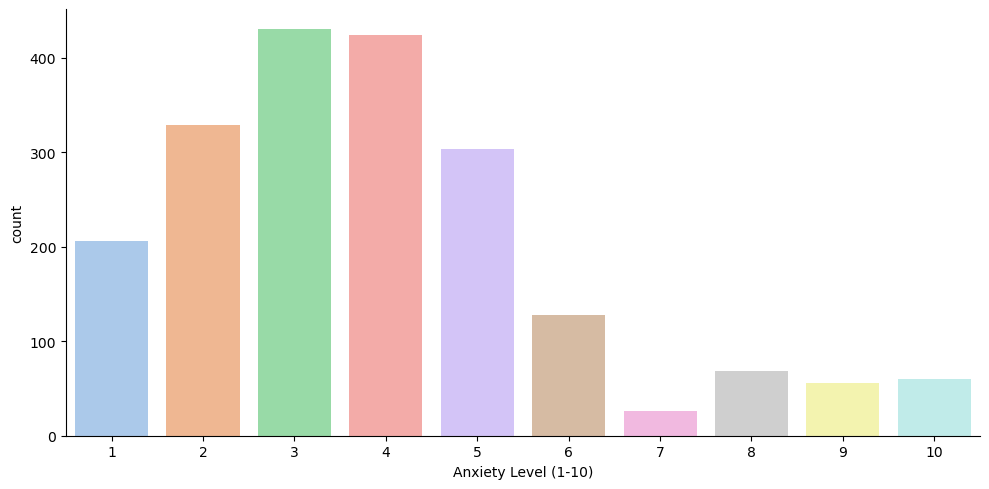

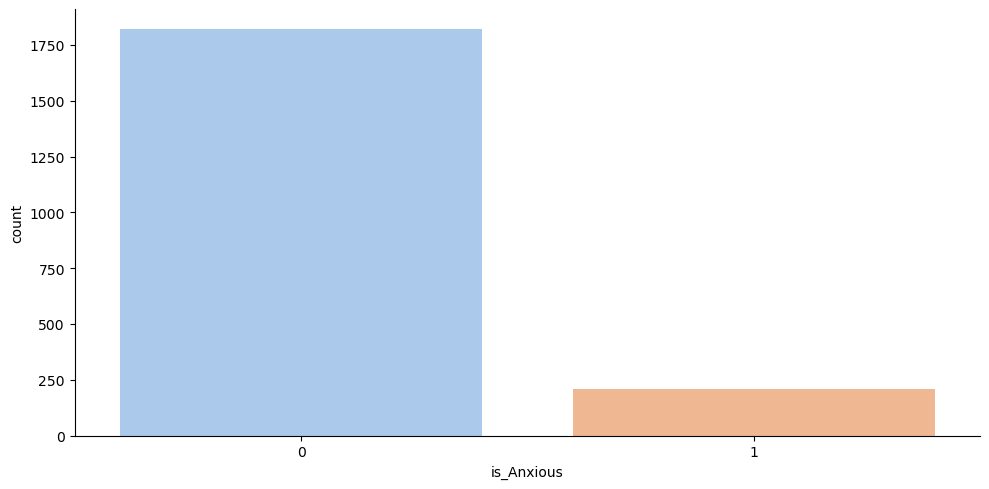

In [370]:
for col in categorical_cols:
    sns.catplot(data=df_copy,x = col,kind='count',palette='pastel',height=5,aspect=2)



In [371]:
df_corr = df_copy[numeric_cols].corr()
df_corr

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Heart Rate (bpm),Breathing Rate (breaths/min),Therapy Sessions (per month)
Age,1.000000,-0.148229,0.048228,-0.024575,-0.037408,-0.030986,-0.046542,-0.092838
Sleep Hours,-0.148229,1.000000,0.148905,-0.142279,-0.069818,-0.067422,-0.123086,-0.307266
Physical Activity (hrs/week),0.048228,0.148905,1.000000,-0.105307,-0.070620,-0.023607,-0.088975,-0.196348
Caffeine Intake (mg/day),-0.024575,-0.142279,-0.105307,1.000000,0.001613,-0.009395,0.055429,0.160726
Alcohol Consumption (drinks/week),-0.037408,-0.069818,-0.070620,0.001613,1.000000,0.031243,0.034602,0.078508
Heart Rate (bpm),-0.030986,-0.067422,-0.023607,-0.009395,0.031243,1.000000,0.026176,0.110427
Breathing Rate (breaths/min),-0.046542,-0.123086,-0.088975,0.055429,0.034602,0.026176,1.000000,0.108009
Therapy Sessions (per month),-0.092838,-0.307266,-0.196348,0.160726,0.078508,0.110427,0.108009,1.000000


<Axes: >

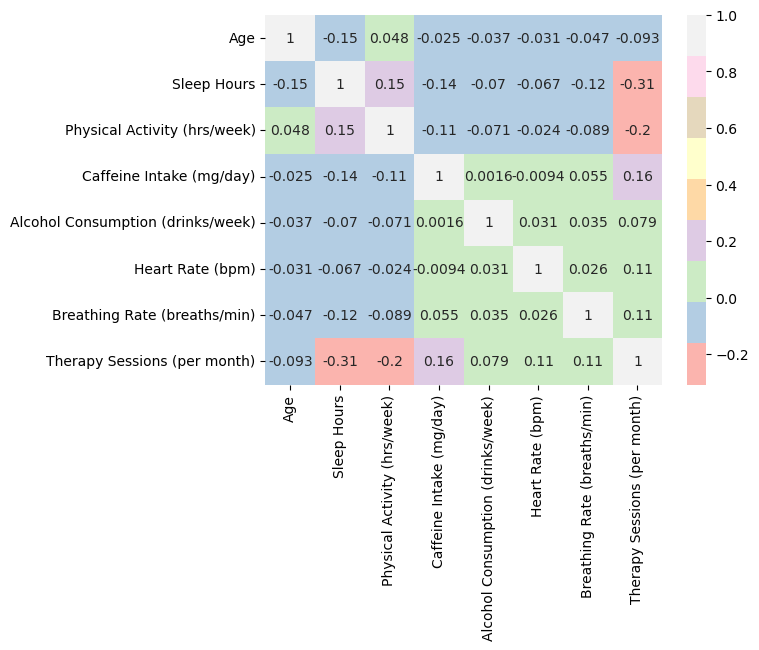

In [372]:
sns.heatmap(df_corr,cmap='Pastel1',annot=True)

In [373]:
for col in ['Caffeine Intake (mg/day)','Heart Rate (bpm)']:
    Q1=df_copy[col].quantile(0.25)
    Q3=df_copy[col].quantile(0.75)
    IQR=Q3-Q1
    lower= Q1-1.5*IQR
    upper= Q3+1.5*IQR
    df_copy[col]=df_copy[col].clip(lower,upper)

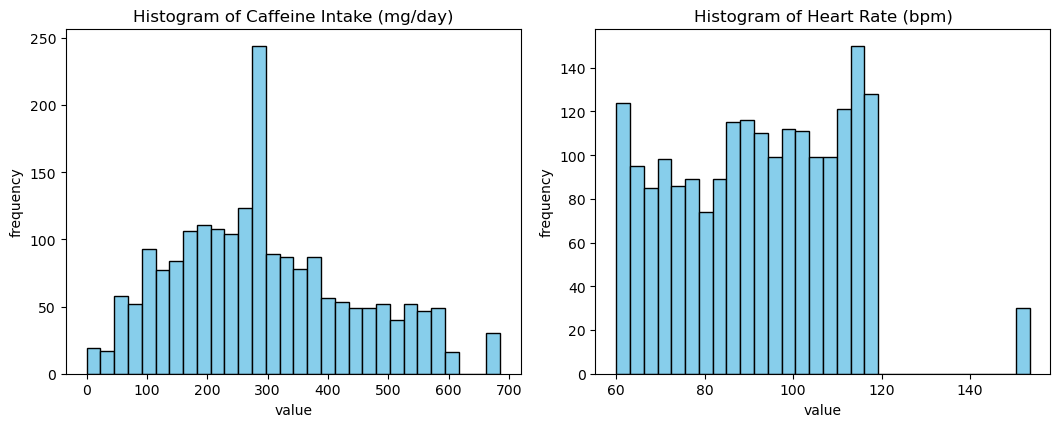

In [374]:
plt.figure(figsize=(16,12))
for i,col in enumerate(['Caffeine Intake (mg/day)','Heart Rate (bpm)']):
    plt.subplot(3,3,i+1)
    plt.hist(df_copy[col],bins=30,edgecolor="black",color='skyblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel('value')
    plt.ylabel('frequency')

plt.tight_layout()
plt.show()

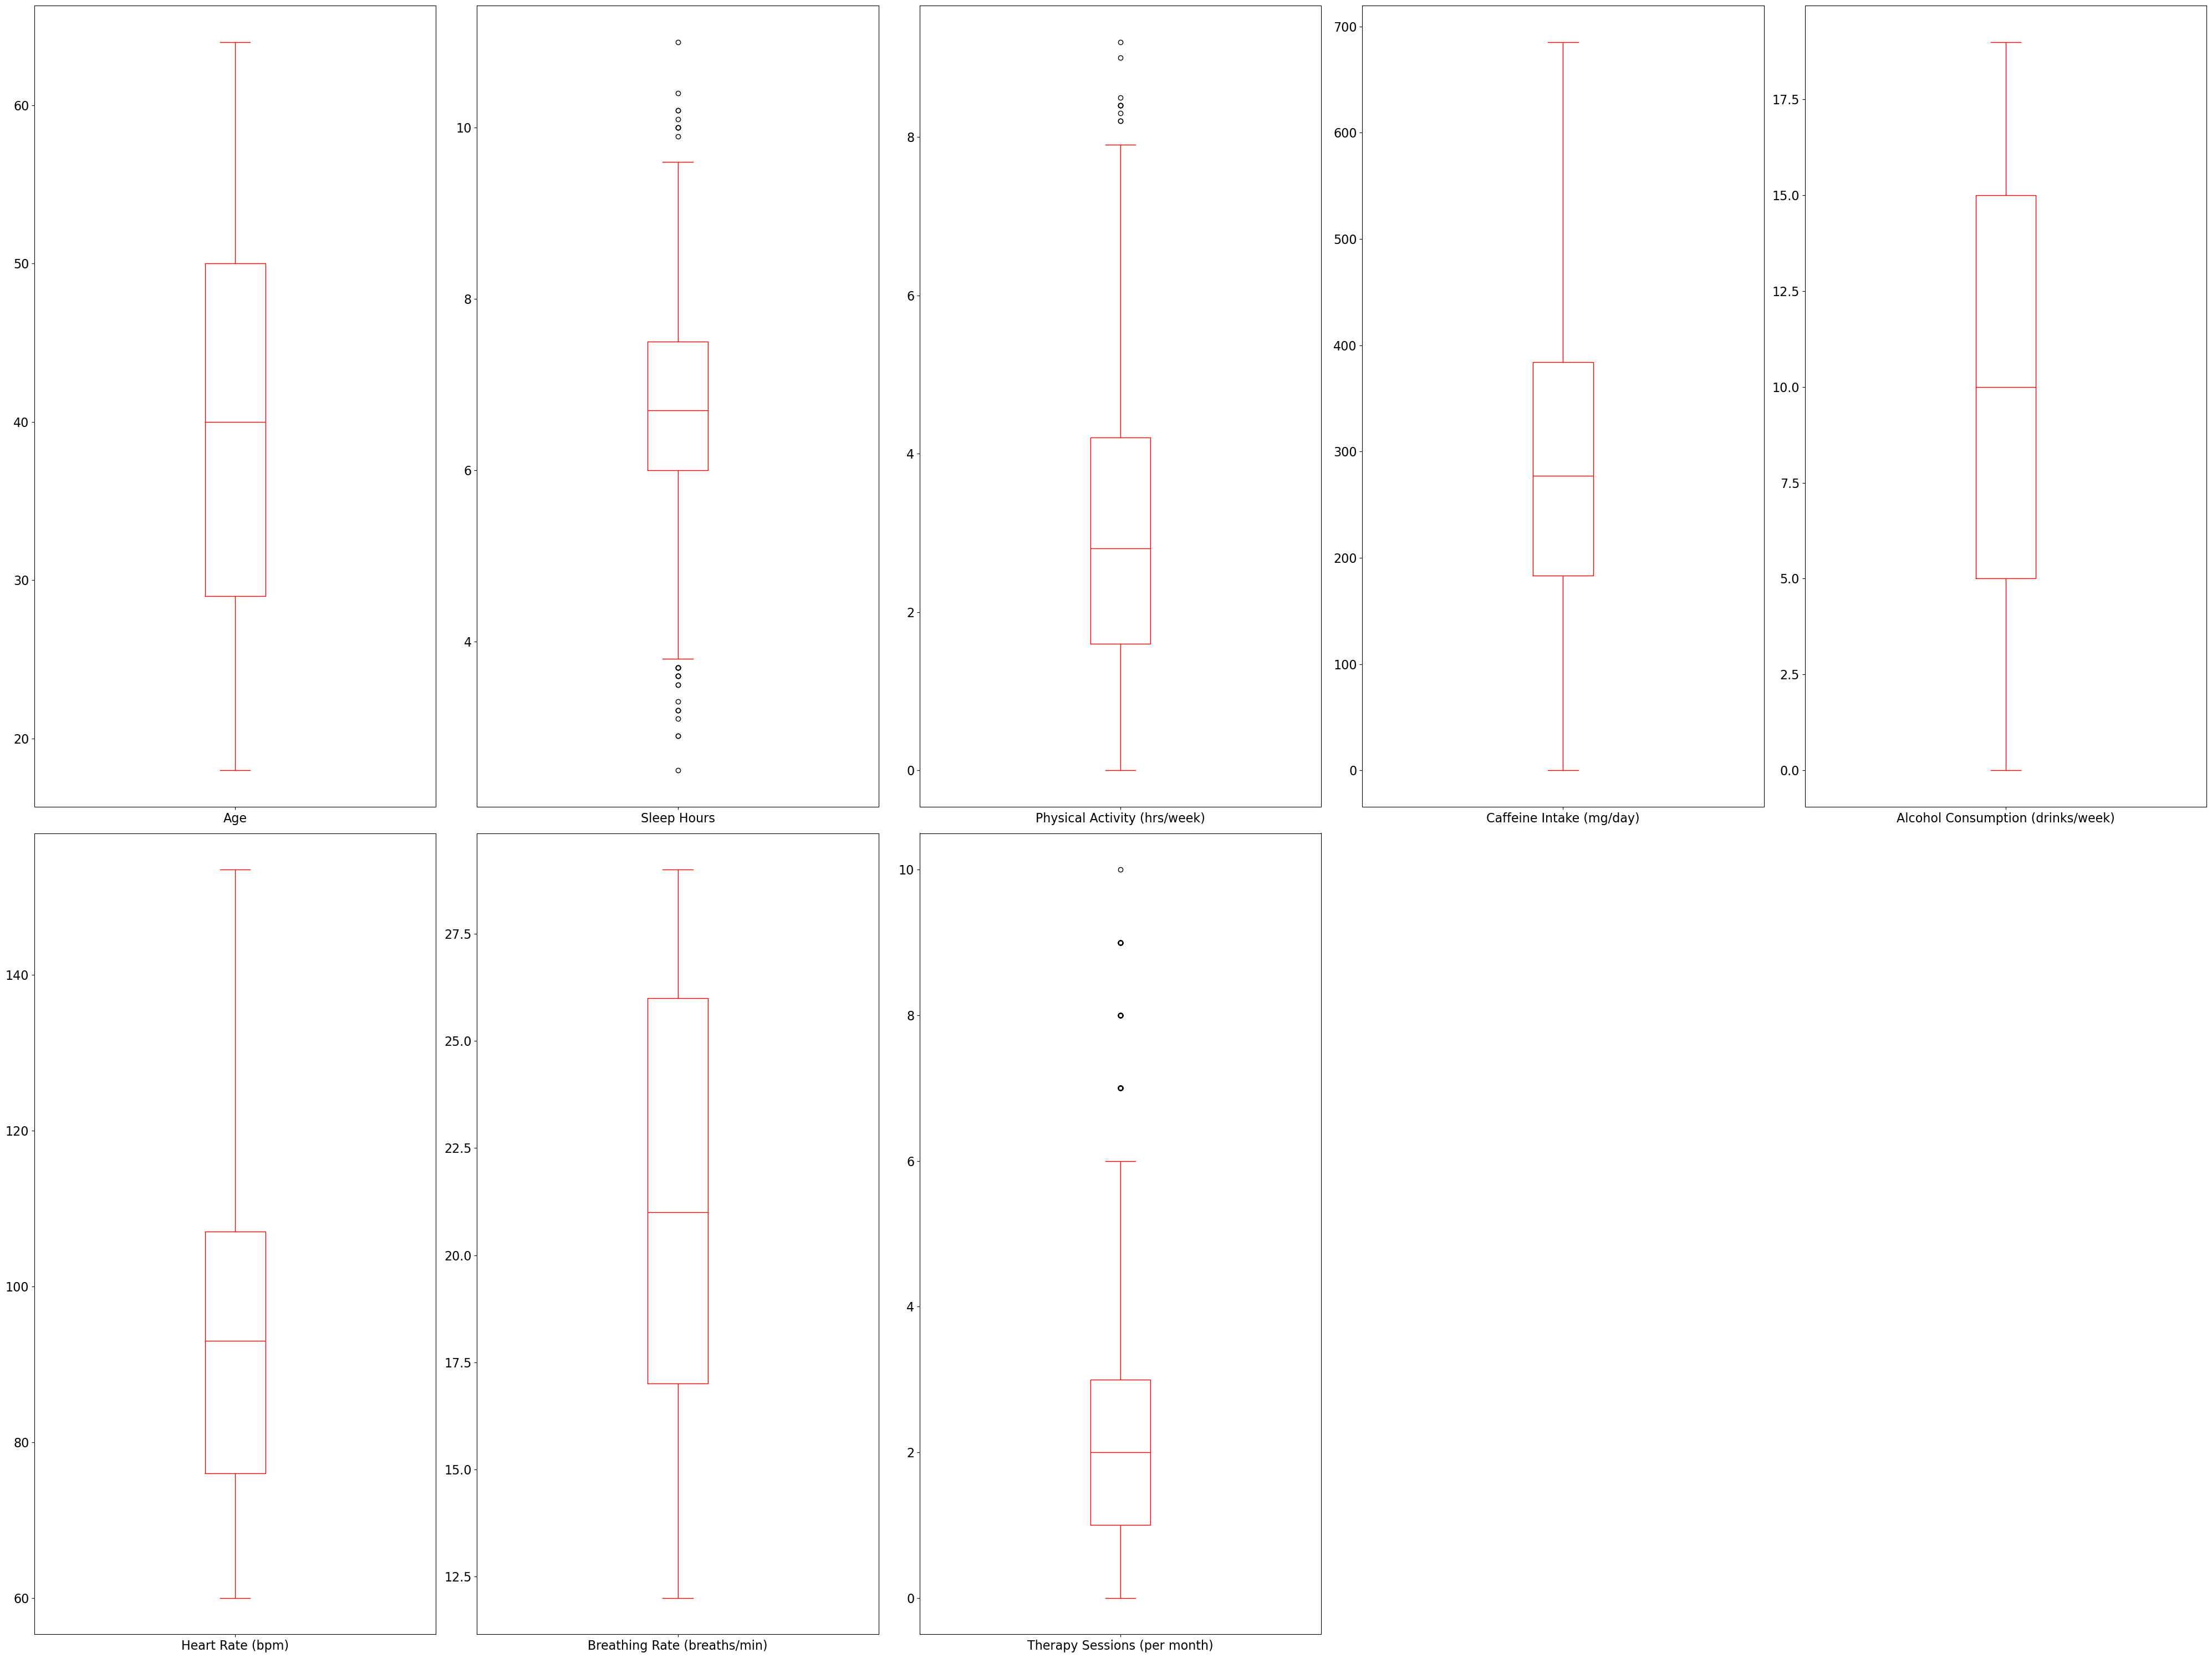

In [375]:
df_copy[numeric_cols].plot(
    kind='box',
    subplots=True,
    sharey=False,
    layout=(2,int(len(numeric_cols)/2)+1),
    figsize=(40,30),
    color = 'r',
    fontsize= 16
)
plt.tight_layout()
plt.show()


In [376]:
df_copy.loc[df_copy['Stress Level (1-10)']>10,'Stress Level (1-10)']=10

In [377]:
df_copy['Stress Level (1-10)'].unique()

array([ 4,  3,  9, 10,  1,  7,  2,  8,  6,  5], dtype=int64)

In [378]:
df_copy.describe()

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Therapy Sessions (per month),Diet Quality (1-10),Anxiety Level (1-10),is_Anxious
count,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000,2030.000000
mean,39.924138,6.672365,2.973645,292.883251,9.790640,5.954680,92.083744,20.955665,3.095567,2.359113,5.148276,3.922660,0.103448
std,13.039847,1.198796,1.782468,148.936671,5.629081,2.979959,18.929407,5.182524,1.392697,2.148642,2.861375,2.139176,0.304619
min,18.000000,2.500000,0.000000,0.000000,0.000000,1.000000,60.000000,12.000000,1.000000,0.000000,1.000000,1.000000,0.000000
25%,29.000000,6.000000,1.600000,183.000000,5.000000,3.000000,76.000000,17.000000,2.000000,1.000000,3.000000,2.000000,0.000000
50%,40.000000,6.700000,2.800000,277.000000,10.000000,6.000000,93.000000,21.000000,3.000000,2.000000,5.000000,4.000000,0.000000
75%,50.000000,7.500000,4.200000,384.000000,15.000000,9.000000,107.000000,26.000000,4.000000,3.000000,8.000000,5.000000,0.000000
max,64.000000,11.000000,9.200000,685.500000,19.000000,10.000000,153.500000,29.000000,5.000000,10.000000,10.000000,10.000000,1.000000


KPI

In [379]:
import pandas as pd
#انتخاب ستون های عددی برای محاسبه kpiها
numeric_kpi_cols = [
    'Age',
    'Sleep Hours',
    'Physical Activity (hrs/week)',
    'Caffeine Intake (mg/day)',
    'Alcohol Consumption (drinks/week)',
    'Stress Level (1-10)',
    'Anxiety Level (1-10)',
    'Heart Rate (bpm)',
    'Breathing Rate (breaths/min)',
    'Therapy Sessions (per month)',
    'Sweating Level (1-5)',
    'Diet Quality (1-10)'
]
#ساختن یک دیکشنری برای ذخیره kpiها
kpi = {}

for col in numeric_kpi_cols:
    kpi[col] = {
        #محاسبه 
        'mean': df_copy[col].mean(),#میانگین
        'median': df_copy[col].median(),#میانه
        'min': df_copy[col].min(),
        'max': df_copy[col].max(),
        'std': df_copy[col].std()#انحراف معیار
    }
#محاسبه درصد افراد مضطرب
kpi['Percentage_Anxious'] = df_copy['is_Anxious'].mean() * 100
#نمایش دادن جدول 

kpi_df = pd.DataFrame(kpi).T
kpi_df


,mean,median,min,max,std
Age,39.924138,40.000000,18.000000,64.000000,13.039847
Sleep Hours,6.672365,6.700000,2.500000,11.000000,1.198796
Physical Activity (hrs/week),2.973645,2.800000,0.000000,9.200000,1.782468
Caffeine Intake (mg/day),292.883251,277.000000,0.000000,685.500000,148.936671
Alcohol Consumption (drinks/week),9.790640,10.000000,0.000000,19.000000,5.629081
Stress Level (1-10),5.954680,6.000000,1.000000,10.000000,2.979959
Anxiety Level (1-10),3.922660,4.000000,1.000000,10.000000,2.139176
Heart Rate (bpm),92.083744,93.000000,60.000000,153.500000,18.929407
Breathing Rate (breaths/min),20.955665,21.000000,12.000000,29.000000,5.182524
Therapy Sessions (per month),2.359113,2.000000,0.000000,10.000000,2.148642


این جدول بدست امده از kpi است 
میانگین میانه بیشترنی و کمترین و انحراف معبار ستون های عددی را به ما میدهد

BINNING
بعضی ستون ها انتخاب شدند 
عددی و پیوسته هستند
دارای بازه ی قابل بررسی هستند 
این ۴ تا ستون اینجوری انتخاب شدند 

BINNIG
1-AGE

بر اساس جدول قبلی بدست اومد که سن بیشترین و کمترین ۱۸ و ۶۴ است پس تقسیم بندی به صورت زیر انجام میشود

In [380]:
age_bins = [18, 30, 40, 50, 64]
age_labels = ['18-30', '31-40', '41-50', '51-64']

df_copy['Age_group'] = pd.cut(
    df_copy['Age'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)


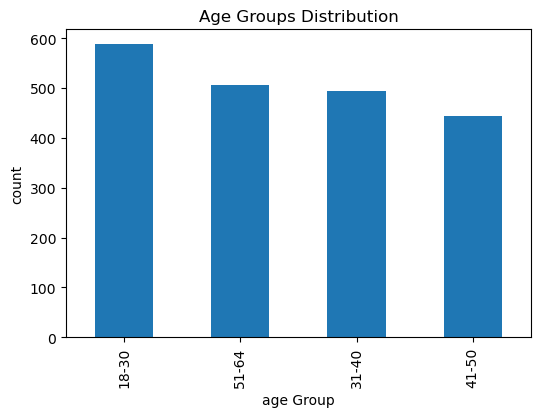

In [381]:
df_copy['Age_group'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Age Groups Distribution")
plt.xlabel("age Group")
plt.ylabel("count")
plt.show()
#نشون دادن جدول 


BINNIG
2-ANXIETY LEVEL

In [382]:
df_copy['Anxiety_category'] = pd.qcut(
    df_copy['Anxiety Level (1-10)'],
    q=3,
    labels=['Low', 'Medium', 'High']
)


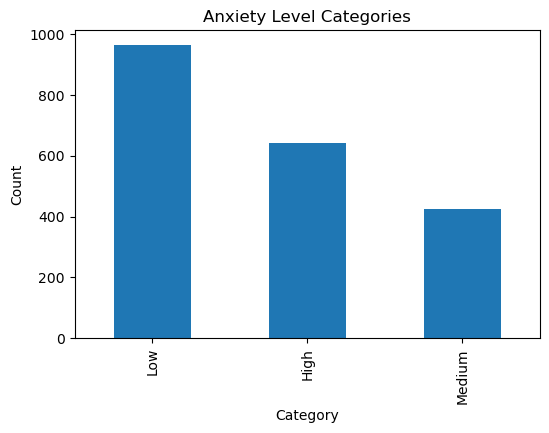

In [383]:
df_copy['Anxiety_category'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Anxiety Level Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()


BINNIG
3-STRESS LEVEL

In [384]:
df_copy['Stress_category'] = pd.qcut(
    df_copy['Stress Level (1-10)'],
    q=3,
    labels=['Low', 'Medium', 'High']
)


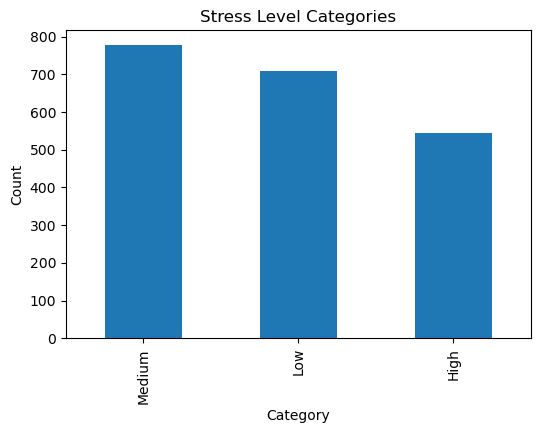

In [385]:
df_copy['Stress_category'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Stress Level Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()


BINNING
4-SLEEP HOURS

In [386]:
sleep_bins = [-1, 4, 7, 12]  
sleep_labels = ['Low (<4h)', 'Normal (4-7h)', 'High (>7h)']

df_copy['Sleep_category'] = pd.cut(
    df_copy['Sleep Hours'],
    bins=sleep_bins,
    labels=sleep_labels
)


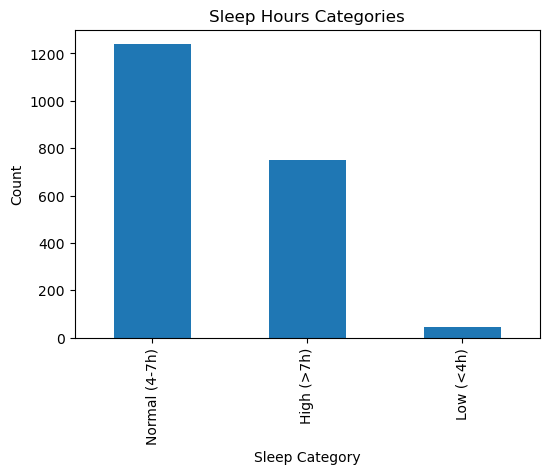

In [387]:
df_copy['Sleep_category'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Sleep Hours Categories")
plt.xlabel("Sleep Category")
plt.ylabel("Count")
plt.show()


MERGING REAR CATEGORIES 

In [388]:
categorical_merge_cols = [
    'Gender',
    'Occupation',
    'Smoking',
    'Family History of Anxiety',
    'Dizziness',
    'Medication',
    'Recent Major Life Event'
]

threshold = 0.02  

for col in categorical_merge_cols:
    freq = df_copy[col].value_counts(normalize=True)
    small_categories = freq[freq < threshold].index
    merged_col = col + '_merged'
    df_copy[merged_col] = df_copy[col].astype('object')
    df_copy.loc[df_copy[col].isin(small_categories), merged_col] = 'Other'


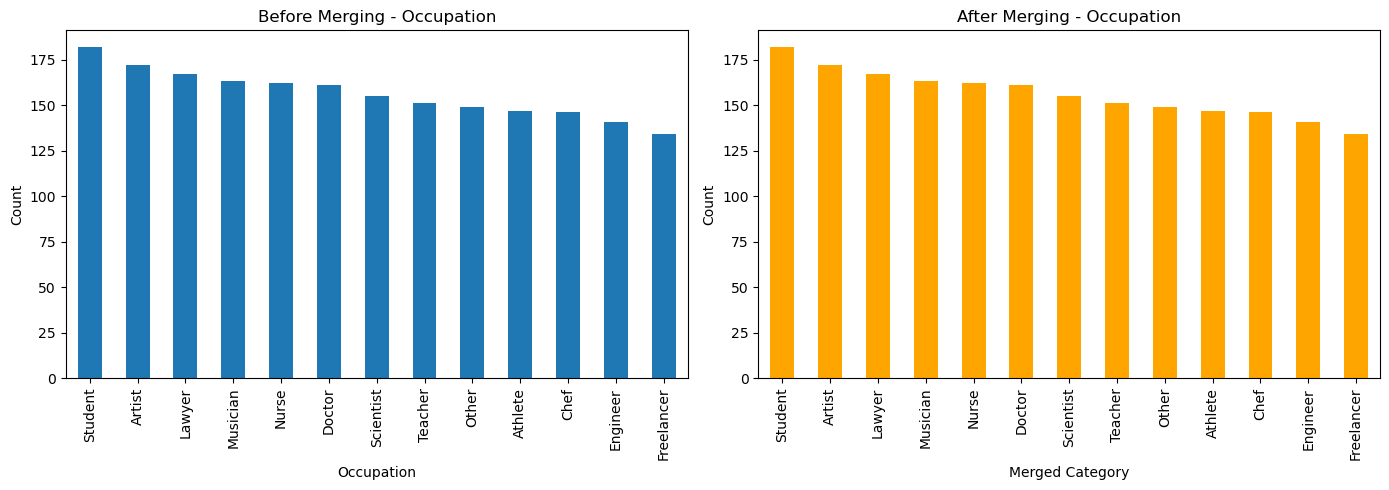

In [389]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))

df_copy['Occupation'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title("Before Merging - Occupation")
axes[0].set_xlabel("Occupation")
axes[0].set_ylabel("Count")

df_copy['Occupation_merged'].value_counts().plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title("After Merging - Occupation")
axes[1].set_xlabel("Merged Category")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [390]:
import pandas as pd
df = df_copy
#تعداد ستونهای عددی و  و نام انها
categorical = []
numerical = []
for i in df.columns:
    if df[i].dtype == "object":
        categorical.append(i)
    else:
        numerical.append(i)
print("Categorical_Count:", len(categorical))
print(categorical)
print("Numerical_Count:", len(numerical))
print(numerical)


Categorical_Count: 14
['Gender', 'Occupation', 'Smoking', 'Family History of Anxiety', 'Dizziness', 'Medication', 'Recent Major Life Event', 'Gender_merged', 'Occupation_merged', 'Smoking_merged', 'Family History of Anxiety_merged', 'Dizziness_merged', 'Medication_merged', 'Recent Major Life Event_merged']
Numerical_Count: 17
['Age', 'Sleep Hours', 'Physical Activity (hrs/week)', 'Caffeine Intake (mg/day)', 'Alcohol Consumption (drinks/week)', 'Stress Level (1-10)', 'Heart Rate (bpm)', 'Breathing Rate (breaths/min)', 'Sweating Level (1-5)', 'Therapy Sessions (per month)', 'Diet Quality (1-10)', 'Anxiety Level (1-10)', 'is_Anxious', 'Age_group', 'Anxiety_category', 'Stress_category', 'Sleep_category']


ستون: Gender
Gender
Female    776
Other     627
Male      627
Name: count, dtype: int64
کمترین فراوانی: 627
بیشترین فراوانی: 776
اختلاف بیشترین و کمترین: 149


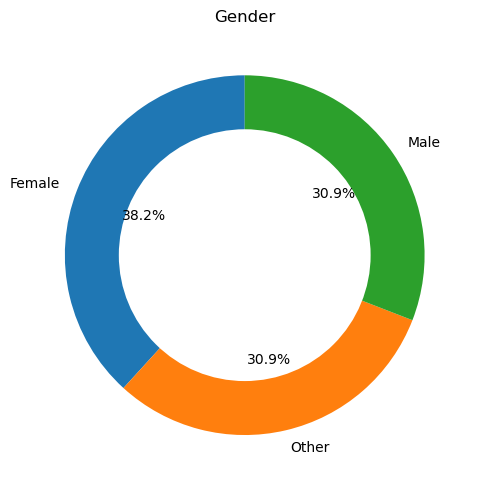

ستون: Occupation
Occupation
Student       182
Artist        172
Lawyer        167
Musician      163
Nurse         162
Doctor        161
Scientist     155
Teacher       151
Other         149
Athlete       147
Chef          146
Engineer      141
Freelancer    134
Name: count, dtype: int64
کمترین فراوانی: 134
بیشترین فراوانی: 182
اختلاف بیشترین و کمترین: 48


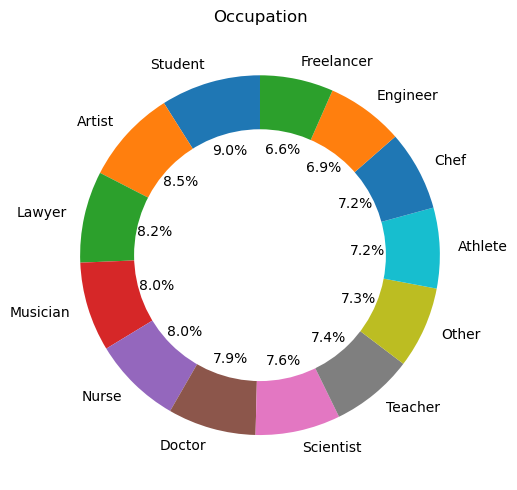

ستون: Smoking
Smoking
Yes    1126
No      904
Name: count, dtype: int64
کمترین فراوانی: 904
بیشترین فراوانی: 1126
اختلاف بیشترین و کمترین: 222


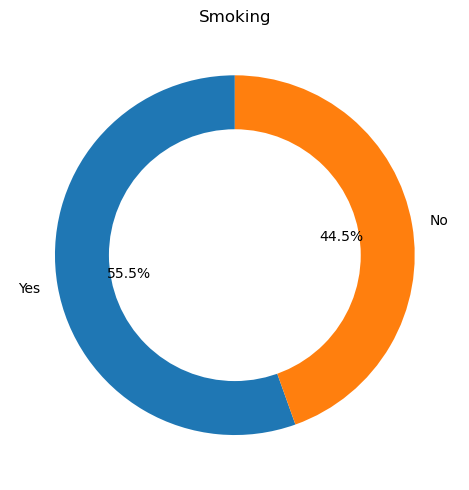

ستون: Family History of Anxiety
Family History of Anxiety
Yes    1058
No      972
Name: count, dtype: int64
کمترین فراوانی: 972
بیشترین فراوانی: 1058
اختلاف بیشترین و کمترین: 86


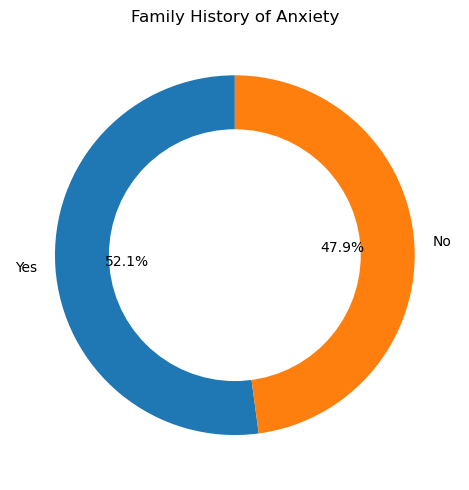

ستون: Dizziness
Dizziness
Yes    1049
No      981
Name: count, dtype: int64
کمترین فراوانی: 981
بیشترین فراوانی: 1049
اختلاف بیشترین و کمترین: 68


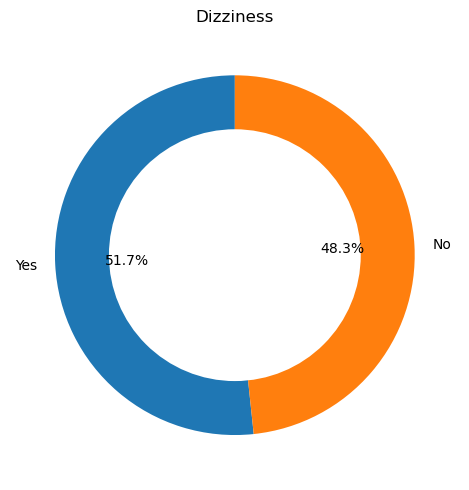

ستون: Medication
Medication
Yes    1073
No      957
Name: count, dtype: int64
کمترین فراوانی: 957
بیشترین فراوانی: 1073
اختلاف بیشترین و کمترین: 116


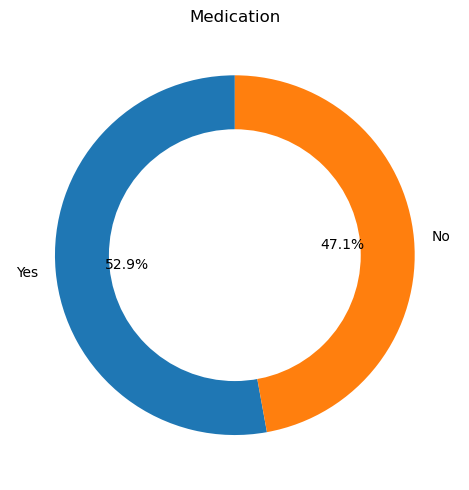

ستون: Recent Major Life Event
Recent Major Life Event
Yes    1040
No      990
Name: count, dtype: int64
کمترین فراوانی: 990
بیشترین فراوانی: 1040
اختلاف بیشترین و کمترین: 50


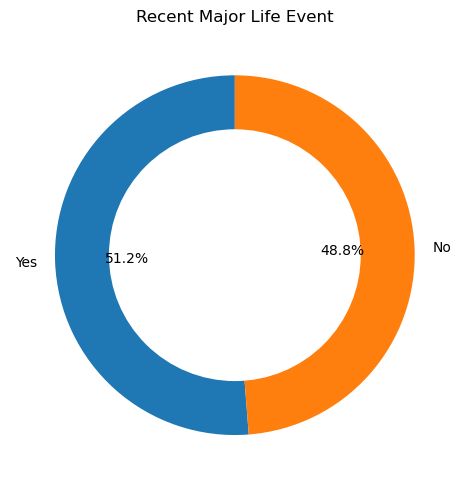

ستون: Gender_merged
Gender_merged
Female    776
Other     627
Male      627
Name: count, dtype: int64
کمترین فراوانی: 627
بیشترین فراوانی: 776
اختلاف بیشترین و کمترین: 149


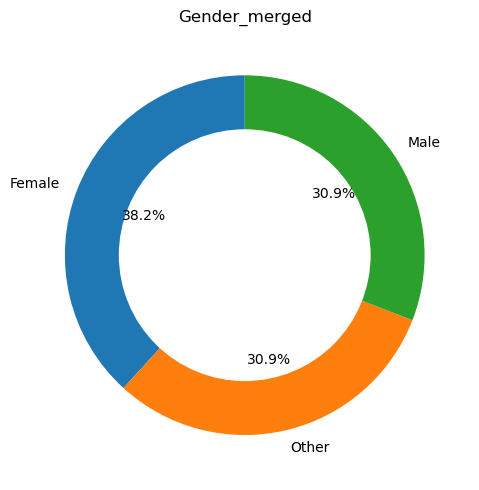

In [391]:
import matplotlib.pyplot as plt
for i in range(8):
    counts = df[categorical[i]].value_counts()
    print("ستون:", categorical[i])
    print(counts)
    print("کمترین فراوانی:", counts.min())
    print("بیشترین فراوانی:", counts.max())
    print("اختلاف بیشترین و کمترین:", counts.max() - counts.min())
    plt.figure(figsize=(6,5))
    plt.pie(counts.values, labels=counts.index,startangle=90,autopct='%1.1f%%'),
    centre_circle = plt.Circle((0, 0), 0.70, fc='white',)
    plt.gca().add_artist(centre_circle)
    plt.title(categorical[i])
    plt.tight_layout()
    plt.show()


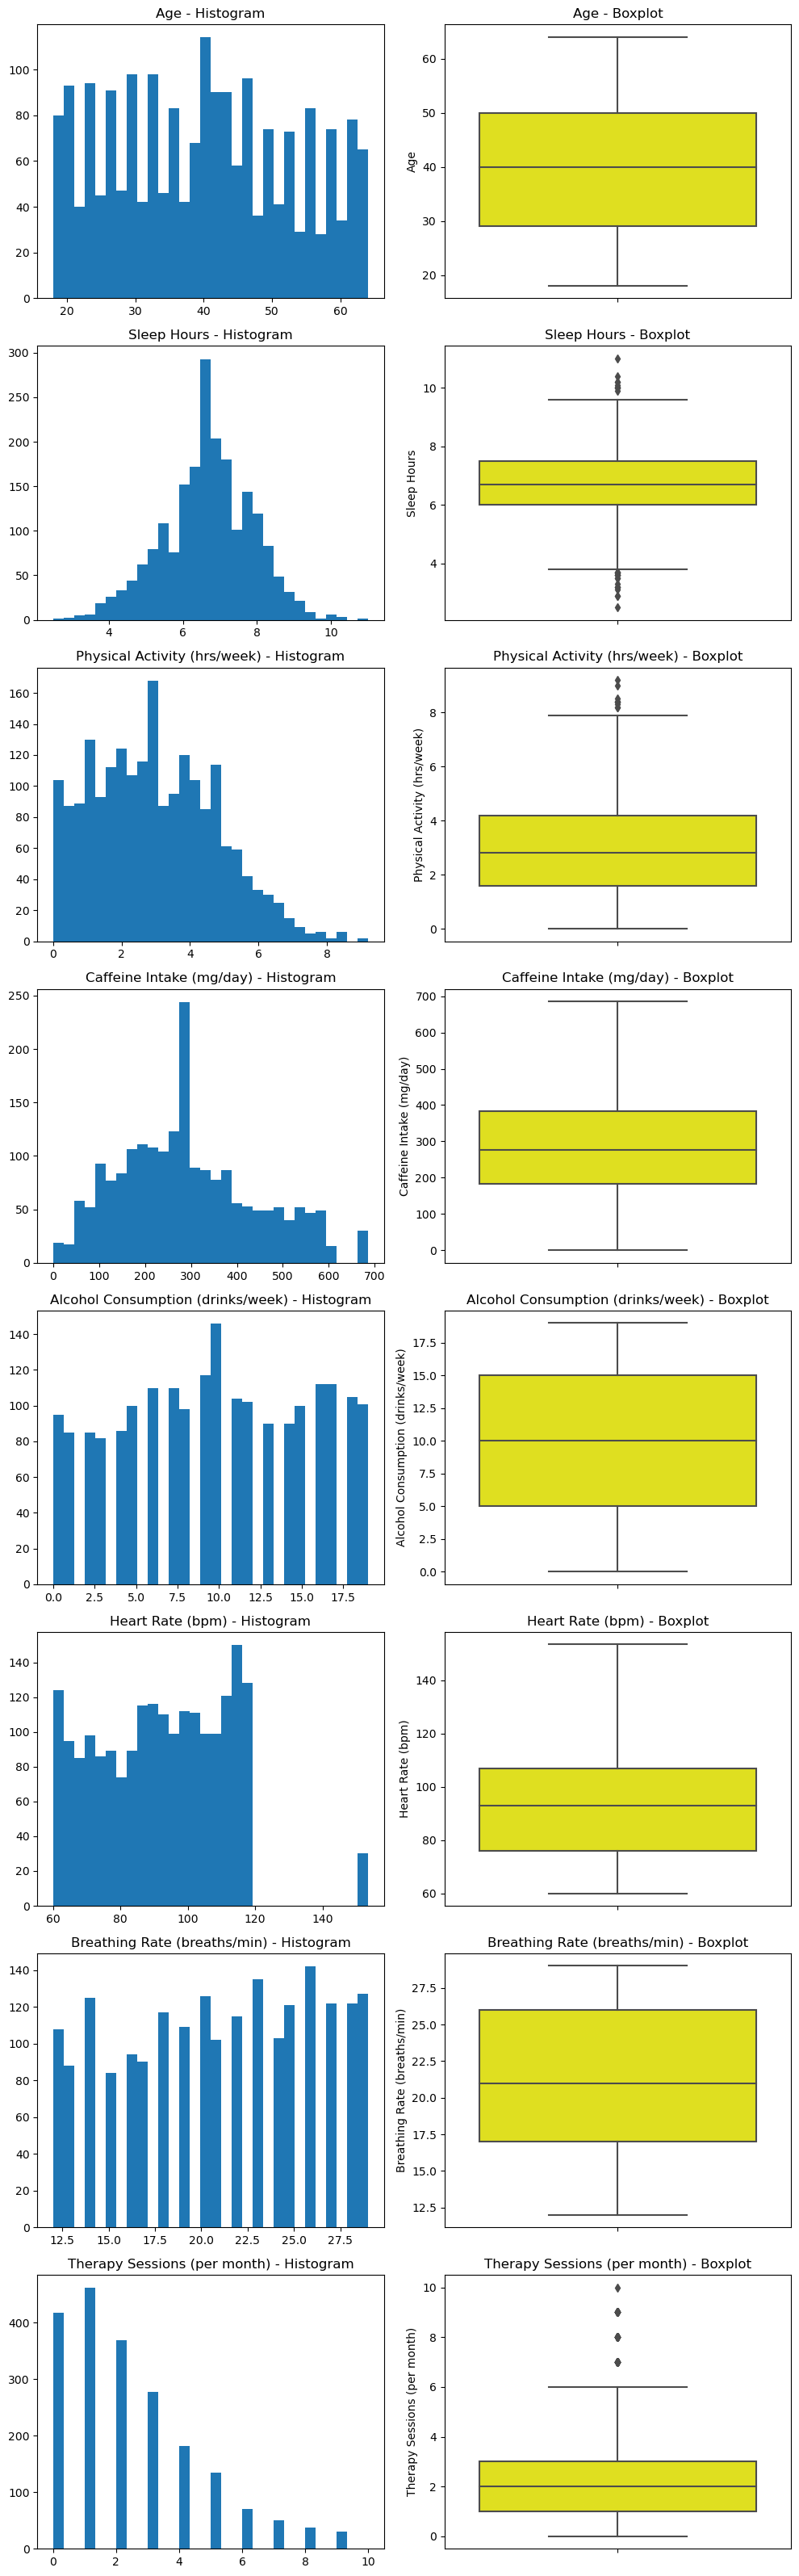

In [392]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows=len(numeric_cols),
    ncols=2,
    figsize=(10, 4 * len(numeric_cols))
)

for i in range(len(numeric_cols)):
    col = numeric_cols[i]
    data = df_copy[col]

    # Histogram
    axes[i, 0].hist(data, bins=30)
    axes[i, 0].set_title(f"{col} - Histogram")

    # Boxplot
    sns.boxplot(
        y=data,
        ax=axes[i, 1],
        color='yellow'
    )
    axes[i, 1].set_title(f"{col} - Boxplot")

plt.tight_layout()
plt.show()



In [393]:
from scipy.stats import skew, shapiro
for i in numerical:
    print("ستون:", i)
    data = df_copy[i]
    data = pd.to_numeric(df_copy[col])
    data = data.replace([np.inf, -np.inf], np.nan).dropna()
    # چولگی
    s = skew(data)
    print("Skewness:", s)
    if s > 0:
        print("چوله به راسته")
    elif s < 0:
        print("چوله به چپه")
    else:
        print("تقریبا متقارن")

    p_value = shapiro(data)[1]
    print("Shapiro p-value:", p_value)
    if p_value > 0.05:
        print("توزیع نرماله")
    else:
        print("توزیع نه نرماله")
    # تعداد مدها (ساده)
    modes = data.value_counts()
    print("تعداد مدها:", (modes == modes.max()).sum())
    print("******************************************************************")

ستون: Age
Skewness: 1.0522571131272644
چوله به راسته
Shapiro p-value: 1.8219236070650225e-36
توزیع نه نرماله
تعداد مدها: 1
******************************************************************
ستون: Sleep Hours
Skewness: 1.0522571131272644
چوله به راسته
Shapiro p-value: 1.8219236070650225e-36
توزیع نه نرماله
تعداد مدها: 1
******************************************************************
ستون: Physical Activity (hrs/week)
Skewness: 1.0522571131272644
چوله به راسته
Shapiro p-value: 1.8219236070650225e-36
توزیع نه نرماله
تعداد مدها: 1
******************************************************************
ستون: Caffeine Intake (mg/day)
Skewness: 1.0522571131272644
چوله به راسته
Shapiro p-value: 1.8219236070650225e-36
توزیع نه نرماله
تعداد مدها: 1
******************************************************************
ستون: Alcohol Consumption (drinks/week)
Skewness: 1.0522571131272644
چوله به راسته
Shapiro p-value: 1.8219236070650225e-36
توزیع نه نرماله
تعداد مدها: 1
*********************************

اثر ها

In [394]:
from scipy.stats import spearmanr
import pandas as pd

numeric_cols=["Sleep Hours","Stress Level (1-10)","Caffeine Intake (mg/day)","Alcohol Consumption (drinks/week)","Physical Activity (hrs/week)",
            "Heart Rate (bpm)","Breathing Rate (breaths/min)","Therapy Sessions (per month)","Diet Quality (1-10)","Anxiety Level (1-10)"]
n=len(numeric_cols)
res=[]
for i in range(n):
    for j in range(i+1,n):
        col1=numeric_cols[i]
        col2=numeric_cols[j]
        corr,pval=spearmanr(df_copy[col1],df_copy[col2])
        if abs(corr) >= 0.3:
            res.append({"Variable 1": col1,"Variable 2": col2,"Spearman Corr": round(corr,5)})
corr_df=pd.DataFrame(res)
corr_df=corr_df.sort_values(by="Spearman Corr",key=abs,ascending=False)
corr_df


,Variable 1,Variable 2,Spearman Corr
1,Stress Level (1-10),Anxiety Level (1-10),0.70240
0,Sleep Hours,Anxiety Level (1-10),-0.34282
2,Therapy Sessions (per month),Anxiety Level (1-10),0.33521


اثر سطح استرس بر سطح اضطراب


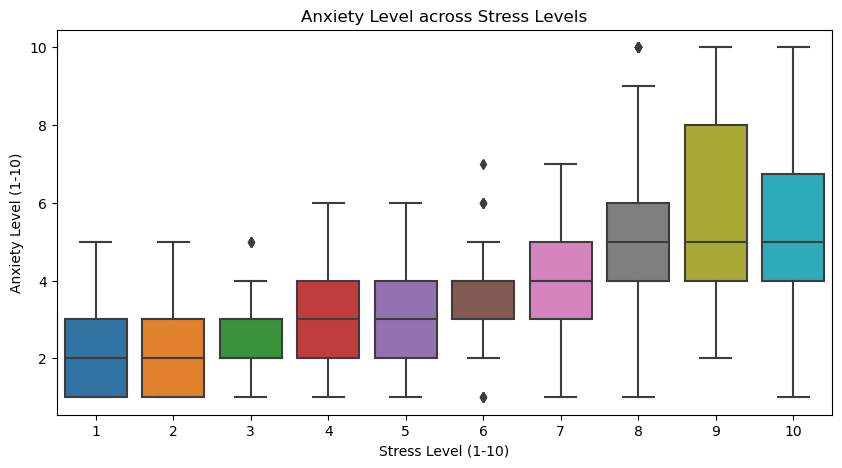

Spearman correlation = 0.7023989983610314
p-value = 9.184030897628018e-302


In [395]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Stress Level (1-10)",y="Anxiety Level (1-10)",data=df_copy)
plt.title("Anxiety Level across Stress Levels")
plt.show()

corr,p=spearmanr(df_copy["Stress Level (1-10)"],df_copy["Anxiety Level (1-10)"])
print(f"Spearman correlation = {corr}")
print(f"p-value = {p}")


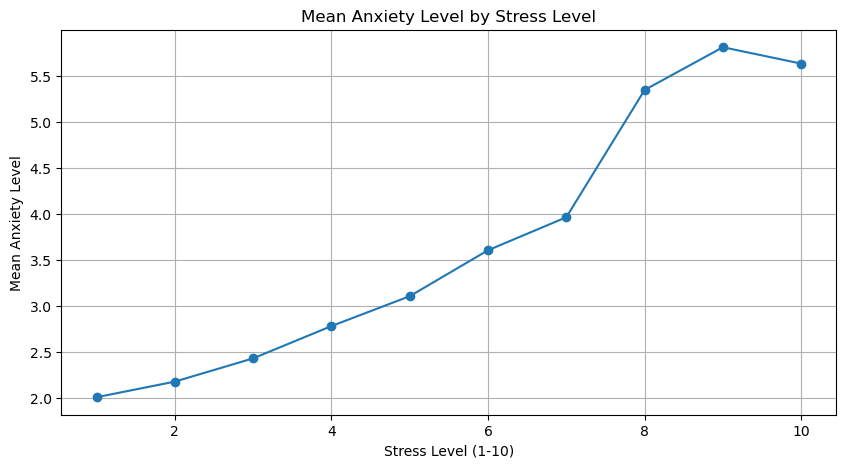

In [396]:
anxiety=df_copy.groupby("Stress Level (1-10)")["Anxiety Level (1-10)"]
mean_anxiety=anxiety.mean()
plt.figure(figsize=(10,5))
mean_anxiety.plot(marker="o")
plt.xlabel("Stress Level (1-10)")
plt.ylabel("Mean Anxiety Level")
plt.title("Mean Anxiety Level by Stress Level")
plt.grid(True)
plt.show()

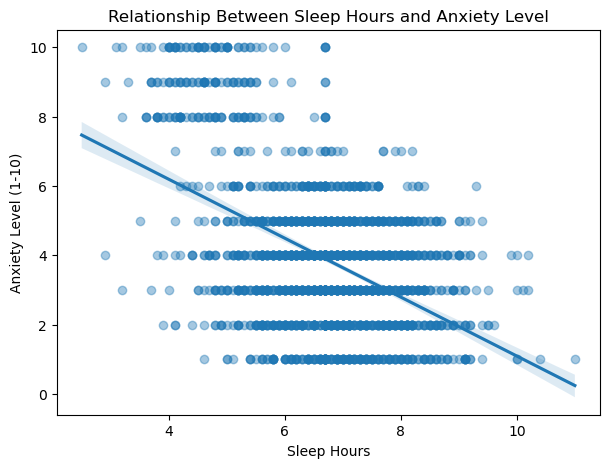

Spearman correlation = -0.34282250663765423
p-value = 4.495756450315257e-57


In [397]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

plt.figure(figsize=(7,5))
sns.regplot(x="Sleep Hours",y="Anxiety Level (1-10)",scatter_kws={"alpha":0.4},data=df_copy)
plt.title("Relationship Between Sleep Hours and Anxiety Level")
plt.show()
corr,p=spearmanr(df_copy["Sleep Hours"],df_copy["Anxiety Level (1-10)"])
print(f"Spearman correlation = {corr}")
print(f"p-value = {p}")

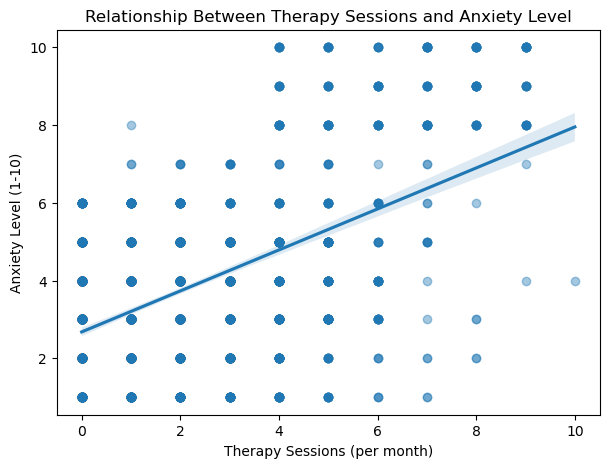

Spearman correlation = 0.3352108493441408
p-value = 1.699844493995982e-54


In [398]:
plt.figure(figsize=(7,5))
sns.regplot(data=df_copy,x="Therapy Sessions (per month)",y="Anxiety Level (1-10)", scatter_kws={"alpha":0.4})
plt.title("Relationship Between Therapy Sessions and Anxiety Level")
plt.show()
corr,p=spearmanr(df_copy["Therapy Sessions (per month)"],df_copy["Anxiety Level (1-10)"])
print(f"Spearman correlation = {corr}")
print(f"p-value = {p}")

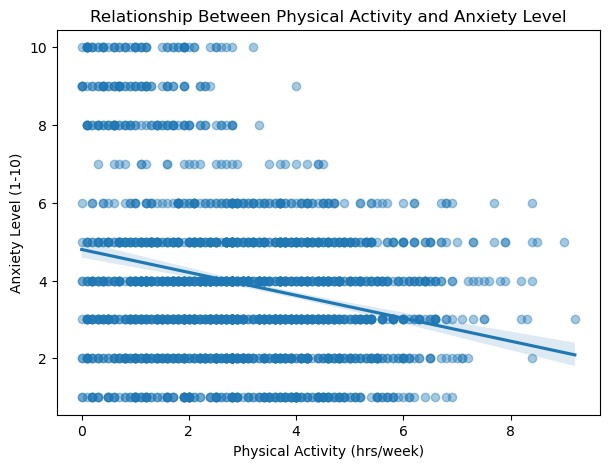

Spearman correlation = -0.18139883510731722
p-value = 1.774615085699856e-16


In [399]:
plt.figure(figsize=(7,5))
sns.regplot(data=df_copy,x="Physical Activity (hrs/week)",y="Anxiety Level (1-10)",scatter_kws={"alpha":0.4})
plt.title("Relationship Between Physical Activity and Anxiety Level")
plt.show()
corr,p=spearmanr(df_copy["Physical Activity (hrs/week)"],df_copy["Anxiety Level (1-10)"])
print(f"Spearman correlation = {corr}")
print(f"p-value = {p}")

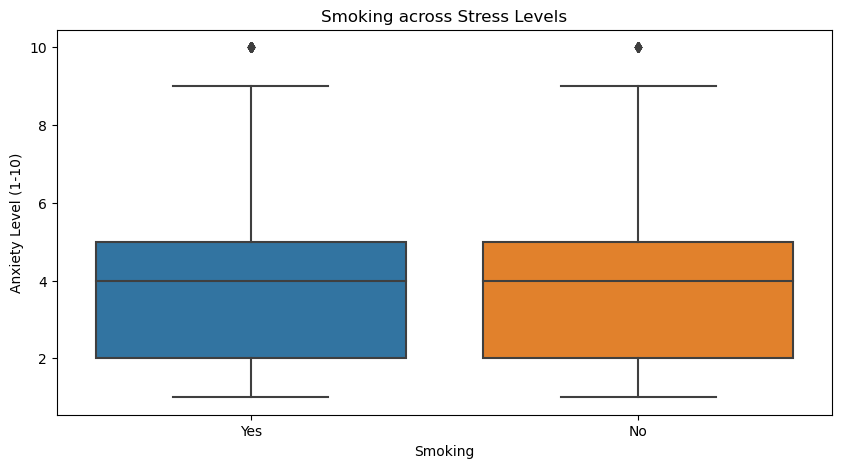

Spearman correlation = 0.06540566341401034
p-value = 0.0031960095052471385
mannwhitneyu p-value = 0.0032178575806465445


In [400]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Smoking",y="Anxiety Level (1-10)",data=df_copy)
plt.title("Smoking across Stress Levels")
plt.show()

corr,p=spearmanr(df_copy["Smoking"],df_copy["Anxiety Level (1-10)"])
print(f"Spearman correlation = {corr}")
print(f"p-value = {p}")

from scipy.stats import mannwhitneyu
yes=df_copy[df_copy["Smoking"]=="Yes"]["Anxiety Level (1-10)"]
no=df_copy[df_copy["Smoking"]=="No"]["Anxiety Level (1-10)"]
stat,p1=mannwhitneyu(yes,no)
print(f"mannwhitneyu p-value = {p1}")


Binned Features Effect on Anxiety Level


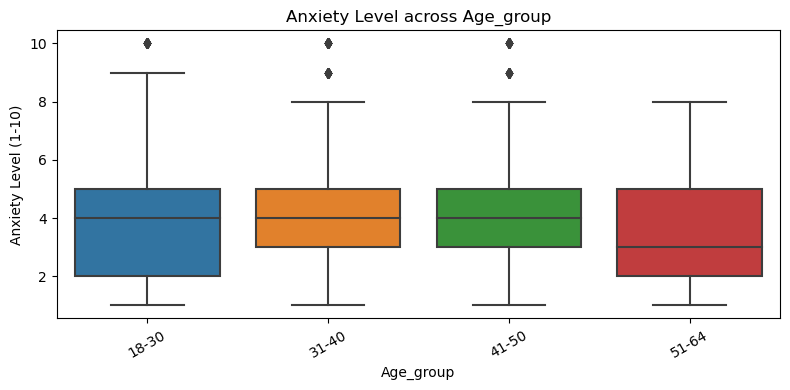

Age_group vs Anxiety Level (1-10) | ANOVA | p-value = 9.7717636467203e-08


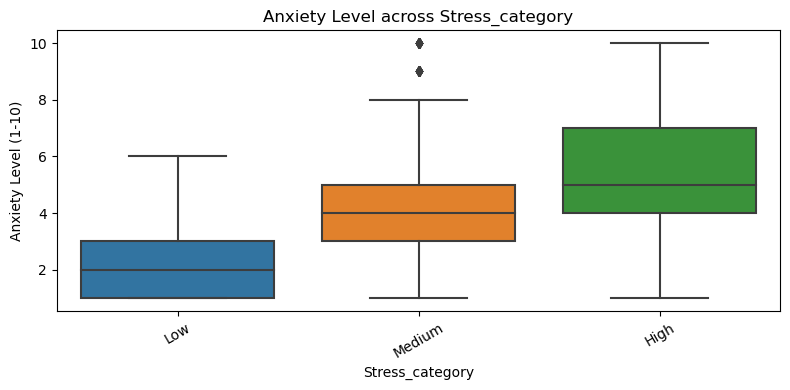

Stress_category vs Anxiety Level (1-10) | ANOVA | p-value = 1.0098772859816946e-212


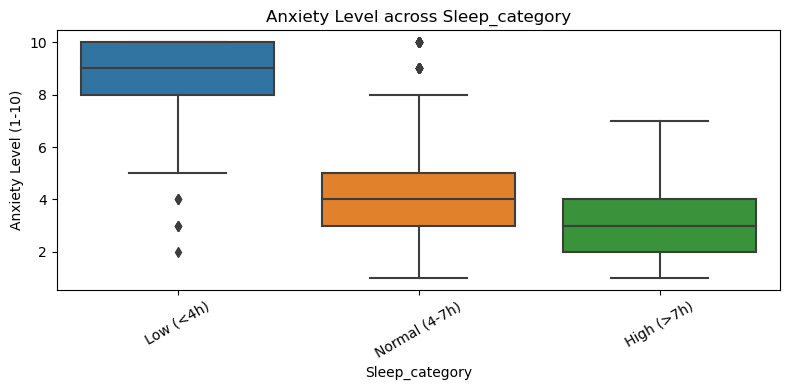

Sleep_category vs Anxiety Level (1-10) | ANOVA | p-value = 2.2580243390754626e-64


In [401]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, kruskal, f_oneway

binned_cols=["Age_group","Stress_category","Sleep_category"]
target="Anxiety Level (1-10)"
print("Binned Features Effect on Anxiety Level")

for col in binned_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df_copy, x=col,y=target)
    plt.title(f"Anxiety Level across {col}")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
    groups=[df_copy[df_copy[col]==m][target] for m in df_copy[col].unique()]
    groups=[g for g in groups if len(g)>5]

    if len(groups)<2:
        continue
    if len(groups)==2:
        stat,pval=mannwhitneyu(groups[0],groups[1],alternative="two-sided")
        test="Mann-Whitney U"
    else:
        normal=min([len(g) for g in groups])>=30
        if normal:
            stat,pval=f_oneway(*groups)
            test="ANOVA"
        else:
            stat, pval=kruskal(*groups)
            test_="Kruskal-Wallis"
    print(f"{col} vs {target} | {test} | p-value = {pval}")

دو متغیره

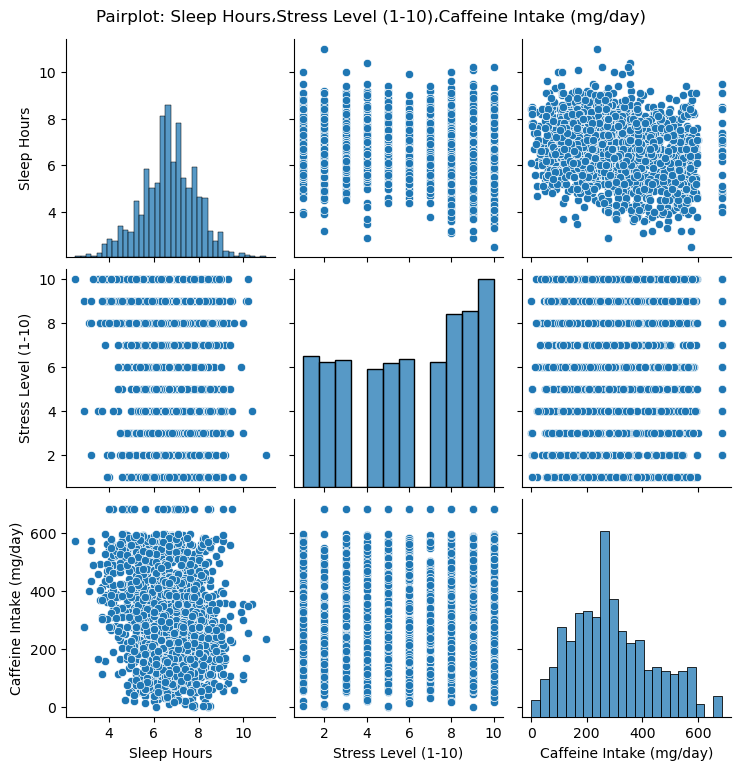

Sleep Hours vs Stress Level (1-10) -> spearman corr = -0.12104313541339323
Sleep Hours vs Caffeine Intake (mg/day) -> spearman corr = -0.16769238483048898
Stress Level (1-10) vs Caffeine Intake (mg/day) -> spearman corr = 0.11636427978651975


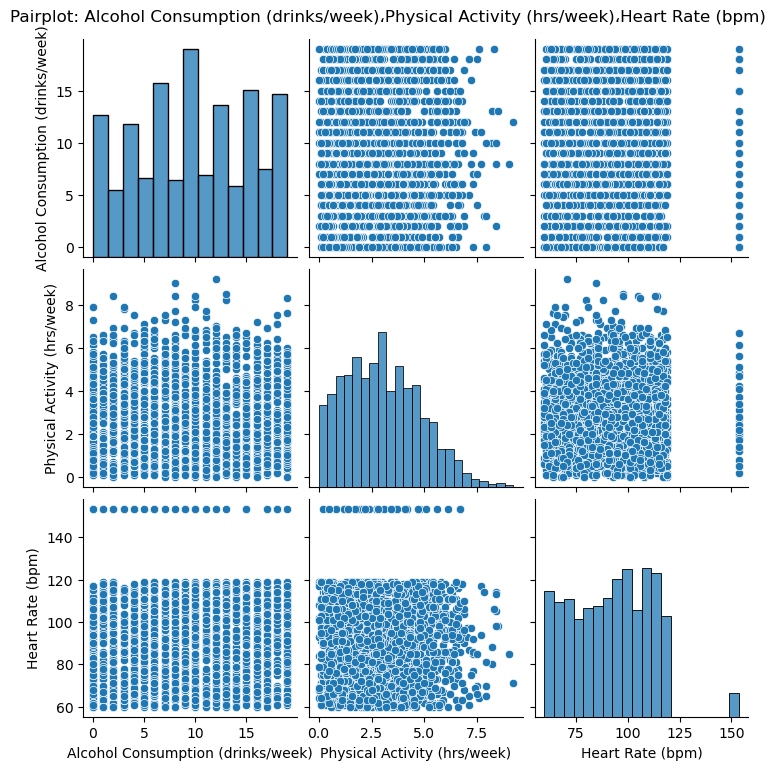

Alcohol Consumption (drinks/week) vs Physical Activity (hrs/week) -> spearman corr = -0.07262376849500543
Alcohol Consumption (drinks/week) vs Heart Rate (bpm) -> spearman corr = 0.04990737410237388
Physical Activity (hrs/week) vs Heart Rate (bpm) -> spearman corr = -0.04768502769268844


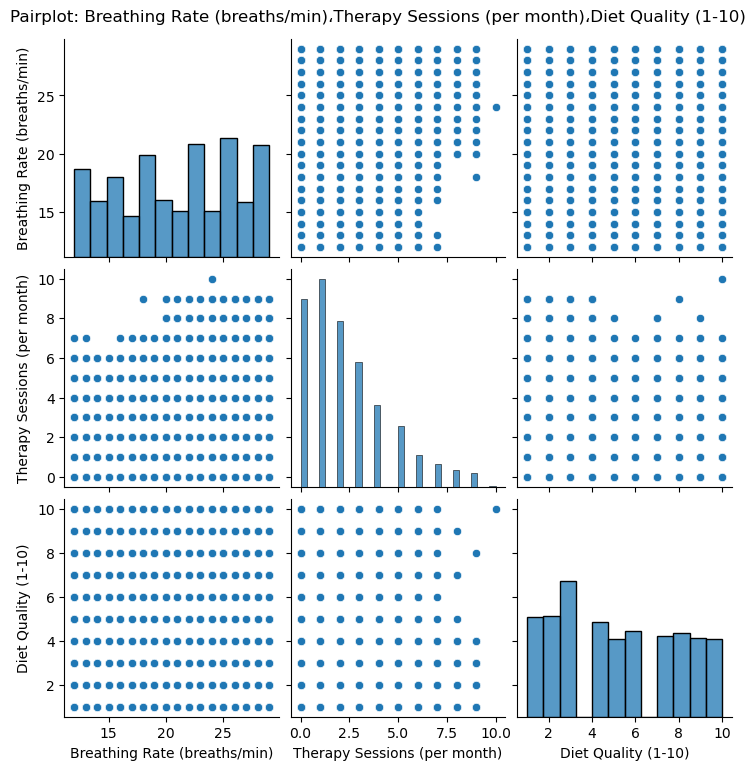

Breathing Rate (breaths/min) vs Therapy Sessions (per month) -> spearman corr = 0.0634918325481564
Breathing Rate (breaths/min) vs Diet Quality (1-10) -> spearman corr = -0.04810840624268902
Therapy Sessions (per month) vs Diet Quality (1-10) -> spearman corr = -0.10914964127650706


In [402]:
from itertools import combinations
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt
#pd.plotting.scatter_matrix(df_copy[numeric_cols], figsize=(30,30))
n=len(numeric_cols)
for i in range(0,n,3):
    cols=numeric_cols[i:i+3]
    z=len(cols) 
    if z<2:
        continue
    sns.pairplot(df_copy[cols].dropna())
    plt.suptitle("Pairplot: " + "،" .join(cols), y=1.02) 
    plt.show()
    for x1,x2 in combinations(cols, 2):
        corr,_=spearmanr(df_copy[x1],df_copy[x2])
        print(f"{x1} vs {x2} -> spearman corr = {corr}")

Categorical vs Numeric Analysis
Gender vs Anxiety Level (1-10) | ANOVA | p-value = 0.5017591971968325


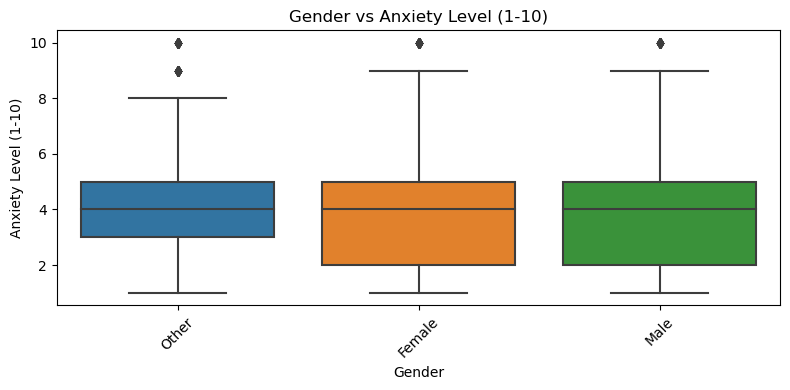

Smoking vs Anxiety Level (1-10) | Mann-Whitney U | p-value = 0.0032178575806465445


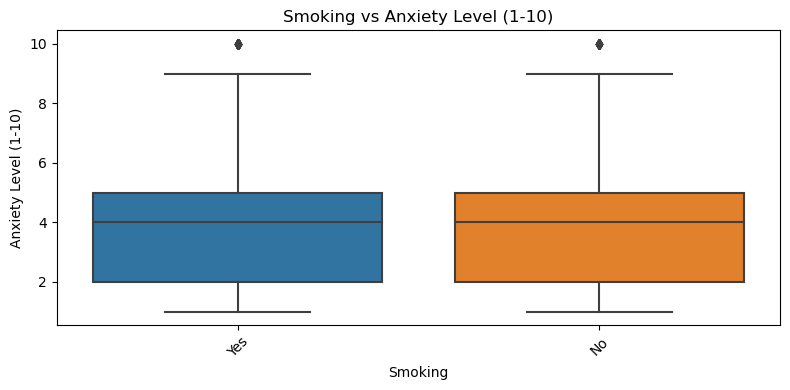

Family History of Anxiety vs Anxiety Level (1-10) | Mann-Whitney U | p-value = 9.328064281595166e-16


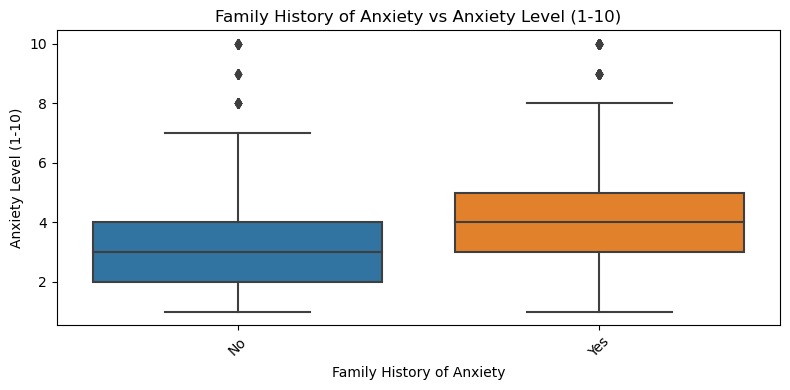

Therapy Sessions (per month) vs Anxiety Level (1-10) | ANOVA | p-value = 1.3951492036677955e-174


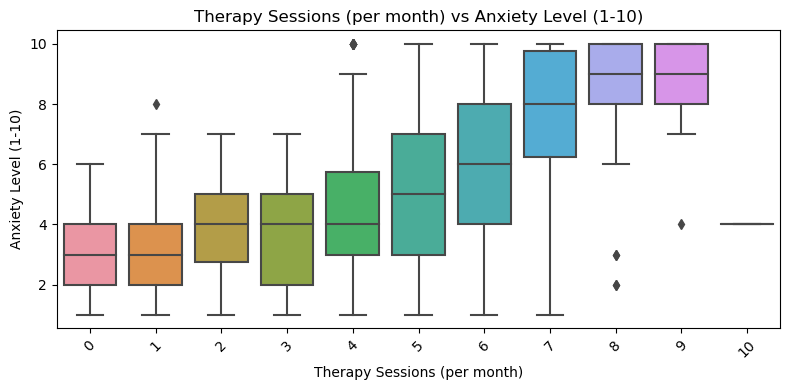

Recent Major Life Event vs Anxiety Level (1-10) | Mann-Whitney U | p-value = 0.2629439106115722


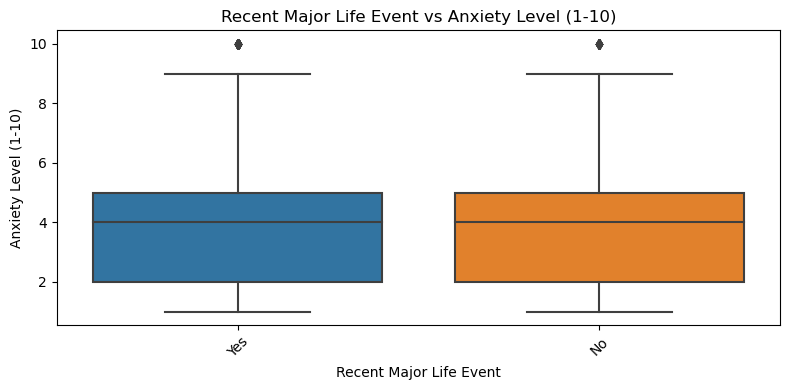

Sweating Level (1-5) vs Anxiety Level (1-10) | ANOVA | p-value = 2.982710167400864e-12


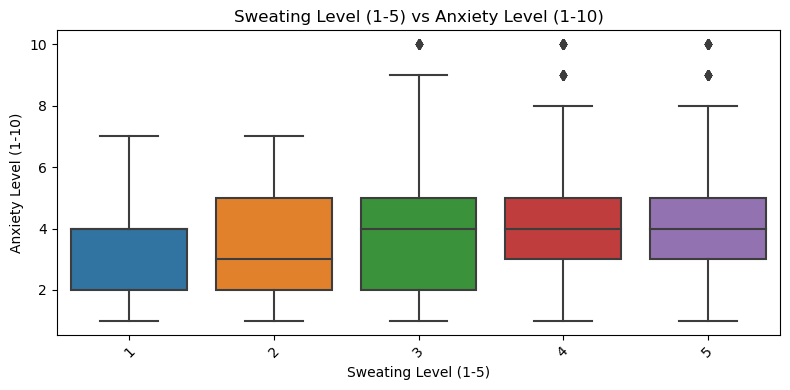

Occupation vs Anxiety Level (1-10) | ANOVA | p-value = 0.15033756514746527


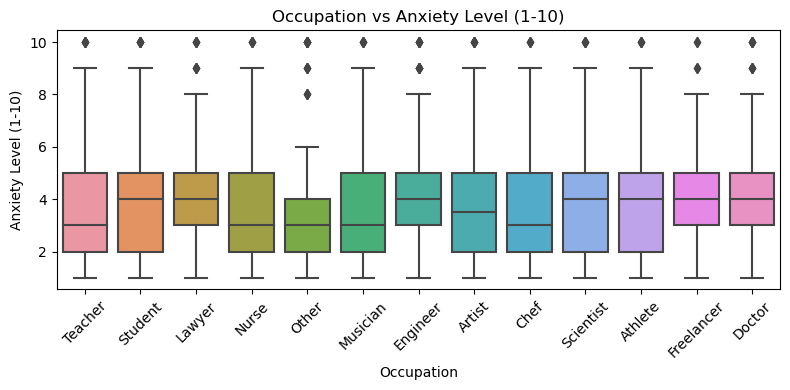

In [403]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, kruskal
from scipy.stats import f_oneway


categorical_cols = ["Gender","Smoking","Family History of Anxiety","Therapy Sessions (per month)",
                    "Recent Major Life Event","Sweating Level (1-5)","Occupation"]
target_num = "Anxiety Level (1-10)"
print("Categorical vs Numeric Analysis")
for cat in categorical_cols:    
    groups=[df_copy[df_copy[cat]==t][target_num]for t in df_copy[cat].unique()]
    groups=[g for g in groups if len(g)>5]
    if len(groups)<2:
        continue
    if len(groups)==2:
        stat,p=mannwhitneyu(groups[0],groups[1],alternative="two-sided")
        test="Mann-Whitney U"
    else:
        normal=min([len(g) for g in groups])>=30
        if normal:
            stat,p=f_oneway(*groups)
            test="ANOVA"
        else:
            stat,p=kruskal(*groups)
            test="Kruskal-Wallis"
    print(f"{cat} vs {target_num} | {test} | p-value = {p}")
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=cat,y=target_num,data=df_copy)
    plt.xticks(rotation=45)
    plt.title(f"{cat} vs {target_num}")
    plt.tight_layout()
    plt.show()


jensiat:Other  baze etminane afrade moztareb az 0.08124 ta 0.12928
jensiat:Female  baze etminane afrade moztareb az 0.07353 ta 0.11461
jensiat:Male  baze etminane afrade moztareb az 0.08843 ta 0.13804


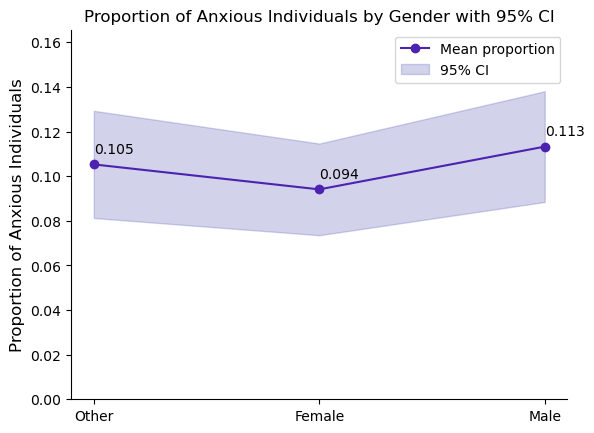

In [404]:
import numpy as np
from scipy.stats import norm


conf=0.95
z=norm.ppf((1+conf)/2)
gender_t=df_copy["Gender"].unique()

genders=[]
means=[]
ci_l=[]
ci_u=[]
for gender in gender_t :
    gtype=df_copy[df_copy["Gender"]==gender]["is_Anxious"]
    n=len(gtype)
    p_hat=gtype.mean()
    s=(p_hat*(1-p_hat))
    se=np.sqrt(s/n)
    l=p_hat-z*se
    u=p_hat+z*se
    
       
    genders.append(gender)
    means.append(p_hat)
    ci_l.append(l)
    ci_u.append(u)

    print(f"jensiat:{gender}  baze etminane afrade moztareb az {l:.5f} ta {u:.5f}")



    
means = np.array(means)
ci_lower = np.array(ci_l)
ci_upper = np.array(ci_u)

plt.plot(genders,means,marker='o',color="#4C22B0",label="Mean proportion")
plt.fill_between(genders,ci_l,ci_u,color="#4C52B0", alpha=0.25,label="95% CI")

for x1,x2 in zip(genders, means):
    plt.text(x1,x2+0.005,f"{x2:.3f}",fontsize=10)

plt.ylim(0,max(ci_u)*1.2)
plt.ylabel("Proportion of Anxious Individuals",fontsize=12)
plt.title("Proportion of Anxious Individuals by Gender with 95% CI",fontsize=12)
plt.legend()
sns.despine()
plt.show()


group: Yes ->  miangine ezterab baze: az 3.96332 ta 4.23028
group: No ->  miangine ezterab baze: az 3.58011 ta 3.83140


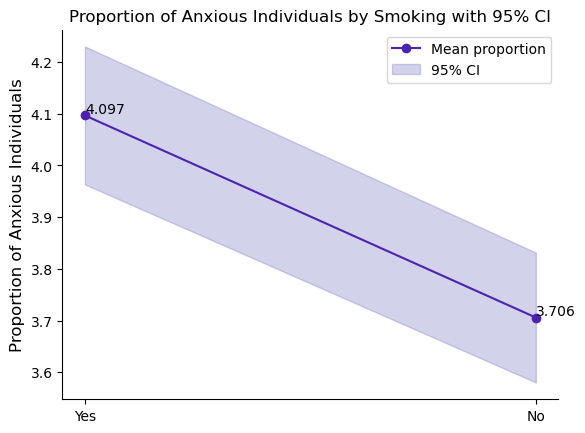

In [405]:
import numpy as np
from scipy.stats import t


target = "Anxiety Level (1-10)"
g=[]
means=[]
ci_l=[]
ci_u=[]
for group in df_copy["Smoking"].unique():
    val = df_copy[df_copy["Smoking"] == group][target].dropna()
    n=len(val)
    mu=val.mean()
    std=val.std()
    se=std/np.sqrt(n)
    t1=t.ppf((1+conf)/2,df=n-1)
    l=mu-t1*se
    u=mu+t1*se
    g.append(group)
    means.append(mu)
    ci_l.append(l)
    ci_u.append(u)

    print(f"group: {group} ->  miangine ezterab baze: az {l:.5f} ta {u:.5f}")

means = np.array(means)
ci_lower = np.array(ci_l)
ci_upper = np.array(ci_u)

plt.plot(g,means,marker='o',color="#4C22B0",label="Mean proportion")
plt.fill_between(g,ci_l,ci_u,color="#4C52B0",alpha=0.25,label="95% CI")

for x1,x2 in zip(g,means):
    plt.text(x1,x2+0.005,f"{x2:.3f}",fontsize=10)

plt.ylabel("Proportion of Anxious Individuals",fontsize=12)
plt.title("Proportion of Anxious Individuals by Smoking with 95% CI",fontsize=12)
plt.legend()
sns.despine()
plt.show()



In [406]:
import numpy as np  
import pandas as pd  
from plottable import Table
import matplotlib.pyplot as plt  
from matplotlib.colors import LinearSegmentedColormap
from pandas.plotting import table as mpl_table

from scipy import stats  
from scipy.stats import chi2_contingency, fisher_exact

import itertools
import warnings
warnings.filterwarnings('ignore')

teal_gold = [ '#298c8c', '#f1a226' ]


این تابع تعداد و درصد هر مقدار از ستون ها را محاسبه می کند و نتیجه را به صورت جدول فراوانی نمایش می دهد

In [407]:
def frequency_table(col):
    value_counts = col.value_counts()
    percentages = (value_counts/value_counts.sum()) * 100

    table = pd.DataFrame({
        'Proportion' : value_counts,
        '%' : percentages.round(2)
    })

    return table

تابع جدول توافقی بین یک متغیر کتگوریکال و متغیر تارگت رارسم می کند. و مقدار و درصد را نمایش می دهد

In [408]:
def contingency_table(data, col, target):

    cross_table = pd.crosstab(data[col], data[target])
    percentages = (cross_table.div(cross_table.sum(axis=1), axis=0) * 100).round(2)

    return cross_table, percentages

نمایش بصری با استفاده از بارچارت ها

In [409]:
def bar_chart(data, col, chart_type):
    counts = pd.crosstab(data[col], data['is_Anxious'])
    counts = counts.sort_index()

    if chart_type == "Frequency Bar Chart":
        data_sorted = data[col].value_counts().sort_index()
        sns.barplot(x=data_sorted.index, y=data_sorted.values, palette=['#298c8c'])
        plt.ylabel("Count")

    elif chart_type == "Grouped Bar Chart":
        counts.plot(kind="bar", ax=plt.gca(), color=teal_gold)
        plt.ylabel("Count")
        plt.legend(title="is_Anxious")

    elif chart_type == "Normalized Stacked Bar Chart":
        norm_counts = counts.div(counts.sum(axis=1), axis=0)
        norm_counts.plot(kind="bar", stacked=True, ax=plt.gca(), color=teal_gold)
        plt.ylabel("Proportion")
        plt.legend(title="is_Anxious")
        
    plt.xlabel(col)
    plt.xticks(rotation=90)
    sns.despine()



قرار دادن نمودار ها در کنار یکدیگر

In [410]:
def all_bar_plots(data, col):
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    bar_chart(data, col, "Frequency Bar Chart")
    plt.title("Frequency Bar Chart", fontsize=10)

    plt.subplot(1, 3, 2)
    bar_chart(data, col, "Grouped Bar Chart")
    plt.title("Grouped Bar Chart", fontsize=10)

    plt.subplot(1, 3, 3)
    bar_chart(data, col, "Normalized Stacked Bar Chart")
    plt.title("Normalized Stacked Bar Chart", fontsize=10)

    plt.tight_layout()
    plt.show()

این تابع سه جدول را در کنار هم نمایش می دهد -هم به صورت تعداد و هم درصد

In [411]:
def plot_tables(data, col, target):

    freq = frequency_table(data[col]).sort_index()
    contingency_t, percentage = contingency_table(data, col, target)

    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(col, fontsize=20, fontweight="bold")

    tables = [freq, contingency_t.T,  percentage.T]
    titles = ["Category Frequency","Count by Category and Target","Percentage by Category and Target"]

    
    for ax, df, title in zip(axes, tables, titles):
        fmt = "d" if (df.applymap(lambda x: isinstance(x, (int, np.integer))).all().all()) else ".2f"

        sns.heatmap(df,
                    annot=True, fmt=fmt,
                    cmap=["white"],  
                    cbar=False,
                    linewidths=0.5,
                    linecolor="lightgray",
                    annot_kws={"size": 16},
                    ax=ax)
        ax.set_title(title, fontsize=14, pad=12)
        ax.set_xlabel("")
        ax.set_ylabel("")

    plt.tight_layout()
    plt.show()

نمایش جدول های توصیفی و بارچارت ها

In [412]:
def categorical_vs_target(data , col , target):
    plot_tables(data , col , target)
    all_bar_plots(data, col)

بررسی وجود ارتباط معنادار بین متغیرهای دسته ای و متغیر تارگت

In [413]:
def compare_categorical_with_binary(data, feature_col, target_col, alpha=0.1):

    contingency = pd.crosstab(data[feature_col], data[target_col])
    chi2, p_global, _, _ = stats.chi2_contingency(contingency)

    print(f"\n{feature_col}")
    print(f"[Global Test] p-value = {p_global:.4f}")

    if p_global < alpha:
        print(f"H0 rejected at {alpha*100:.0f}% significance level.")
        print("Significant pairwise differences (p < α):")

        categories = sorted(data[feature_col].dropna().unique())
        sig_pairs = []

        for cat1, cat2 in itertools.combinations(categories, 2):
            subset = data[data[feature_col].isin([cat1, cat2])]
            table = pd.crosstab(subset[feature_col], subset[target_col])

            if table.shape == (2, 2):
                _, p_pair, _, _ = stats.chi2_contingency(table)
                if p_pair < alpha:
                    sig_pairs.append((cat1, cat2, p_pair))

        if sig_pairs:
            for cat1, cat2, p in sig_pairs:
                print(f"  {cat1} vs {cat2} → p = {p:.4f}")
        else:
            print("No pairwise differences found.")
    else:
        print(f"H0 NOT rejected at {alpha*100:.0f}% level. No significant difference.")

In [414]:
contingency_table(df_copy, 'Age_group', target)

(Anxiety Level (1-10)  1    2    3    4   5   6   7   8   9   10
 Age_group                                                      
 18-30                 72  105  105  115  84  32   2  27  24  22
 31-40                 45   73   96   96  72  32   7  29  20  23
 41-50                 37   69  105   95  60  32   8  11  12  15
 51-64                 52   82  124  118  87  32   9   1   0   0,
 Anxiety Level (1-10)     1      2      3      4      5     6     7     8   \
 Age_group                                                                   
 18-30                 12.24  17.86  17.86  19.56  14.29  5.44  0.34  4.59   
 31-40                  9.13  14.81  19.47  19.47  14.60  6.49  1.42  5.88   
 41-50                  8.33  15.54  23.65  21.40  13.51  7.21  1.80  2.48   
 51-64                 10.30  16.24  24.55  23.37  17.23  6.34  1.78  0.20   
 
 Anxiety Level (1-10)    9     10  
 Age_group                         
 18-30                 4.08  3.74  
 31-40                 4.06  4.

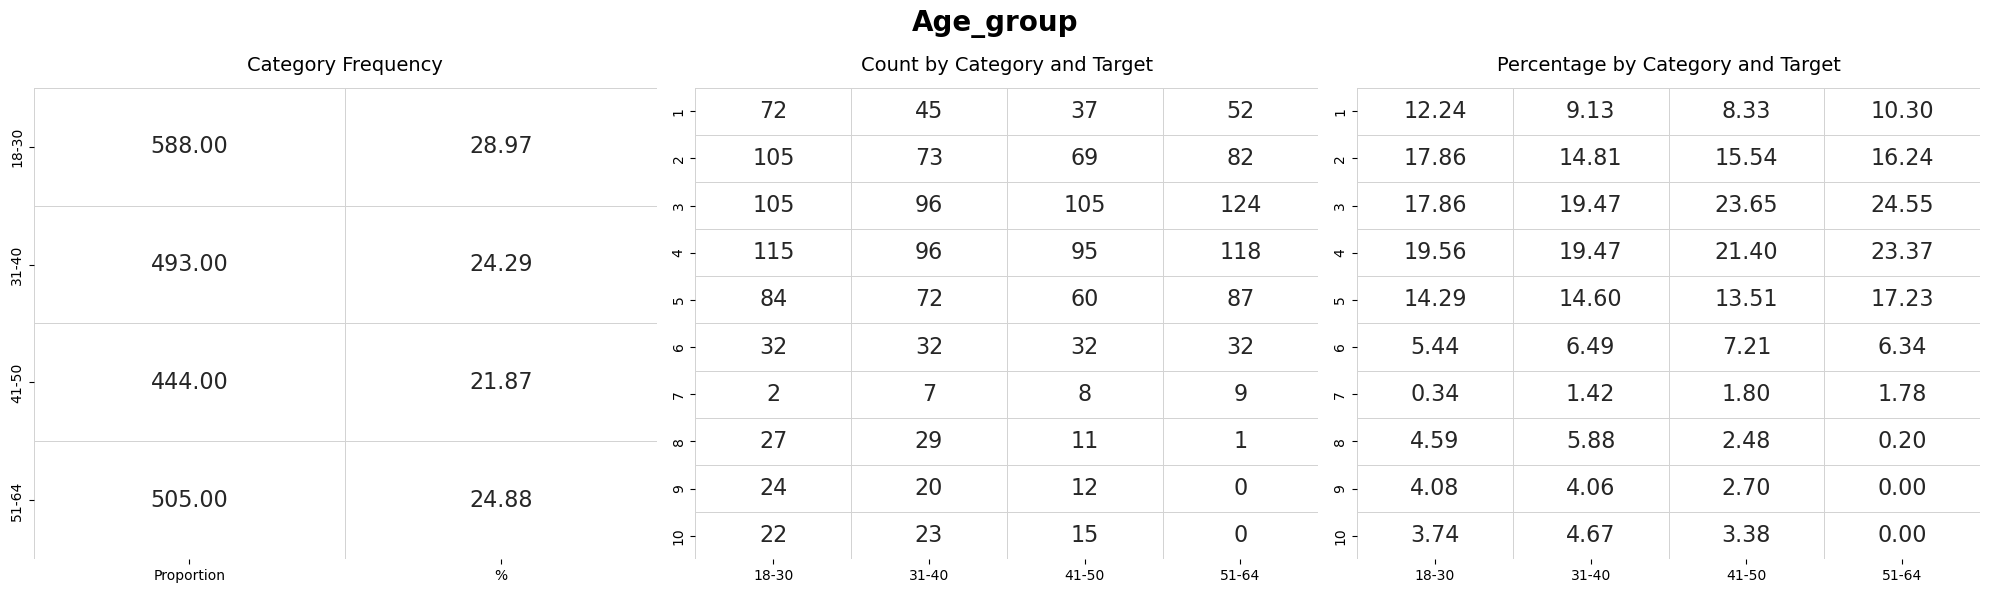

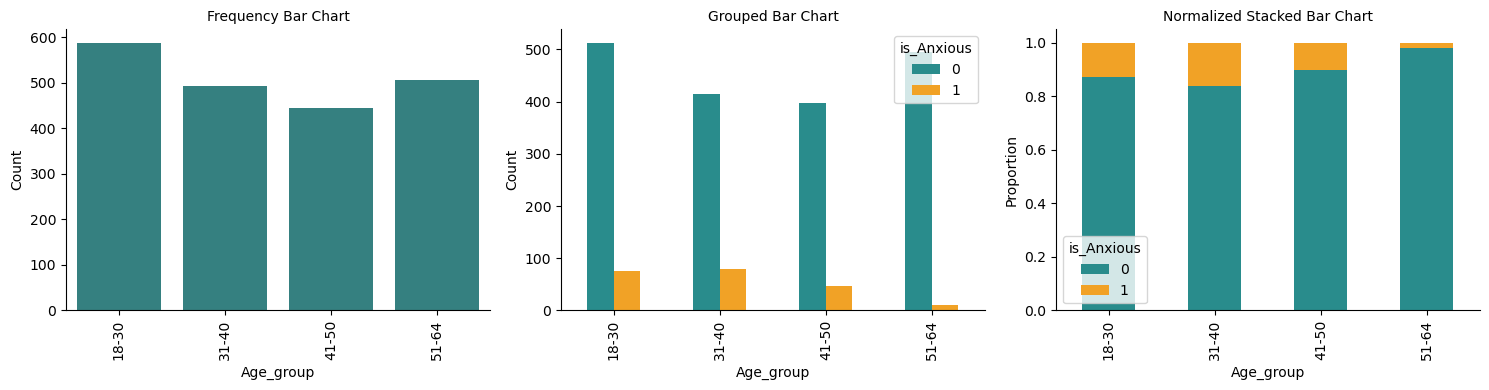

In [415]:
categorical_vs_target(df_copy, 'Age_group', target)

In [416]:
compare_categorical_with_binary(df_copy, 'Age_group', target, alpha=0.05)


Age_group
[Global Test] p-value = 0.0000
H0 rejected at 5% significance level.
Significant pairwise differences (p < α):
No pairwise differences found.


In [417]:
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table(df_copy, 'Age_group', target))

print(f"chi_square = {chi2_stat:.4f}")
print(f"p_value = {p_value:.4f}")

if p_value < 0.05:
    print(f"Age group has significant association with being anxious.\n")
else:
    print(f"Age group has no significant association with being anxious.\n")

chi_square = 118.9371
p_value = 0.0001
Age group has significant association with being anxious.



In [418]:
contingency_table(df_copy, 'Gender', target)

(Anxiety Level (1-10)  1    2    3    4    5   6   7   8   9   10
 Gender                                                          
 Female                76  136  172  160  111  48   8  22  18  25
 Male                  69  107  120  127   87  46   7  29  19  16
 Other                 61   86  138  137  105  34  11  17  19  19,
 Anxiety Level (1-10)     1      2      3      4      5     6     7     8   \
 Gender                                                                      
 Female                 9.79  17.53  22.16  20.62  14.30  6.19  1.03  2.84   
 Male                  11.00  17.07  19.14  20.26  13.88  7.34  1.12  4.63   
 Other                  9.73  13.72  22.01  21.85  16.75  5.42  1.75  2.71   
 
 Anxiety Level (1-10)    9     10  
 Gender                            
 Female                2.32  3.22  
 Male                  3.03  2.55  
 Other                 3.03  3.03  )

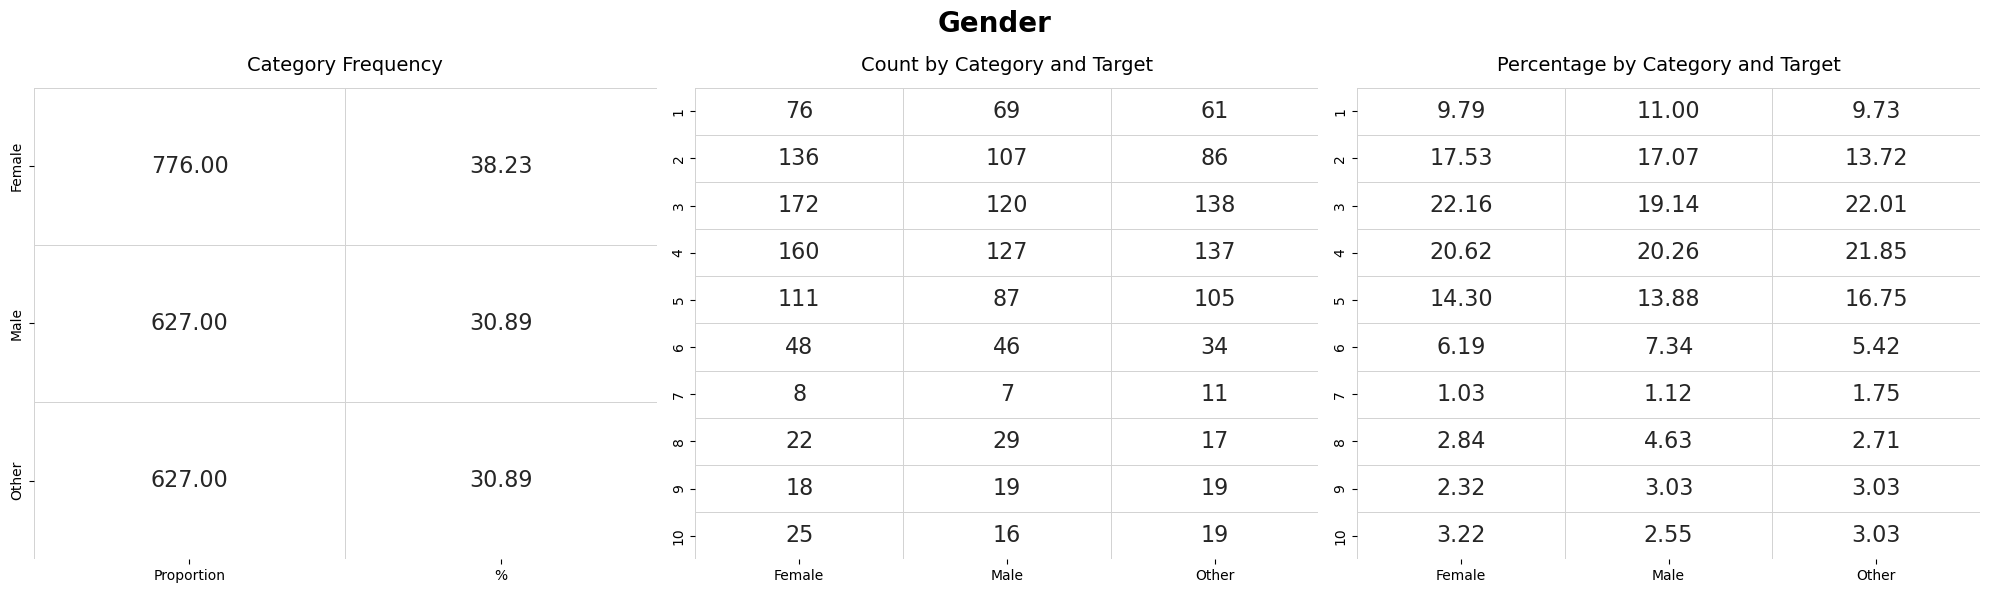

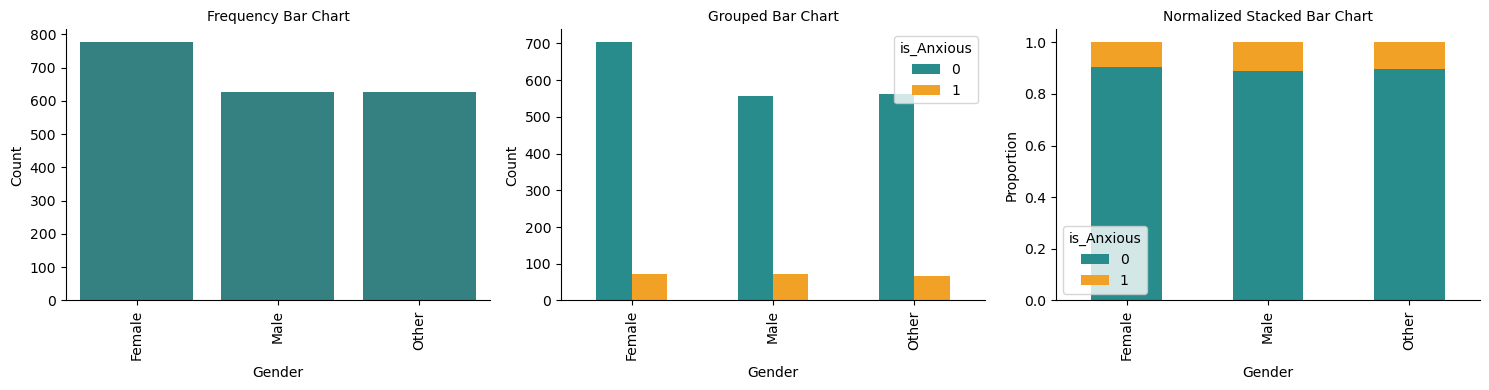

In [419]:
categorical_vs_target(df_copy , categorical_cols[0] , target)

In [420]:
compare_categorical_with_binary(df_copy, categorical_cols[0] , target, alpha=0.05)


Gender
[Global Test] p-value = 0.4721
H0 NOT rejected at 5% level. No significant difference.


Gender has no significant effect on being anxious. (p > 0.05)

In [421]:
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table(df_copy, 'Gender', target))

print(f"chi_square = {chi2_stat:.4f}")
print(f"p_value = {p_value:.4f}")

if p_value < 0.05:
    print(f"Gender has significant association with being anxious.\n")
else:
    print(f"Gender has no significant association with being anxious.\n")

chi_square = 23.1596
p_value = 0.9986
Gender has no significant association with being anxious.



In [422]:
contingency_table(df_copy, 'Occupation', target)

(Anxiety Level (1-10)  1   2   3   4   5   6   7   8   9   10
 Occupation                                                  
 Artist                16  28  42  34  22  11   1   6   7   5
 Athlete               14  25  30  29  29   4   1   6   5   4
 Chef                  14  30  30  23  24  10   3   6   3   3
 Doctor                 9  24  33  35  29  15   3   4   4   5
 Engineer               9  14  30  35  23  12   3   3   6   6
 Freelancer            14  16  30  24  32  11   1   2   2   2
 Lawyer                 7  29  32  35  30  16   3   7   4   4
 Musician              19  33  33  36  21   4   2   7   4   4
 Nurse                 26  20  38  32  23  10   0   6   3   4
 Other                 16  25  43  29  14   7   0   3   4   8
 Scientist             18  26  26  36  13  16   6   5   5   4
 Student               23  36  31  44  26   6   0   5   5   6
 Teacher               21  23  32  32  17   6   3   8   4   5,
 Anxiety Level (1-10)     1      2      3      4      5      6     7 

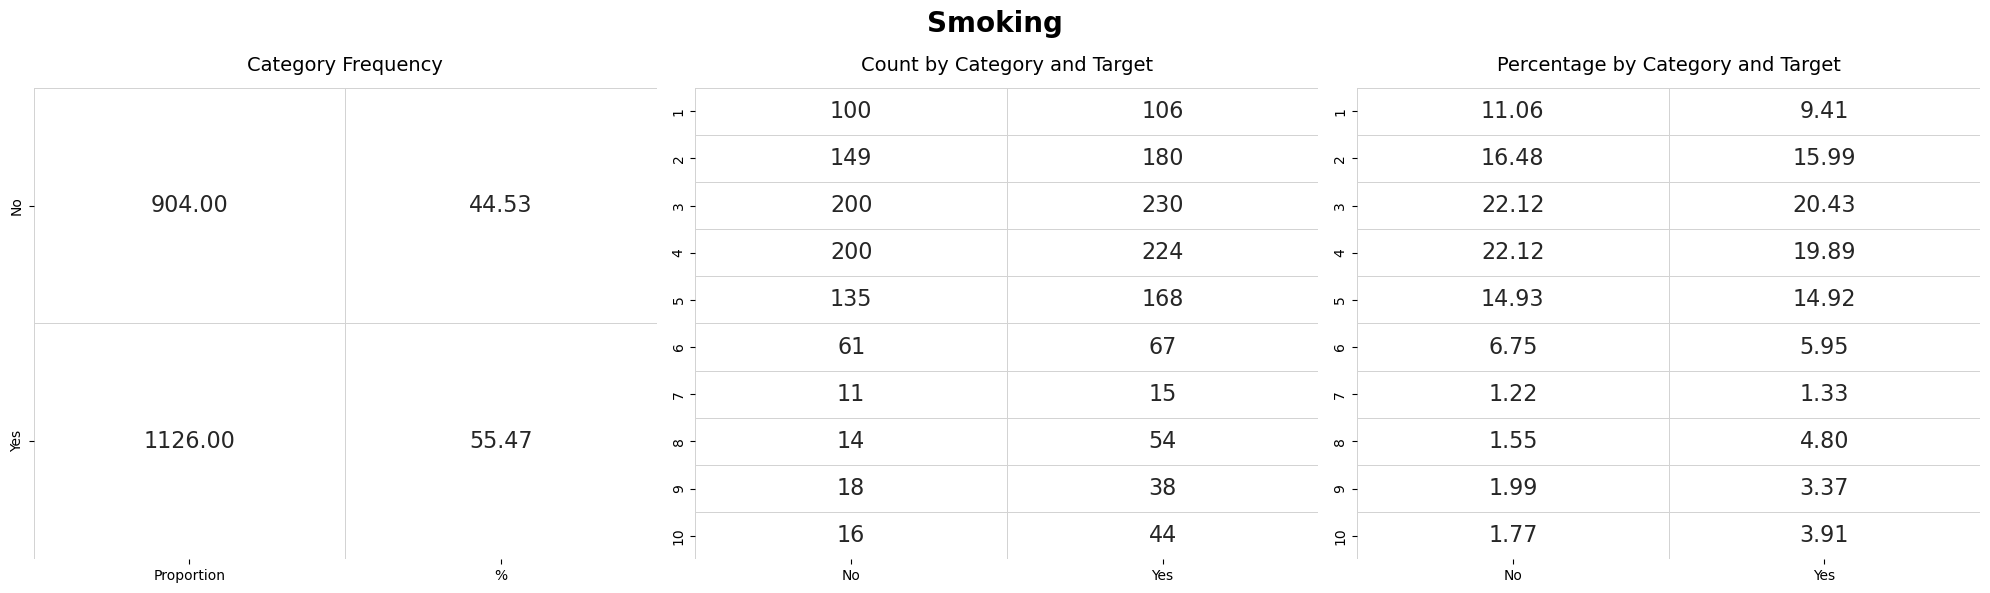

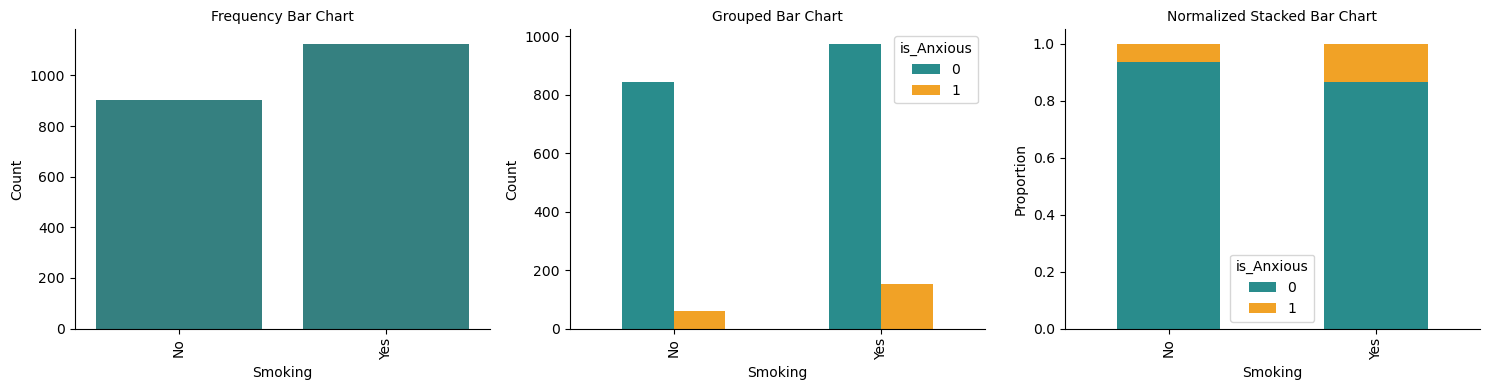

In [423]:
categorical_vs_target(df_copy, categorical_cols[1], target)

In [424]:
compare_categorical_with_binary(df_copy, categorical_cols[1], target, alpha=0.05)


Smoking
[Global Test] p-value = 0.0003
H0 rejected at 5% significance level.
Significant pairwise differences (p < α):
No pairwise differences found.


Occupation has no significant effect on being anxious. (p > 0.05)

In [425]:
chi2_stat, p_value,dof, expected = stats.chi2_contingency(contingency_table(df_copy, 'Occupation', target))

print(f"chi_square = {chi2_stat:.4f}")
print(f"p_value = {p_value:.4f}")

if p_value < 0.05:
    print(f"Occupation has significant association with being anxious.\n")
else:
    print(f"Occupation has no significant association with being anxious.\n")

chi_square = 213.7455
p_value = 0.8587
Occupation has no significant association with being anxious.



In [426]:
contingency_table(df_copy, 'Smoking', target)

(Anxiety Level (1-10)   1    2    3    4    5   6   7   8   9   10
 Smoking                                                          
 No                    100  149  200  200  135  61  11  14  18  16
 Yes                   106  180  230  224  168  67  15  54  38  44,
 Anxiety Level (1-10)     1      2      3      4      5     6     7     8   \
 Smoking                                                                     
 No                    11.06  16.48  22.12  22.12  14.93  6.75  1.22  1.55   
 Yes                    9.41  15.99  20.43  19.89  14.92  5.95  1.33  4.80   
 
 Anxiety Level (1-10)    9     10  
 Smoking                           
 No                    1.99  1.77  
 Yes                   3.37  3.91  )

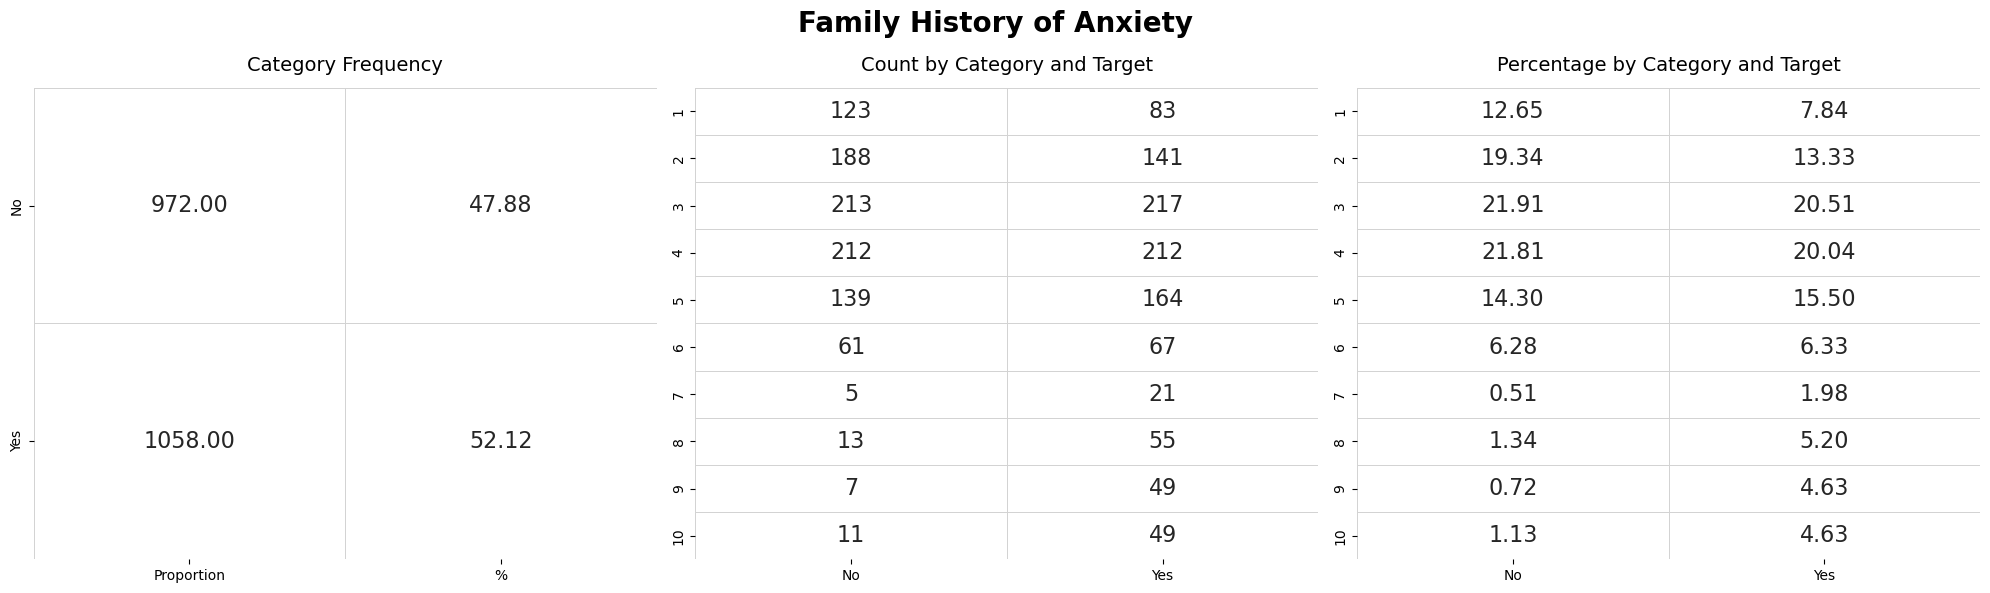

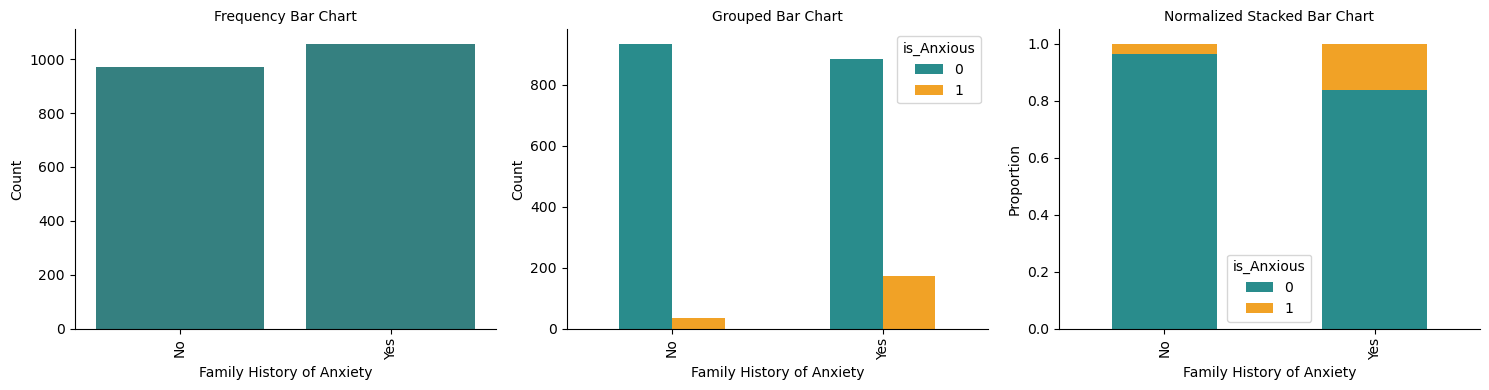

In [427]:
categorical_vs_target(df_copy, categorical_cols[2], target)

In [428]:
compare_categorical_with_binary(df_copy, categorical_cols[2], target, alpha=0.05)


Family History of Anxiety
[Global Test] p-value = 0.0000
H0 rejected at 5% significance level.
Significant pairwise differences (p < α):
No pairwise differences found.


Smoking is significantly associated with anxiety. (p < 0.05)

In [429]:
chi2_stat, p_value,dof, expected = stats.chi2_contingency(contingency_table(df_copy, 'Smoking', target))

print(f"chi_square = {chi2_stat:.4f}")
print(f"p_value = {p_value:.4f}")

if p_value < 0.05:
    print(f"Smoking has significant association with being anxious.\n")
else:
    print(f"Smoking has no significant association with being anxious.\n")

chi_square = 36.3318
p_value = 0.1343
Smoking has no significant association with being anxious.



In [430]:
contingency_table(df_copy, 'Family History of Anxiety', target)

(Anxiety Level (1-10)        1    2    3    4    5   6   7   8   9   10
 Family History of Anxiety                                             
 No                         123  188  213  212  139  61   5  13   7  11
 Yes                         83  141  217  212  164  67  21  55  49  49,
 Anxiety Level (1-10)          1      2      3      4     5     6     7     8   \
 Family History of Anxiety                                                       
 No                         12.65  19.34  21.91  21.81  14.3  6.28  0.51  1.34   
 Yes                         7.84  13.33  20.51  20.04  15.5  6.33  1.98  5.20   
 
 Anxiety Level (1-10)         9     10  
 Family History of Anxiety              
 No                         0.72  1.13  
 Yes                        4.63  4.63  )

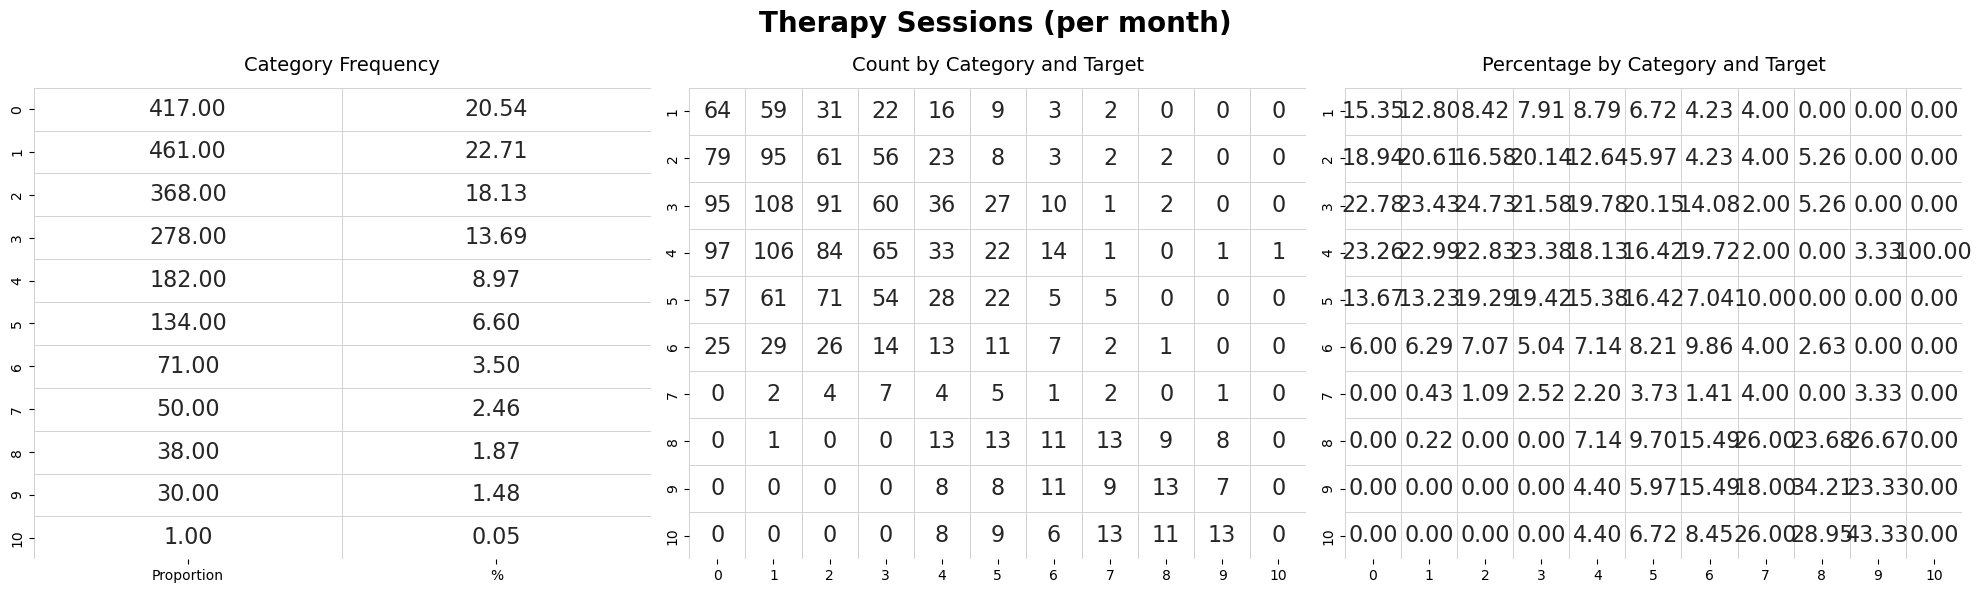

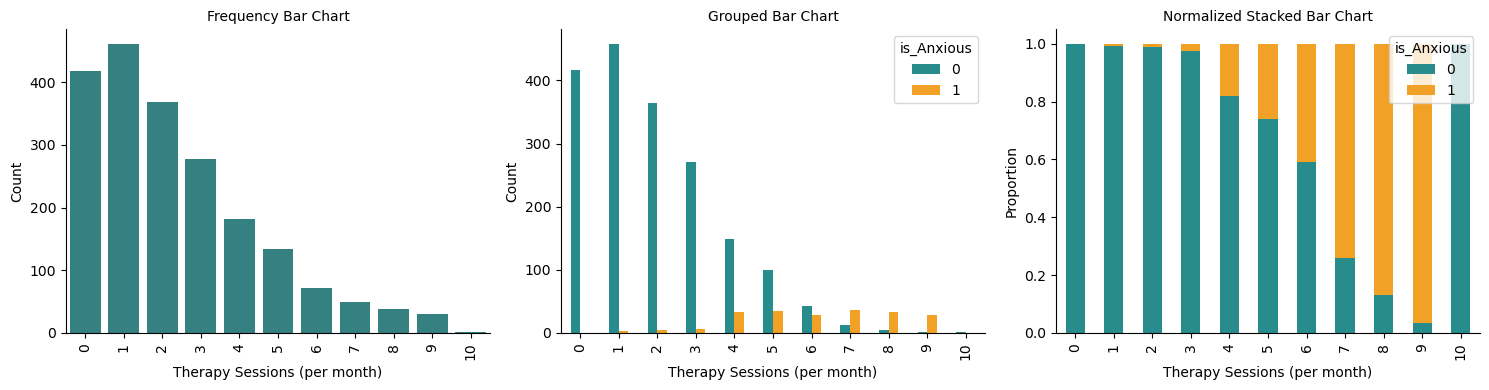

In [431]:
categorical_vs_target(df_copy, categorical_cols[3], target)

In [432]:
compare_categorical_with_binary(df_copy, categorical_cols[3], target, alpha=0.05)


Therapy Sessions (per month)
[Global Test] p-value = 0.0000
H0 rejected at 5% significance level.
Significant pairwise differences (p < α):
No pairwise differences found.


Having family history of anxiety is significantly associated with anxiety. (p < 0.05)

In [433]:
chi2_stat, p_value,dof, expected = stats.chi2_contingency(contingency_table(df_copy, 'Family History of Anxiety', target))

print(f"chi_square = {chi2_stat:.4f}")
print(f"p_value = {p_value:.4f}")

if p_value < 0.05:
    print(f"Family History of Anxiety has significant association with being anxious.\n")
else:
    print(f"Family History of Anxiety has no significant association with being anxious.\n")

chi_square = 115.6518
p_value = 0.0000
Family History of Anxiety has significant association with being anxious.



In [434]:
contingency_table(df_copy, 'Stress_category', target)

(Anxiety Level (1-10)   1    2    3    4    5   6   7   8   9   10
 Stress_category                                                  
 Low                   185  222  196   91   14   1   0   0   0   0
 Medium                 17   99  181  231  146  40   6  27  15  16
 High                    4    8   53  102  143  87  20  41  41  44,
 Anxiety Level (1-10)     1      2      3      4      5      6     7     8   \
 Stress_category                                                              
 Low                   26.09  31.31  27.64  12.83   1.97   0.14  0.00  0.00   
 Medium                 2.19  12.72  23.26  29.69  18.77   5.14  0.77  3.47   
 High                   0.74   1.47   9.76  18.78  26.34  16.02  3.68  7.55   
 
 Anxiety Level (1-10)    9     10  
 Stress_category                   
 Low                   0.00  0.00  
 Medium                1.93  2.06  
 High                  7.55  8.10  )

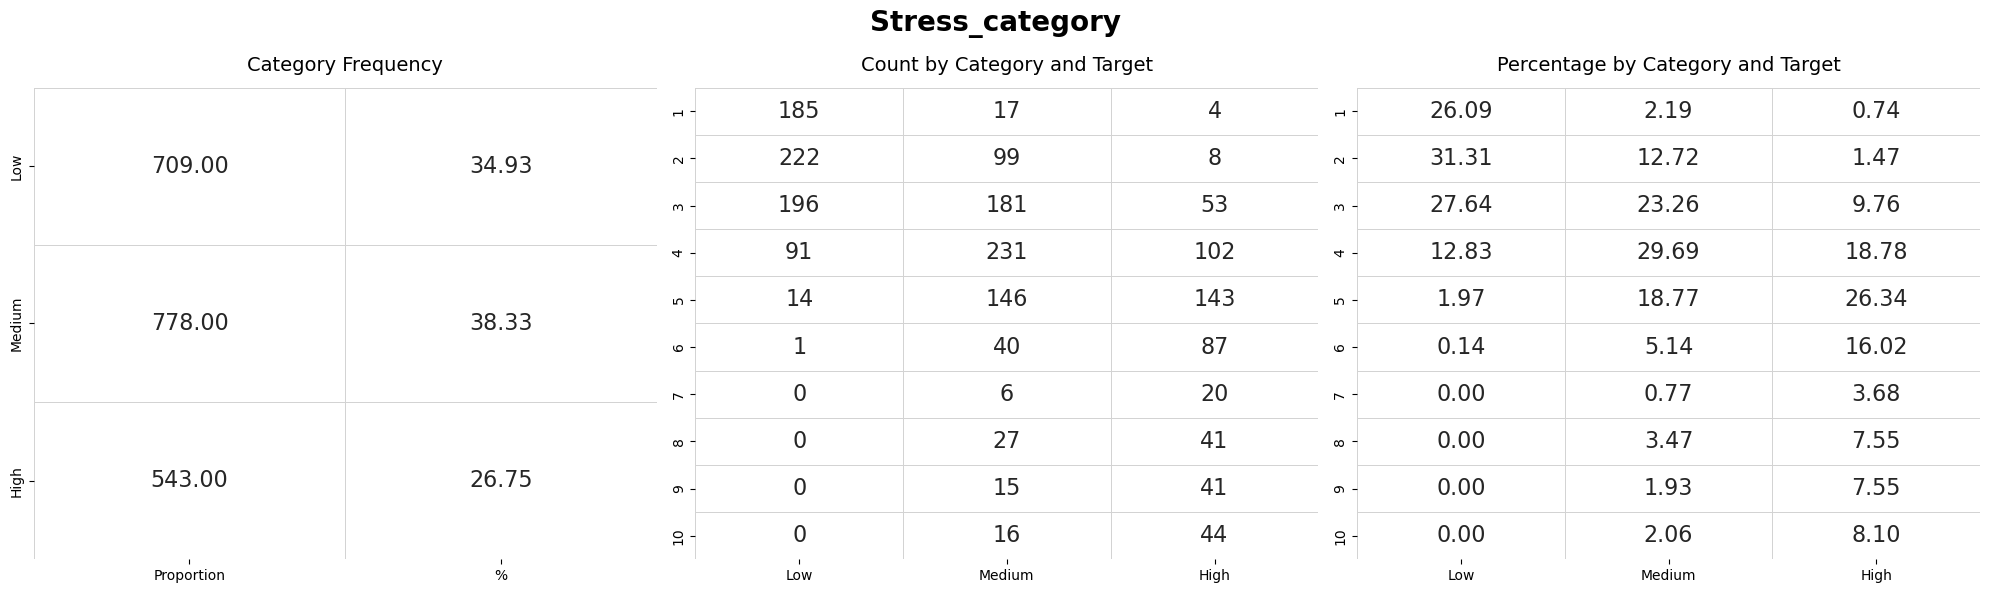

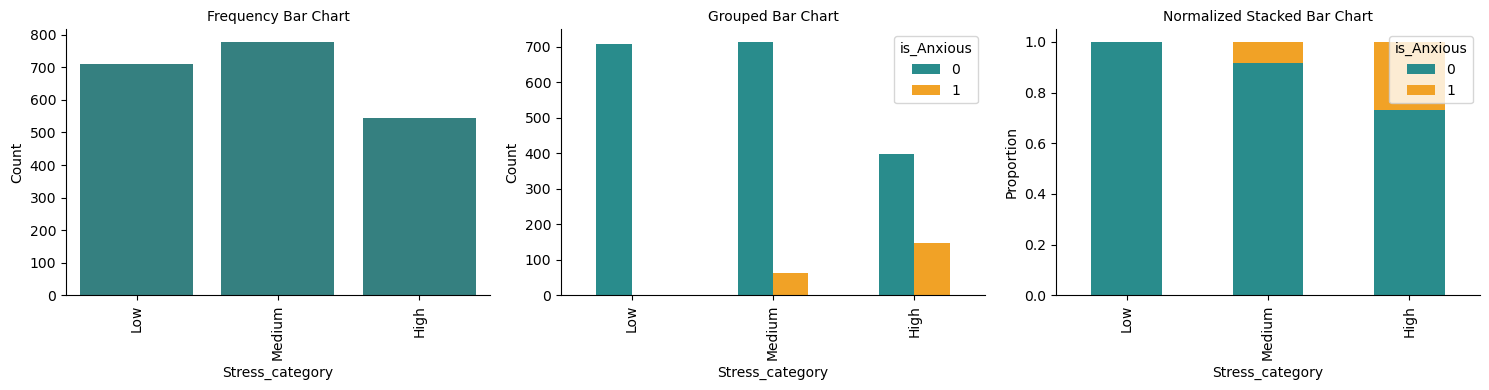

In [435]:
categorical_vs_target(df_copy, 'Stress_category', target)

In [436]:
compare_categorical_with_binary(df_copy, 'Stress_category', target, alpha=0.05)


Stress_category
[Global Test] p-value = 0.0000
H0 rejected at 5% significance level.
Significant pairwise differences (p < α):
No pairwise differences found.


Stress level is significantly associated with anxiety. (p < 0.05)

In [437]:
chi2_stat, p_value,dof, expected = stats.chi2_contingency(contingency_table(df_copy, 'Stress_category', target))

print(f"chi_square = {chi2_stat:.4f}")
print(f"p_value = {p_value:.4f}")

if p_value < 0.05:
    print(f"Stress_category has significant association with being anxious.\n")
else:
    print(f"Stress_category has no significant association with being anxious.\n")

chi_square = 1208.9204
p_value = 0.0000
Stress_category has significant association with being anxious.



In [438]:
contingency_table(df_copy, 'Dizziness', target)

(Anxiety Level (1-10)   1    2    3    4    5   6   7   8   9   10
 Dizziness                                                        
 No                    101  164  217  210  161  63  10  13  23  19
 Yes                   105  165  213  214  142  65  16  55  33  41,
 Anxiety Level (1-10)     1      2      3      4      5     6     7     8   \
 Dizziness                                                                   
 No                    10.30  16.72  22.12  21.41  16.41  6.42  1.02  1.33   
 Yes                   10.01  15.73  20.31  20.40  13.54  6.20  1.53  5.24   
 
 Anxiety Level (1-10)    9     10  
 Dizziness                         
 No                    2.34  1.94  
 Yes                   3.15  3.91  )

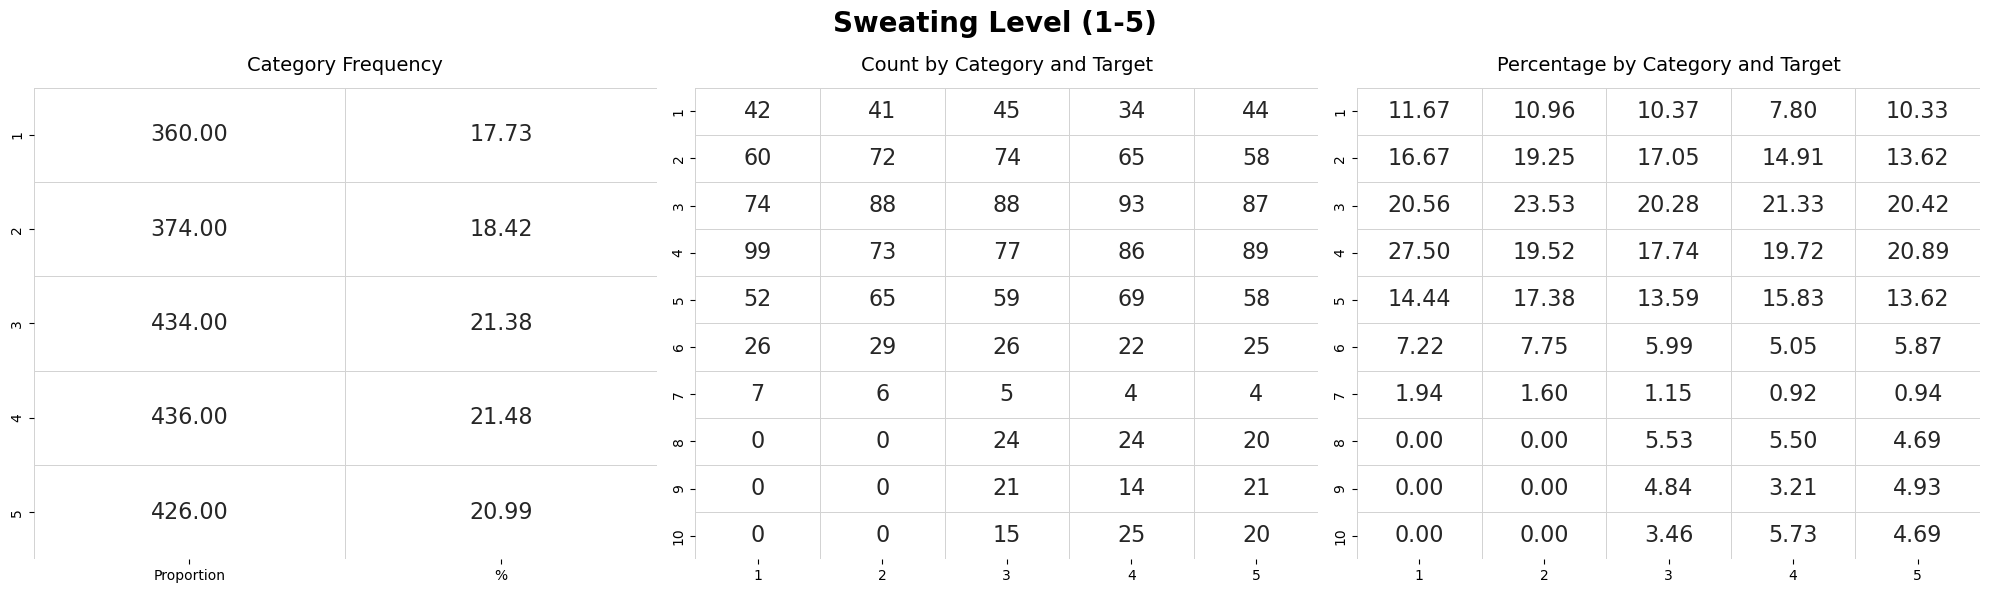

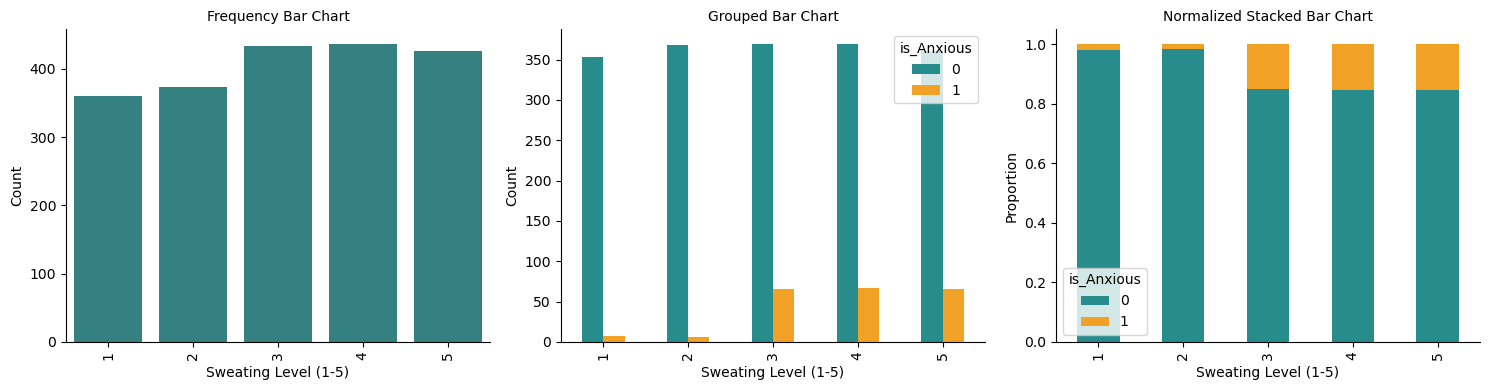

In [439]:
categorical_vs_target(df_copy, categorical_cols[5], target)

In [440]:
compare_categorical_with_binary(df_copy, categorical_cols[5], target, alpha=0.05)


Sweating Level (1-5)
[Global Test] p-value = 0.0000
H0 rejected at 5% significance level.
Significant pairwise differences (p < α):
No pairwise differences found.


Dizziness is significantly associated with being anxious. (p < 0.05)

In [441]:
chi2_stat, p_value,dof, expected = stats.chi2_contingency(contingency_table(df_copy, 'Dizziness', target))

print(f"chi_square = {chi2_stat:.4f}")
print(f"p_value = {p_value:.4f}")

if p_value < 0.05:
    print(f"Dizziness has significant association with being anxious.\n")
else:
    print(f"Dizziness has no significant association with being anxious.\n")

chi_square = 40.1562
p_value = 0.0640
Dizziness has no significant association with being anxious.



In [442]:
contingency_table(df_copy, 'Medication', target)

(Anxiety Level (1-10)   1    2    3    4    5   6   7   8   9   10
 Medication                                                       
 No                    108  158  216  205  121  64  15  30  19  21
 Yes                    98  171  214  219  182  64  11  38  37  39,
 Anxiety Level (1-10)     1      2      3      4      5     6     7     8   \
 Medication                                                                  
 No                    11.29  16.51  22.57  21.42  12.64  6.69  1.57  3.13   
 Yes                    9.13  15.94  19.94  20.41  16.96  5.96  1.03  3.54   
 
 Anxiety Level (1-10)    9     10  
 Medication                        
 No                    1.99  2.19  
 Yes                   3.45  3.63  )

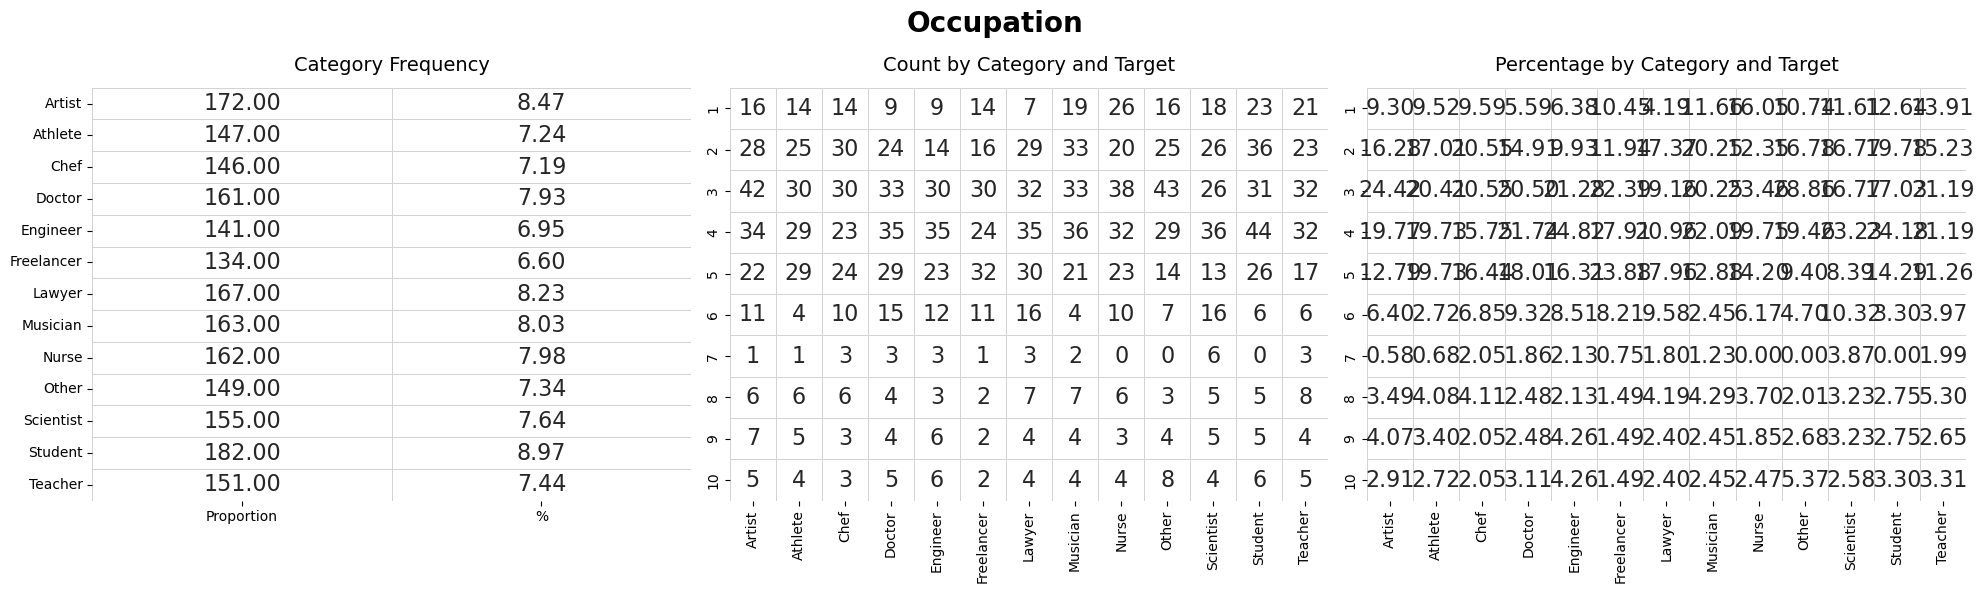

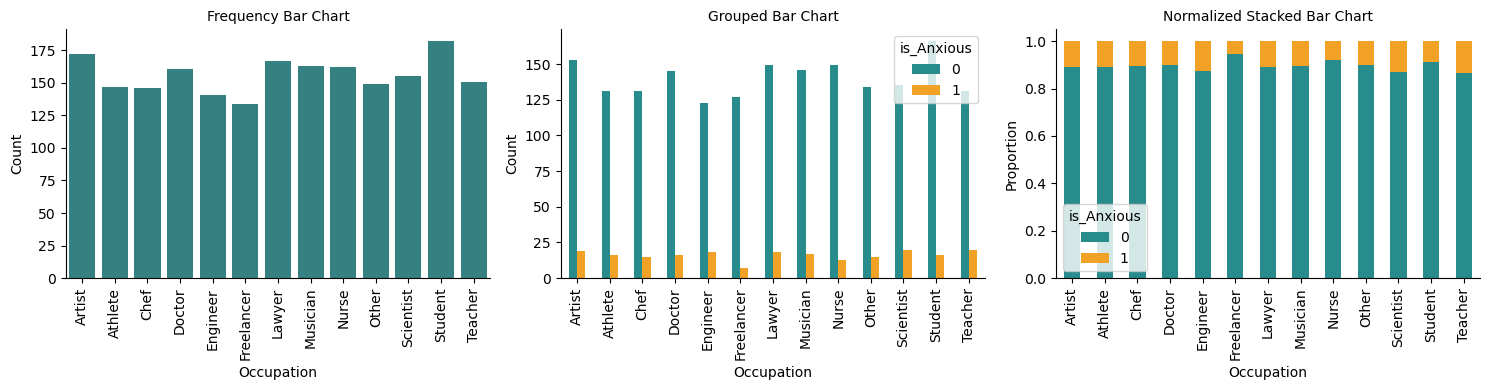

In [443]:
categorical_vs_target(df_copy, categorical_cols[6], target)

In [444]:
compare_categorical_with_binary(df_copy, categorical_cols[6], target, alpha=0.05)


Occupation
[Global Test] p-value = 0.1101
H0 NOT rejected at 5% level. No significant difference.


Medication is significantly associated with being anxious. (p < 0.05)

In [445]:
chi2_stat, p_value,dof, expected = stats.chi2_contingency(contingency_table(df_copy, 'Medication', target))

print(f"chi_square = {chi2_stat:.4f}")
print(f"p_value = {p_value:.4f}")

if p_value < 0.05:
    print(f"Medication has significant association with being anxious.\n")
else:
    print(f"Medication has no significant association with being anxious.\n")

chi_square = 22.5230
p_value = 0.7565
Medication has no significant association with being anxious.



In [446]:
contingency_table(df_copy, 'Recent Major Life Event', target)

(Anxiety Level (1-10)      1    2    3    4    5   6   7   8   9   10
 Recent Major Life Event                                             
 No                        97  156  224  215  156  66  15  25  22  14
 Yes                      109  173  206  209  147  62  11  43  34  46,
 Anxiety Level (1-10)        1      2      3      4      5     6     7     8   \
 Recent Major Life Event                                                        
 No                        9.80  15.76  22.63  21.72  15.76  6.67  1.52  2.53   
 Yes                      10.48  16.63  19.81  20.10  14.13  5.96  1.06  4.13   
 
 Anxiety Level (1-10)       9     10  
 Recent Major Life Event              
 No                       2.22  1.41  
 Yes                      3.27  4.42  )

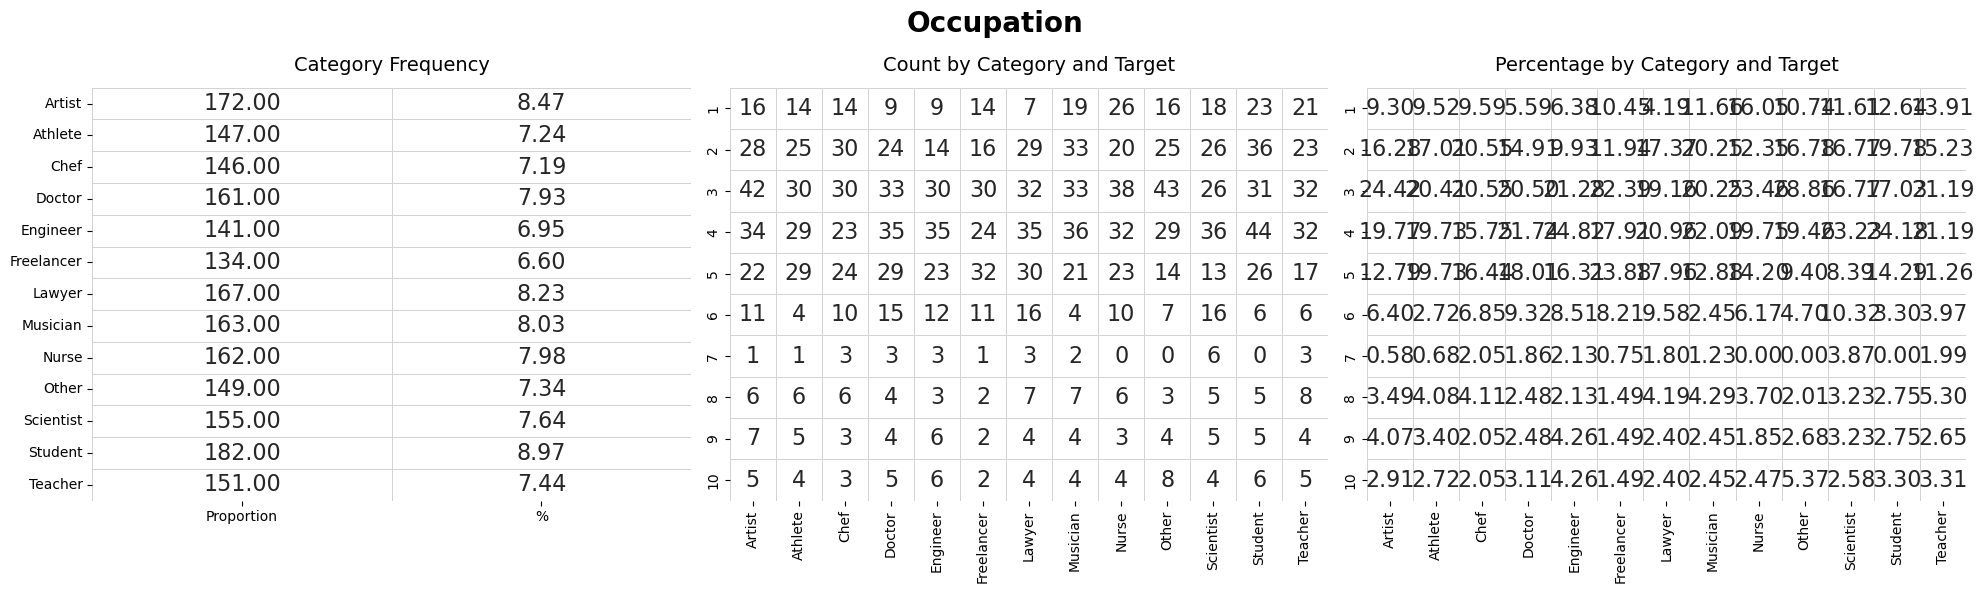

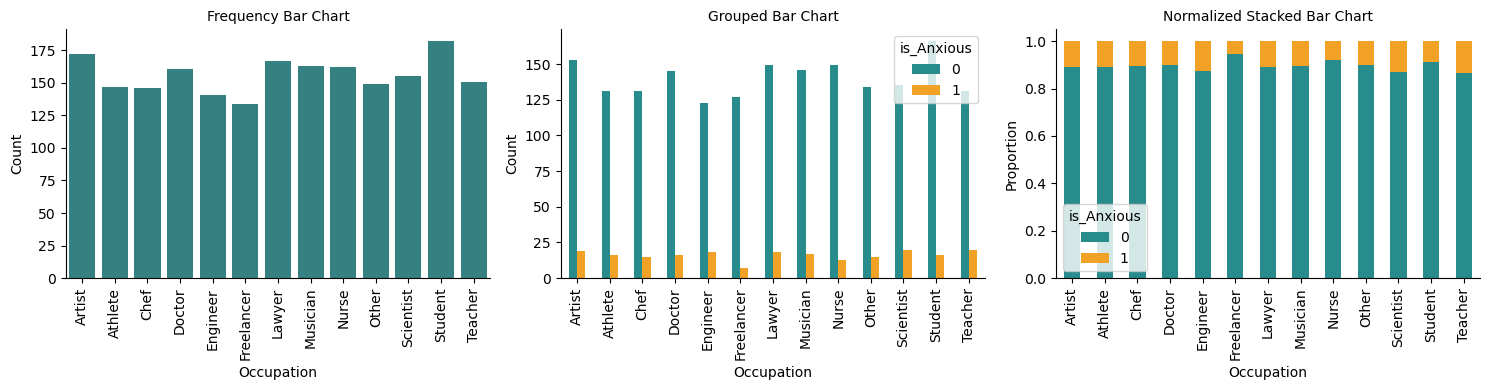

In [447]:
categorical_vs_target(df_copy, categorical_cols[-1], target)

In [448]:
compare_categorical_with_binary(df_copy, categorical_cols[-1], target, alpha=0.05)


Occupation
[Global Test] p-value = 0.1101
H0 NOT rejected at 5% level. No significant difference.


Recent Major Life Event is significantly associated with being anxious. (p < 0.05)

In [449]:
chi2_stat, p_value,dof, expected = stats.chi2_contingency(contingency_table(df_copy, 'Recent Major Life Event', target))

print(f"chi_square = {chi2_stat:.4f}")
print(f"p_value = {p_value:.4f}")

if p_value < 0.05:
    print(f"Recent Major Life Event has significant association with being anxious.\n")
else:
    print(f"Recent Major Life Event has no significant association with being anxious.\n")

chi_square = 29.3724
p_value = 0.3938
Recent Major Life Event has no significant association with being anxious.



In [450]:
contingency_table(df_copy, 'Sweating Level (1-5)', target)

(Anxiety Level (1-10)  1   2   3   4   5   6   7   8   9   10
 Sweating Level (1-5)                                        
 1                     42  60  74  99  52  26   7   0   0   0
 2                     41  72  88  73  65  29   6   0   0   0
 3                     45  74  88  77  59  26   5  24  21  15
 4                     34  65  93  86  69  22   4  24  14  25
 5                     44  58  87  89  58  25   4  20  21  20,
 Anxiety Level (1-10)     1      2      3      4      5     6     7     8   \
 Sweating Level (1-5)                                                        
 1                     11.67  16.67  20.56  27.50  14.44  7.22  1.94  0.00   
 2                     10.96  19.25  23.53  19.52  17.38  7.75  1.60  0.00   
 3                     10.37  17.05  20.28  17.74  13.59  5.99  1.15  5.53   
 4                      7.80  14.91  21.33  19.72  15.83  5.05  0.92  5.50   
 5                     10.33  13.62  20.42  20.89  13.62  5.87  0.94  4.69   
 
 Anxiety Level (1

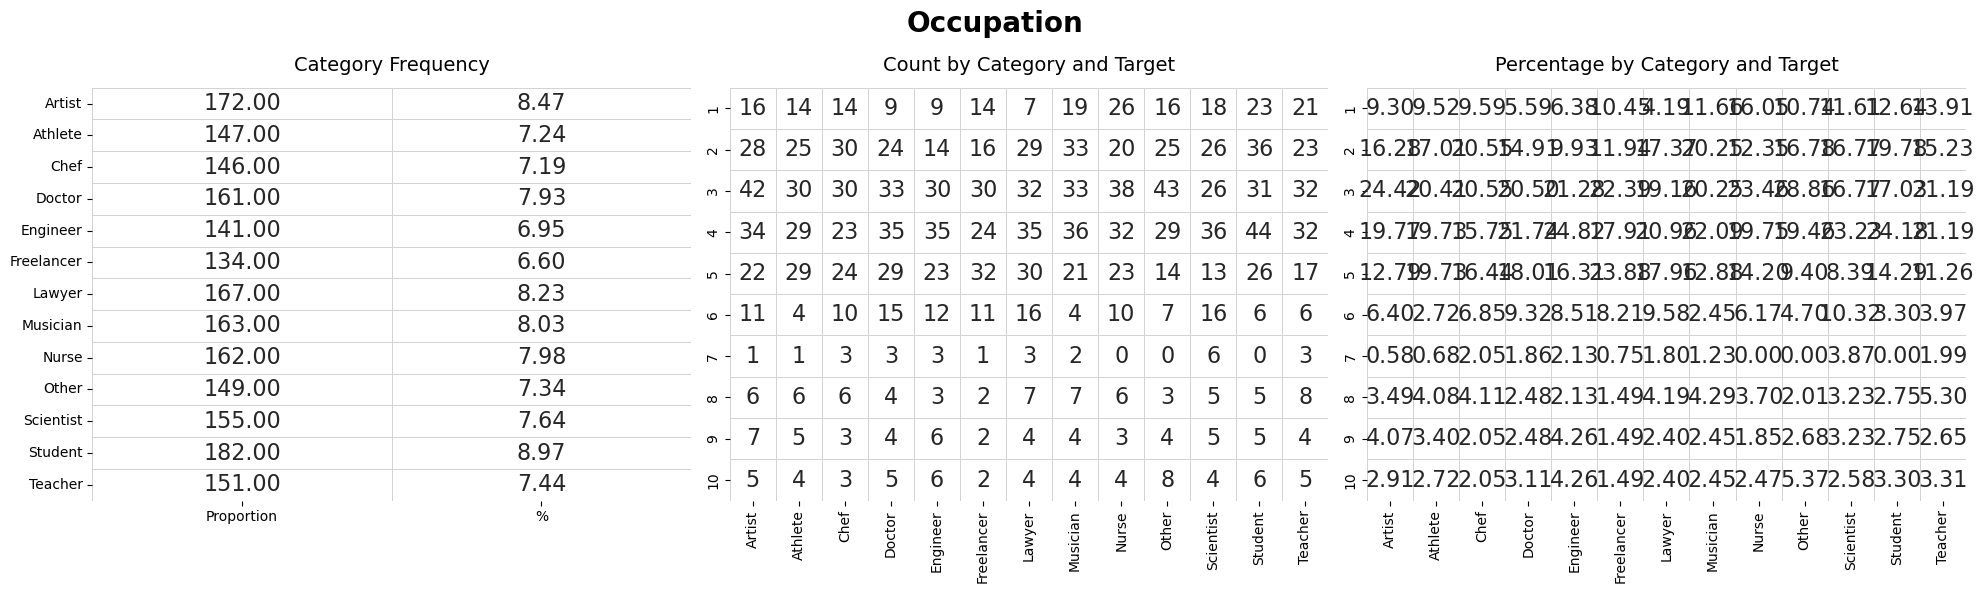

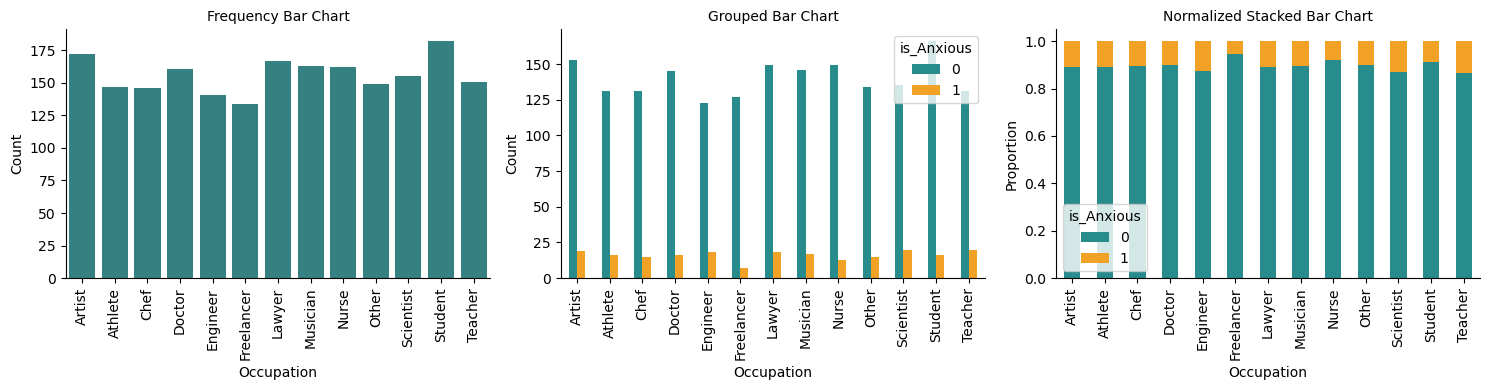

In [451]:
categorical_vs_target(df_copy, categorical_cols[-1], target)

In [452]:
compare_categorical_with_binary(df_copy, categorical_cols[-1], target, alpha=0.05)


Occupation
[Global Test] p-value = 0.1101
H0 NOT rejected at 5% level. No significant difference.


Sweating Level is significantly associated with being anxious. (p < 0.05)

In [453]:
chi2_stat, p_value,dof, expected = stats.chi2_contingency(contingency_table(df_copy, 'Sweating Level (1-5)', target))

print(f"chi_square = {chi2_stat:.4f}")
print(f"p_value = {p_value:.4f}")

if p_value < 0.05:
    print(f"Sweating Level  has significant association with being anxious.\n")
else:
    print(f"Sweating Level  has no significant association with being anxious.\n")

chi_square = 179.5541
p_value = 0.0000
Sweating Level  has significant association with being anxious.



In [454]:
contingency_table(df_copy, 'Diet Quality (1-10)', target)

(Anxiety Level (1-10)  1   2   3   4   5   6   7   8   9   10
 Diet Quality (1-10)                                         
 1                     23  31  39  43  25  13   3  16  14  14
 2                     17  31  51  37  30  13   3  13  17  11
 3                     28  51  54  61  36  16   3  22  11  20
 4                     16  28  37  44  32   7   0  17  14  15
 5                     17  30  39  38  32  13   3   0   0   0
 6                     21  36  37  46  29  18   3   0   0   0
 7                     22  33  38  44  28  10   4   0   0   0
 8                     21  30  44  41  33  14   2   0   0   0
 9                     23  31  45  34  27  14   1   0   0   0
 10                    18  28  46  36  31  10   4   0   0   0,
 Anxiety Level (1-10)     1      2      3      4      5     6     7     8   \
 Diet Quality (1-10)                                                         
 1                     10.41  14.03  17.65  19.46  11.31  5.88  1.36  7.24   
 2                   

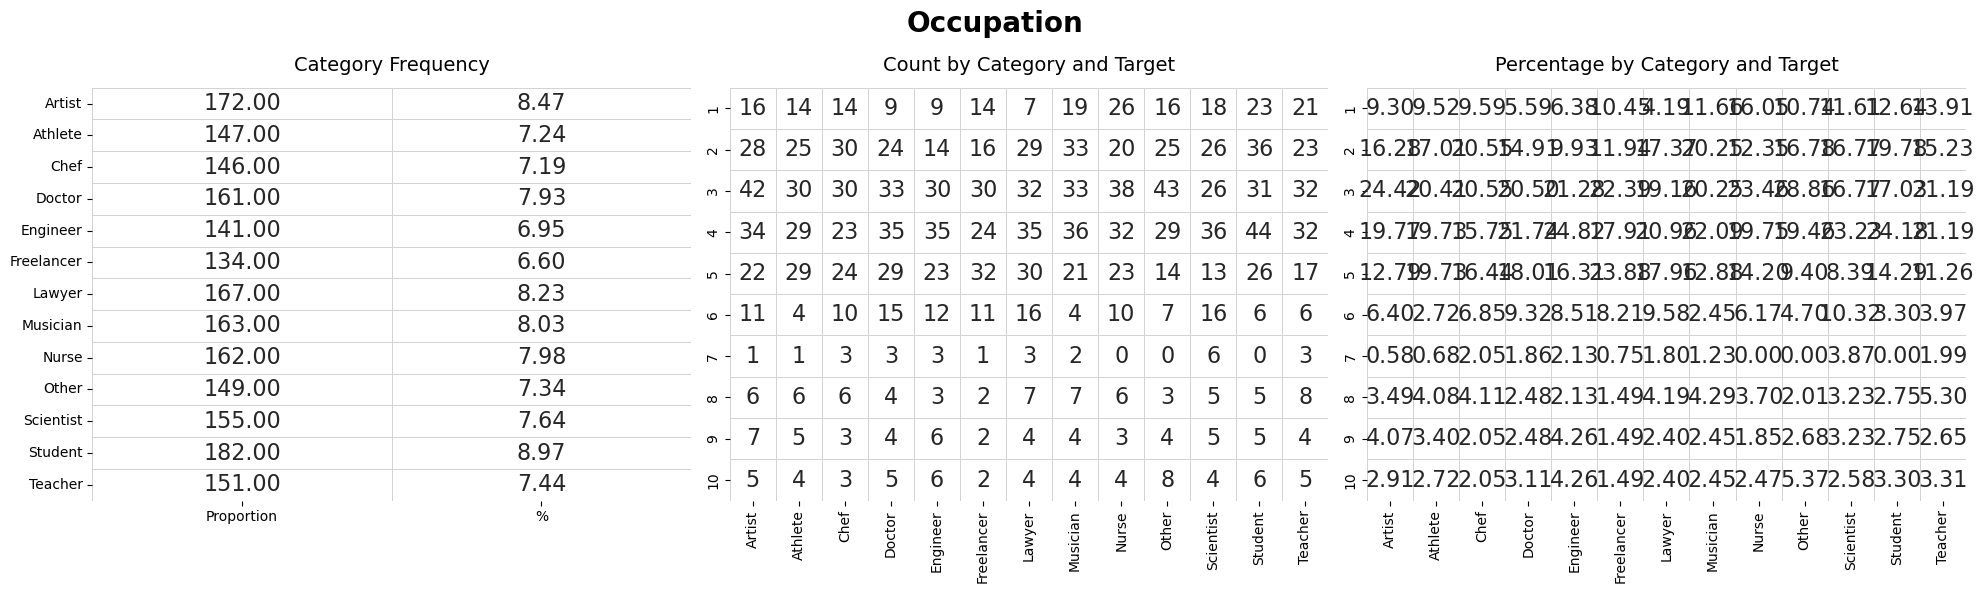

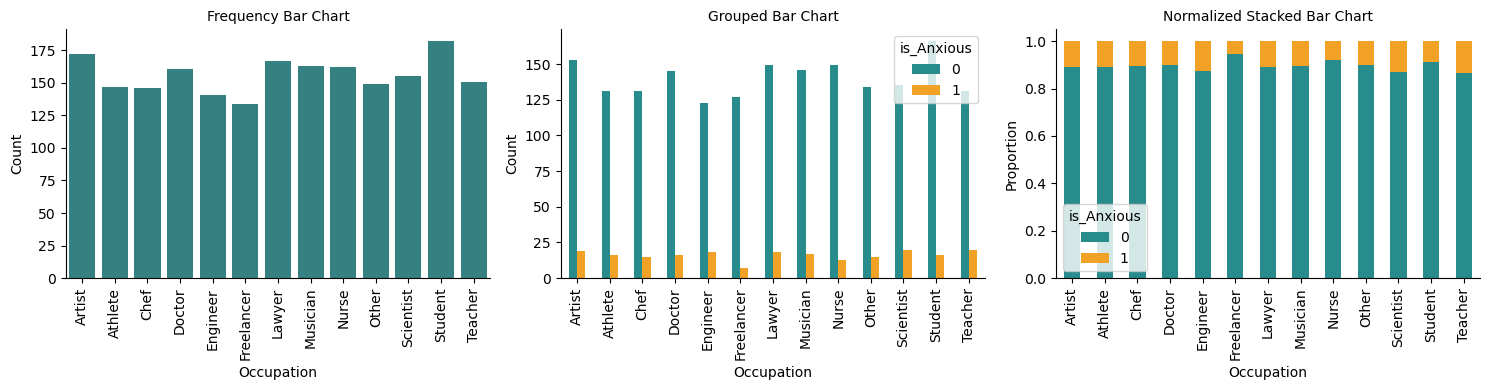

In [455]:
categorical_vs_target(df_copy, categorical_cols[-1], target)

In [456]:
compare_categorical_with_binary(df_copy, categorical_cols[-1], target, alpha=0.05)


Occupation
[Global Test] p-value = 0.1101
H0 NOT rejected at 5% level. No significant difference.


Diet quality is significantly associated with being anxious. (p < 0.05)

In [457]:
chi2_stat, p_value,dof, expected = stats.chi2_contingency(contingency_table(df_copy, 'Diet Quality (1-10)', target))

print(f"chi_square = {chi2_stat:.4f}")
print(f"p_value = {p_value:.4f}")

if p_value < 0.05:
    print(f"Diet Quality (1-10)  has significant association with being anxious.\n")
else:
    print(f"Diet Quality (1-10)  has no significant association with being anxious.\n")

chi_square = 434.4213
p_value = 0.0000
Diet Quality (1-10)  has significant association with being anxious.



In [458]:
contingency_table(df_copy, 'Sleep_category', target)

(Anxiety Level (1-10)   1    2    3    4    5   6   7   8   9   10
 Sleep_category                                                   
 Low (<4h)               0    1    3    3    1   0   0  13  11  12
 Normal (4-7h)         100  169  251  267  190  92  21  55  45  48
 High (>7h)            106  159  176  154  112  36   5   0   0   0,
 Anxiety Level (1-10)     1      2      3      4      5     6     7      8   \
 Sleep_category                                                               
 Low (<4h)              0.00   2.27   6.82   6.82   2.27  0.00  0.00  29.55   
 Normal (4-7h)          8.08  13.65  20.27  21.57  15.35  7.43  1.70   4.44   
 High (>7h)            14.17  21.26  23.53  20.59  14.97  4.81  0.67   0.00   
 
 Anxiety Level (1-10)     9      10  
 Sleep_category                      
 Low (<4h)             25.00  27.27  
 Normal (4-7h)          3.63   3.88  
 High (>7h)             0.00   0.00  )

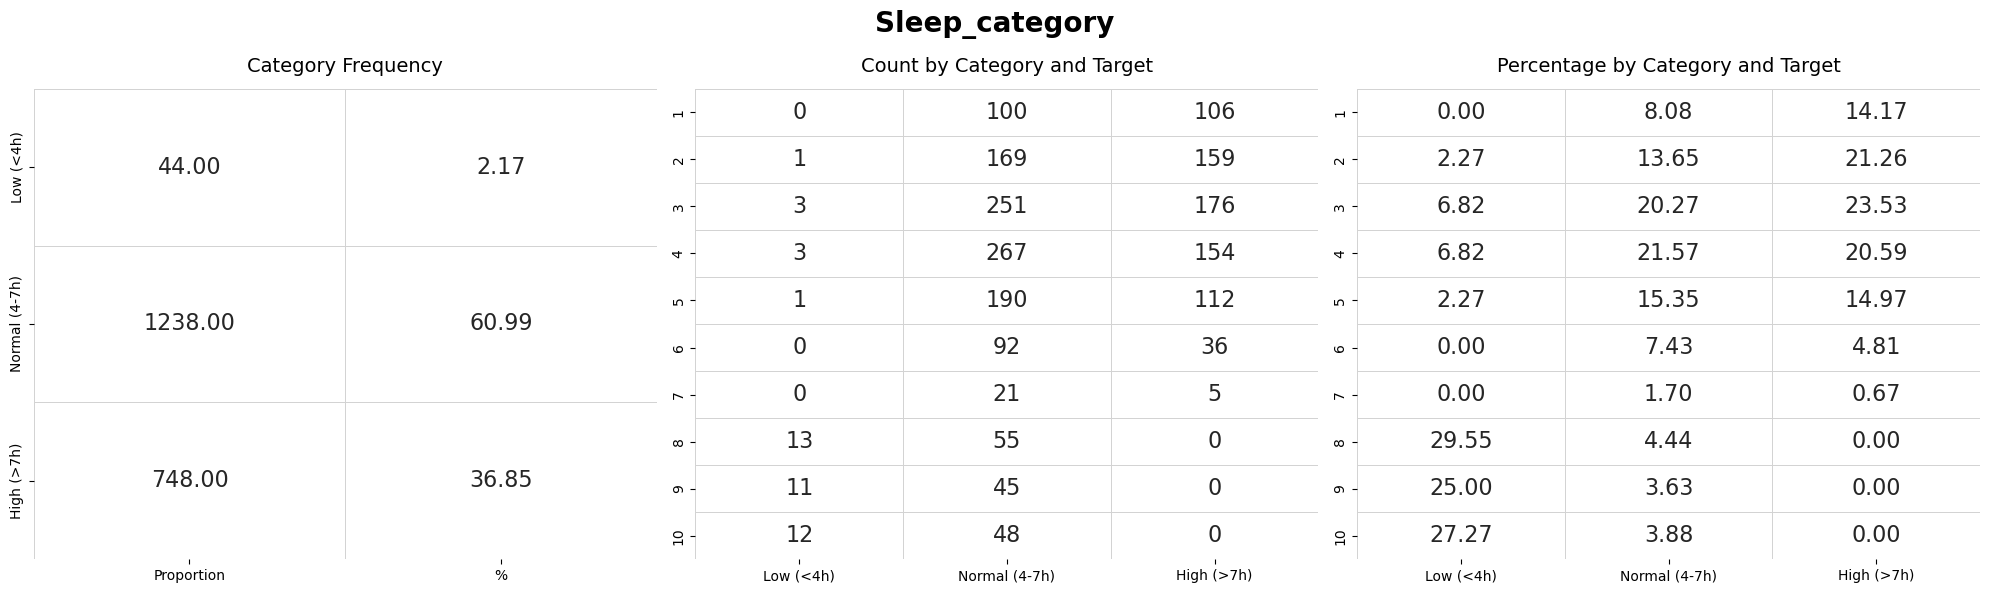

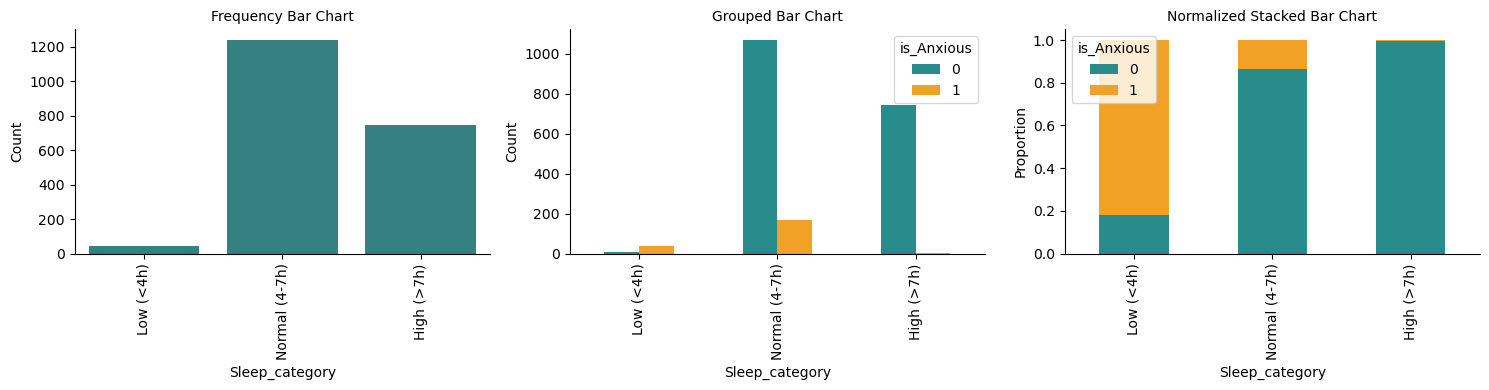

In [459]:
categorical_vs_target(df_copy, 'Sleep_category', target)

In [460]:
compare_categorical_with_binary(df_copy, 'Sleep_category', target, alpha=0.05)


Sleep_category
[Global Test] p-value = 0.0000
H0 rejected at 5% significance level.
Significant pairwise differences (p < α):
No pairwise differences found.


In [461]:
chi2_stat, p_value,dof, expected = stats.chi2_contingency(contingency_table(df_copy, 'Sleep_category', target))

print(f"chi_square = {chi2_stat:.4f}")
print(f"p_value = {p_value:.4f}")

if p_value < 0.05:
    print(f"Sleep_category  has significant association with being anxious.\n")
else:
    print(f"Sleep_category  has no significant association with being anxious.\n")

chi_square = 3195.9207
p_value = 0.0000
Sleep_category  has significant association with being anxious.



In [462]:
contingency_table(df_copy, 'Anxiety_category', target)

(Anxiety Level (1-10)   1    2    3    4    5    6   7   8   9   10
 Anxiety_category                                                  
 Low                   206  329  430    0    0    0   0   0   0   0
 Medium                  0    0    0  424    0    0   0   0   0   0
 High                    0    0    0    0  303  128  26  68  56  60,
 Anxiety Level (1-10)     1      2      3      4      5      6     7      8   \
 Anxiety_category                                                              
 Low                   21.35  34.09  44.56    0.0   0.00   0.00  0.00   0.00   
 Medium                 0.00   0.00   0.00  100.0   0.00   0.00  0.00   0.00   
 High                   0.00   0.00   0.00    0.0  47.27  19.97  4.06  10.61   
 
 Anxiety Level (1-10)    9     10  
 Anxiety_category                  
 Low                   0.00  0.00  
 Medium                0.00  0.00  
 High                  8.74  9.36  )

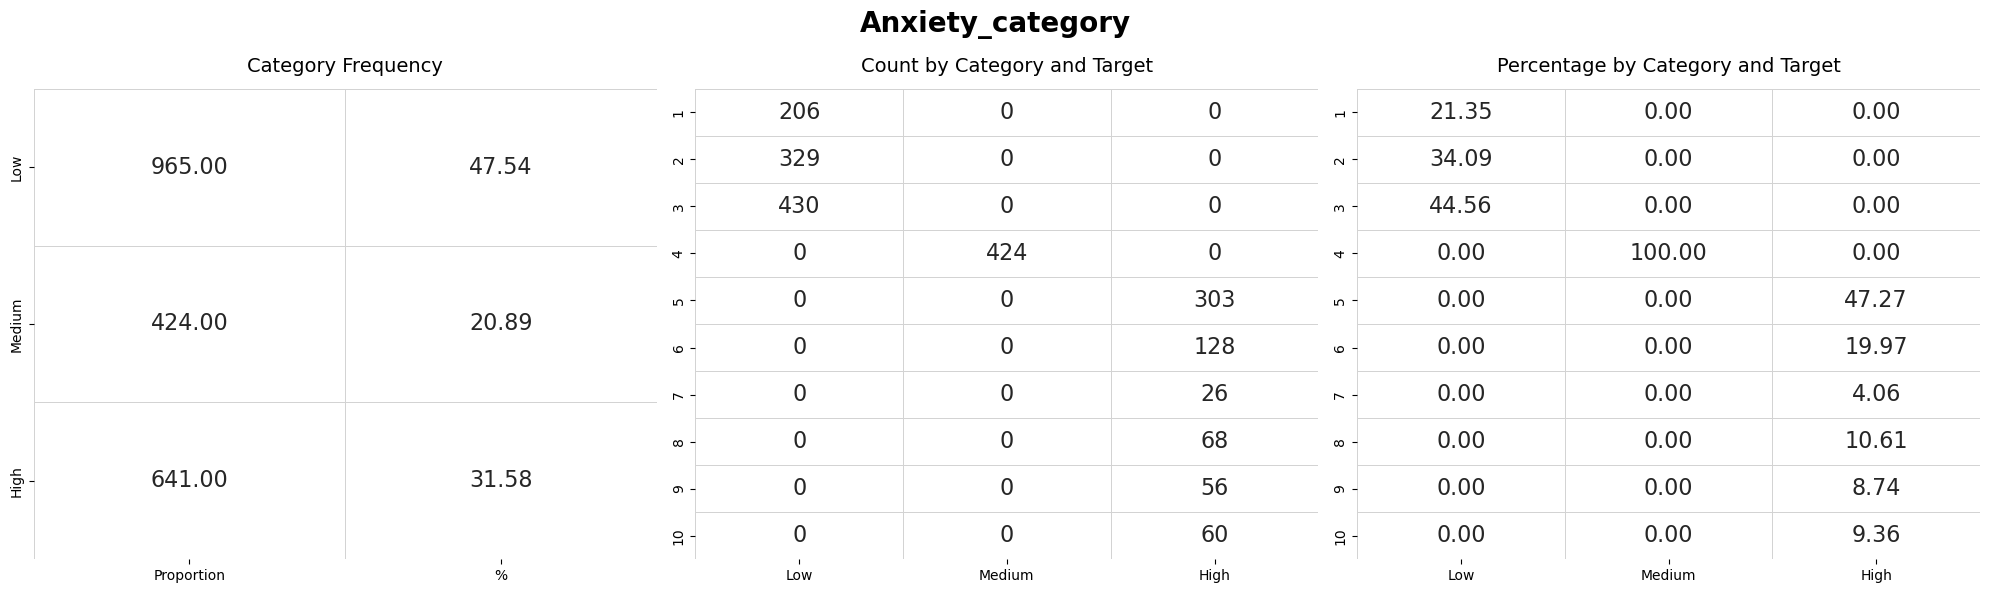

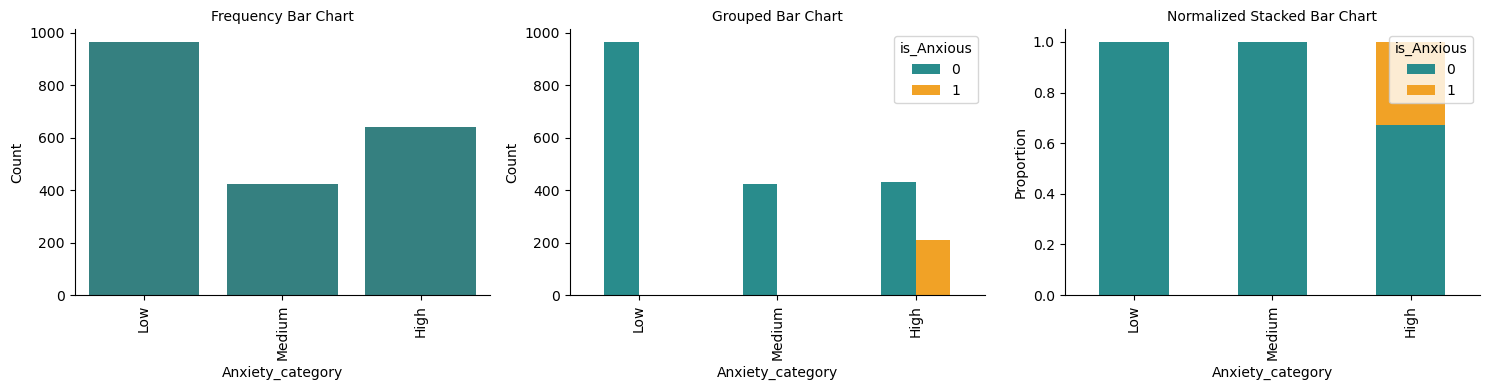

In [463]:
categorical_vs_target(df_copy, 'Anxiety_category', target)

In [464]:
compare_categorical_with_binary(df_copy, 'Anxiety_category', target, alpha=0.05)


Anxiety_category
[Global Test] p-value = 0.0000
H0 rejected at 5% significance level.
Significant pairwise differences (p < α):
No pairwise differences found.


In [465]:
chi2_stat, p_value,dof, expected = stats.chi2_contingency(contingency_table(df_copy, 'Anxiety_category', target))

print(f"chi_square = {chi2_stat:.4f}")
print(f"p_value = {p_value:.4f}")

if p_value < 0.05:
    print(f"Anxiety_category  has significant association with being anxious.\n")
else:
    print(f"Anxiety_category  has no significant association with being anxious.\n")

chi_square = 4766.1122
p_value = 0.0000
Anxiety_category  has significant association with being anxious.



In [466]:
# سه متغیره

In [467]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
df = df_copy
avali = input("نام ستون اول را وارد کنید: ")
dovomi = input("نام ستون دوم را وارد کنید: ")
if avali not in df.columns or dovomi not in df.columns:
    print("نام ستون وارد شده اشتباه است")
else:
    result = pd.pivot_table(df,values="Anxiety Level (1-10)",index=avali,columns=dovomi,aggfunc="mean")
    print(" ")
    print("***میانگین اضطراب اجتماعی بر اساس دو متغیر انتخابی***")
    print(result)
    print(" ")
    print("********************بار پلات وارد میشود********************")
    result.plot(kind="bar")
    plt.title("Mean Social Anxiety by Selected Variables")
    plt.ylabel("Anxiety Level")
    plt.xlabel(avali)
    plt.tight_layout()
    plt.show()
    print("********************باکس پلات وارد میشود********************")
    df.boxplot(
    column="Anxiety Level (1-10)",
    by=[avali, dovomi],
    rot=45)
    plt.title("Distribution of Social Anxiety")
    plt.suptitle("")
    plt.show()

print("رگرسیون هم میخوای؟")
print("Please write 1(Yes) or 0(No)")
choice = input()
if choice == "0":
    print("تا درودی دیگر بدرود")
else:
    a = avali
    b = dovomi
    df[a] = df[a].replace({"Yes": 1, "No": 0})
    df[b] = df[b].replace({"Yes": 1, "No": 0})
    X = df[[a, b]]
    y = df["Anxiety Level (1-10)"]
    if X[a].dtype == "object" or X[b].dtype == "object":
        print("باید ستونها عددی باشن!")
    else:
        X = sm.add_constant(X) 
        model = sm.OLS(y, X).fit()
        print(model.summary())

ModuleNotFoundError: No module named 'statsmodels'